# Center patch

## Libraries and function

In [ ]:
import pickle
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
import seaborn as sns
from astropy.time import Time

from qubic.lib.Qsamplings import gal2equ

import snr_analysis_functions as sf
import visibility_functions as vf

In [ ]:
# See snr_analysis_functions.py
# See visibility_functions.py

def load_maps(file, plot=False):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    coverage = data["coverage"]
    seenpix = data["seenpix"]

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    if plot==True:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        hp.mollview(coverage, title='Coverage', cmap='Spectral_r', fig=fig.number, sub=(1, 2, 1))
        plt.subplot(1, 2, 1).axis('off')

        axes[1].plot(data["convergence"])
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Convergence")
        axes[1].set_title("PCG Convergence")
        axes[1].set_yscale("log")
        axes[1].set_ylim(1e-8, 1e0)
        axes[1].grid()

        plt.subplots_adjust(wspace=0.4)
        plt.show()

        STOKES = ["I", "Q", "U"]

        istk = 0
        n = 2
        reso = 15

        k = 0

        plt.figure(figsize=(20, 10))
        for inu in range(Nrec):
            hp.gnomview((maps_input[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                                cmap="jet",
                                # min = - n * sigma_input[inu],
                                # max = n * sigma_input[inu],
                                sub=(Nrec, 3, k + 1))
            
            hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                                cmap="jet",
                                # min = - n * sigma_rec[inu],
                                # max = n * sigma_rec[inu],
                                sub=(Nrec, 3, k + 2))
            
            hp.gnomview(maps_res[inu, :, istk], rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                                cmap="jet",
                                # min = - n * sigma_res[inu],
                                # max = n * sigma_res[inu],
                                sub=(Nrec, 3, k + 3))
            k += 3

    del data

    return maps_input[:,:,0], maps_rec[:,:,0], maps_res[:,:,0], center, seenpix, coverage


def maps_stacking(datafiles):
    nfiles = len(datafiles)

    # Carico il primo file per ottenere shape e metadati
    with open(datafiles[0], "rb") as f:
        data = pickle.load(f)
    nus = data["nus"]
    Nrec = nus.shape[0] - 7
    center = data["center"]

    # Preallocazione
    maps_input_arr = np.empty((nfiles, *data["maps_in_convolved"][:, :, 0].shape), dtype=np.float32)
    maps_input_nobeam_arr = np.empty((nfiles, *data["maps_in"][:, :, 0].shape), dtype=np.float32)
    maps_rec_arr   = np.empty((nfiles, *data["maps"][:Nrec, :, 0].shape), dtype=np.float32)
    coverage_arr   = np.empty((nfiles, *data["coverage"].shape), dtype=np.float32)
    seenpix_arr   = np.empty((nfiles, *data["seenpix"].shape), dtype=bool)

    # Inserisco il primo file
    maps_input_arr[0] = data["maps_in_convolved"][:, :, 0]
    maps_input_nobeam_arr[0] = data["maps_in"][:, :, 0]
    maps_rec_arr[0]   = data["maps"][:Nrec, :, 0]
    coverage_arr[0]   = data["coverage"]
    seenpix_arr[0]    = data["seenpix"]

    # Leggo il resto dei file
    for i, fname in enumerate(datafiles[1:], start=1):
        with open(fname, "rb") as f:
            data = pickle.load(f)
        maps_input_arr[i] = data["maps_in_convolved"][:, :, 0]
        maps_input_nobeam_arr[i] = data["maps_in"][:, :, 0]
        maps_rec_arr[i]   = data["maps"][:Nrec, :, 0]
        coverage_arr[i]   = data["coverage"]
        seenpix_arr[i]    = data["seenpix"]

    # Calcolo medie cumulative
    maps_input_cum = np.cumsum(maps_input_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_input_nobeam_cum = np.cumsum(maps_input_nobeam_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_rec_cum   = np.cumsum(maps_rec_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_res_cum   = maps_input_cum - maps_rec_cum

    # Coverage cumulativa e maschera
    coverage_cum = np.cumsum(coverage_arr, axis=0)
    seenpix_cum = coverage_cum / np.max(coverage_cum, axis=1)[:, None] > 0.1

    del data

    return {
        "maps_in": maps_input_arr,
        "maps_in_nobeam": maps_input_nobeam_arr,
        "maps_rec": maps_rec_arr,
        "maps_res": maps_input_arr - maps_rec_arr,
        "maps_in_cum": maps_input_cum,
        "maps_in_nobeam_cum": maps_input_nobeam_cum,
        "maps_cum": maps_rec_cum,
        "maps_res_cum": maps_res_cum,
        "nus": nus,
        "coverage": coverage_arr,
        "coverage_cum": coverage_cum,
        "center": center,
        "seenpix": seenpix_arr,
        "seenpix_cum": seenpix_cum,
    }


def load_tods(datafiles):
    nfiles = len(datafiles)
    tods = []

    for i in range(nfiles):
        with open(datafiles[i], "rb") as f:
            data = pickle.load(f)
        idx = int(np.sum(data['coverage'])/248)
        tods.append(data['tod'][0:idx])
    
        del data

    return tods


def noise_estimation(maps_input, maps_res, coverage, seenpix):
    noises = []

    # Method 1: noise as residual weighted std
    weighted_mean = np.average(maps_res[seenpix], weights=coverage[seenpix])
    weighted_std = np.sqrt( np.sum(coverage[seenpix] * (maps_res[seenpix] - weighted_mean)**2) / np.sum(coverage[seenpix]) )
    print('Residual weighted std', weighted_std)
    noises.append(weighted_std)

    snr = maps_input/weighted_std
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Weighted std",
                        cmap="jet",
                        min = 0,
    )


    # Method 2: noise estimation from a hit-count–normalized residual map
    normalized_residuals = maps_res[seenpix] * np.sqrt(coverage[seenpix])
    sigma0 = np.std(normalized_residuals)
    sigma = np.zeros_like(coverage)
    sigma[seenpix] = sigma0 / np.sqrt(coverage[seenpix])
    noises.append(sigma)

    snr = maps_input / sigma 
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit count normalized std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 3: noise estimation from hit-binned residual map
    nbins = 20
    hits = coverage[seenpix]
    noise = maps_res[seenpix]
    edges = np.quantile(hits, np.linspace(0, 1, nbins + 1))    # bin edges

    hits_centers = []
    sigma_bins = []

    for i in range(nbins):
        sel = (hits >= edges[i]) & (hits < edges[i+1])
        if np.sum(sel) < 50:
            continue
        hits_centers.append(np.mean(hits[sel]))
        sigma_bins.append(np.sqrt(np.mean(noise[sel]**2)))

    hits_centers = np.array(hits_centers)
    sigma_bins = np.array(sigma_bins)

    bin_idx = np.digitize(coverage[seenpix], edges) - 1  # returns 0..nbins-1
    bin_idx[bin_idx == nbins] = nbins-1     # last bin includes pixel on border
    sigma = np.zeros_like(coverage)       
    sigma[seenpix] = sigma_bins[bin_idx]
    noises.append(sigma)

    snr = maps_input / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit binned std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 4: noise as local std
    radius_deg = 1
    radius_rad = np.radians(radius_deg)

    sigma = np.zeros_like(maps_res)

    for ipix in range(len(maps_res)):
        # finds all the pixel within radius_rad from pixel ipix 
        neighbors = hp.query_disc(128, hp.pix2vec(128, ipix), radius_rad)
        
        # local std
        sigma[ipix] = np.sqrt(np.mean(maps_res[neighbors]**2))
    noises.append(sigma)

    snr = maps_input / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Local std",
                        cmap="jet",
                        min = 0,
    )

    return noises


def daily_observing_time(time_s, date_obs, max_gap_s=10.0):
    """
    Compute total observing time per day from a stream of pointing timestamps.

    Parameters
    ----------
    time_s : array-like of float
        Pointing times in seconds relative to `date_obs`.
    date_obs : astropy.time.Time
        Reference absolute time corresponding to zero in `time_s`.
    max_gap_s : float, optional
        Maximum allowed gap (in seconds) between two consecutive pointings to
        treat them as continuous observing. Larger gaps are treated as non-observing
        periods and are excluded. Default is 10.0.

    Returns
    -------
    days : astropy.time.Time
        One timestamp per observed day, at 00:00:00 of that day.
    sec_day : numpy.ndarray
        Total observing time per day in seconds 
    """
    u = date_obs.unix + time_s

    # Keep only consecutive intervals that represent continuous observing
    dt = np.diff(u)
    valid = (dt > 0.0) & (dt <= float(max_gap_s))
    if not np.any(valid):
        return Time([], format="unix", scale=t.scale), np.array([], dtype=float)

    # Start/end times of valid intervals
    starts = u[:-1][valid]
    ends = u[1:][valid]

    # Day index for each interval start/end.
    d0 = (starts // 86400.0).astype(np.int64)
    d1 = (ends // 86400.0).astype(np.int64)

    dmin = d0.min()
    dmax = d1.max()
    nday = int(dmax - dmin + 1)

    sec_day = np.zeros(nday, dtype=float)

    # Intervals fully inside one day: add full duration to that day.
    same = (d0 == d1)
    if np.any(same):
        idx = d0[same] - dmin
        sec_day += np.bincount(idx, weights=ends[same] - starts[same], minlength=nday)

    # Intervals crossing midnight: split contribution across two days.
    cross = ~same 
    if np.any(cross):
        midnight = (d0[cross] + 1) * 86400.0
        sec_day += np.bincount(d0[cross] - dmin, weights=midnight - starts[cross], minlength=nday)
        sec_day += np.bincount(d1[cross] - dmin, weights=ends[cross] - midnight, minlength=nday)

    # Keep only days with non-zero observing time.
    keep = sec_day > 0.0
    day_idx = np.arange(dmin, dmax+1, dtype=np.int64)[keep]
    days = Time(day_idx * 86400.0, format='unix', scale=date_obs.scale)
    days.format = 'iso'

    return days, sec_day[keep]


def snr_from_coverage_bins(maps_input, maps_res, coverage, seenpix, center=[0, 0], nbins=20, plot=False, verbose=False):
    """
    Estimate binned noise (sigma) and SNR based on coverage quantiles.

    Inputs:
        maps_input : 1D array
            Input map 
        maps_res : 1D array
            Residual map
        coverage : 1D array
            Coverage map used to bin pixels.
        seenpix : 1D bool array or index array
            Mask of observed pixels.
        center : list
            Center used only for plotting.
        nbins : int
            Number of coverage bins (quantiles).
        plot : bool
            If True, plot the SNR map.

    Outputs:
        snr : 1D array
            Signal-to-noise map (maps_input / sigma).
        sigma : 1D array
            Binned RMS noise per pixel (constant within each coverage bin).
        corr_cov_sigma : float
            Correlation between coverage and sigma over seen pixels.
        corr_inv_sqrt_cov_sigma : float
            Correlation between 1/sqrt(coverage) and sigma over seen pixels.
    """

    hits = coverage[seenpix]
    noise = maps_res[seenpix]
    edges = np.quantile(hits, np.linspace(0, 1, nbins + 1))  # bin edges

    hits_centers = []
    sigma_bins = np.full(nbins, np.nan, dtype=float)

    for i in range(nbins):
        sel = (hits >= edges[i]) & (hits < edges[i + 1])
        if np.sum(sel) < 50:
            continue
        hits_centers.append(np.mean(hits[sel]))
        sigma_bins[i] = np.sqrt(np.mean(noise[sel]**2))

    hits_centers = np.array(hits_centers)

    bin_idx = np.digitize(coverage[seenpix], edges) - 1  # 0..nbins-1
    bin_idx[bin_idx == nbins] = nbins - 1  # include right edge

    sigma = np.full_like(coverage, np.nan, dtype=float)
    sigma[seenpix] = sigma_bins[bin_idx]

    snr = maps_input / sigma

    corr_cov_sigma = 0
    corr_inv_sqrt_cov_sigma = 0
    if verbose:

        # Correlations over seen pixels (exclude NaNs)
        if np.any(~np.isfinite(sigma[seenpix])):
            raise ValueError("The noise is NaN for some pixel.")

        corr_cov_sigma = np.corrcoef(coverage[seenpix], sigma[seenpix])[0, 1]
        corr_inv_sqrt_cov_sigma = np.corrcoef(1 / np.sqrt(coverage[seenpix]), sigma[seenpix])[0, 1]

        print("Correlation between coverage and binned noise:", corr_cov_sigma)
        print("Correlation between 1/sqrt(coverage) and binned noise:", corr_inv_sqrt_cov_sigma)

    if plot:
        snr[~seenpix] = hp.UNSEEN
        hp.gnomview(snr, rot=center,
                    reso=15, notext=True, title="SNR",
                    cmap="jet", min=0)

    return snr, sigma, corr_cov_sigma, corr_inv_sqrt_cov_sigma


def snr_from_local_std(maps_input, maps_res, coverage, seenpix, center=[0, 0], radius_deg=1.0, plot=False, verbose=False):
    """
    Estimate local noise (sigma) and SNR. The nosie is computed within a disk of radius
    `radius_deg` (in degrees) centered on each pixel.

    Inputs:
        maps_input : 1D array
            Input map 
        maps_res : 1D array
            Residual map
        coverage : 1D array
            Coverage map used to bin pixels.
        seenpix : 1D bool array or index array
            Mask of observed pixels.
        center : list
            Center used only for plotting.
        radius_deg : float
            Radius (in degrees) of the circular neighborhood.
        plot : bool
            If True, plot the SNR map.

    Outputs:
        snr : 1D array
            Signal-to-noise map (maps_input / sigma).
        sigma : 1D array
            Binned RMS noise per pixel (constant within each coverage bin).
        corr_cov_sigma : float
            Correlation between coverage and sigma over seen pixels.
        corr_inv_sqrt_cov_sigma : float
            Correlation between 1/sqrt(coverage) and sigma over seen pixels.
    """
    radius_rad = np.radians(radius_deg)

    sigma = np.full_like(maps_res, np.nan, dtype=float)

    for ipix in range(len(maps_res)):
        # Find all pixels within radius_rad from ipix
        neighbors = hp.query_disc(128, hp.pix2vec(128, ipix), radius_rad)

        # Keep only observed pixels
        neighbors = neighbors[seenpix[neighbors]]
        if neighbors.size == 0:
            continue

        # Local RMS of residuals
        sigma[ipix] = np.sqrt(np.mean(maps_res[neighbors]**2))

    snr = maps_input / sigma
  

    # Correlations over seen pixels (exclude NaNs)
    if np.any(~np.isfinite(sigma[seenpix])):
        raise ValueError("The noise is NaN for some pixel.")

    corr_cov_sigma = np.corrcoef(coverage[seenpix], sigma[seenpix])[0, 1]
    corr_inv_sqrt_cov_sigma = np.corrcoef(1 / np.sqrt(coverage[seenpix]), sigma[seenpix])[0, 1]

    if verbose:
        print("Correlation between coverage and binned noise:", corr_cov_sigma)
        print("Correlation between 1/sqrt(coverage) and binned noise:", corr_inv_sqrt_cov_sigma)

    if plot:
        snr[~seenpix] = hp.UNSEEN
        hp.gnomview(snr, rot=center,
                    reso=15, notext=True, title="SNR",
                    cmap="jet", min=0)

    return snr, sigma, corr_cov_sigma, corr_inv_sqrt_cov_sigma

## Inspect maps

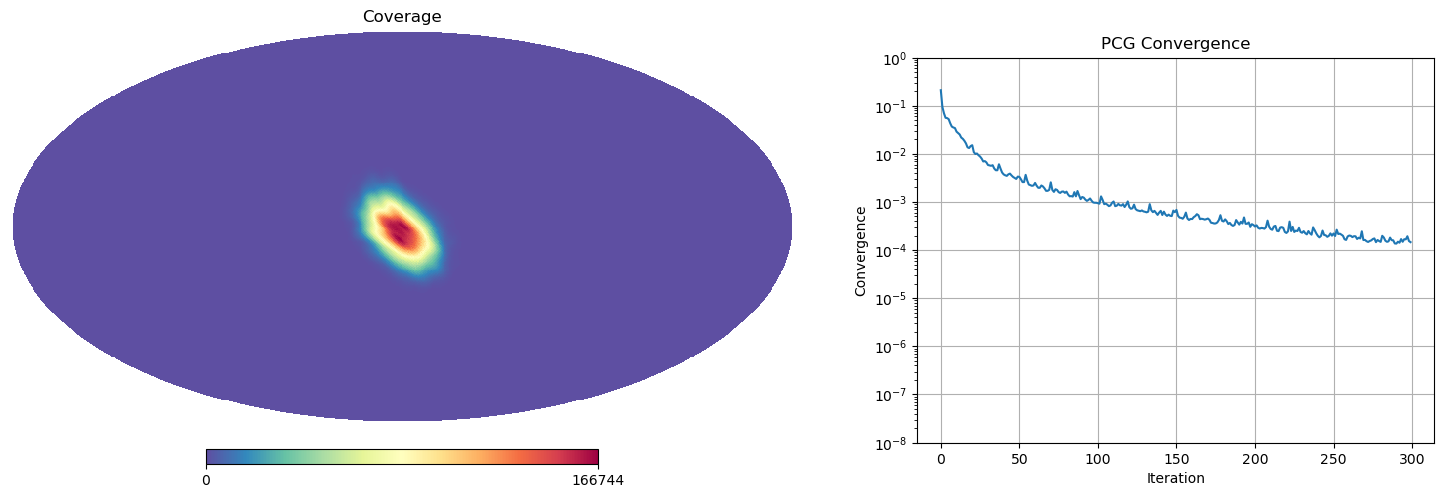

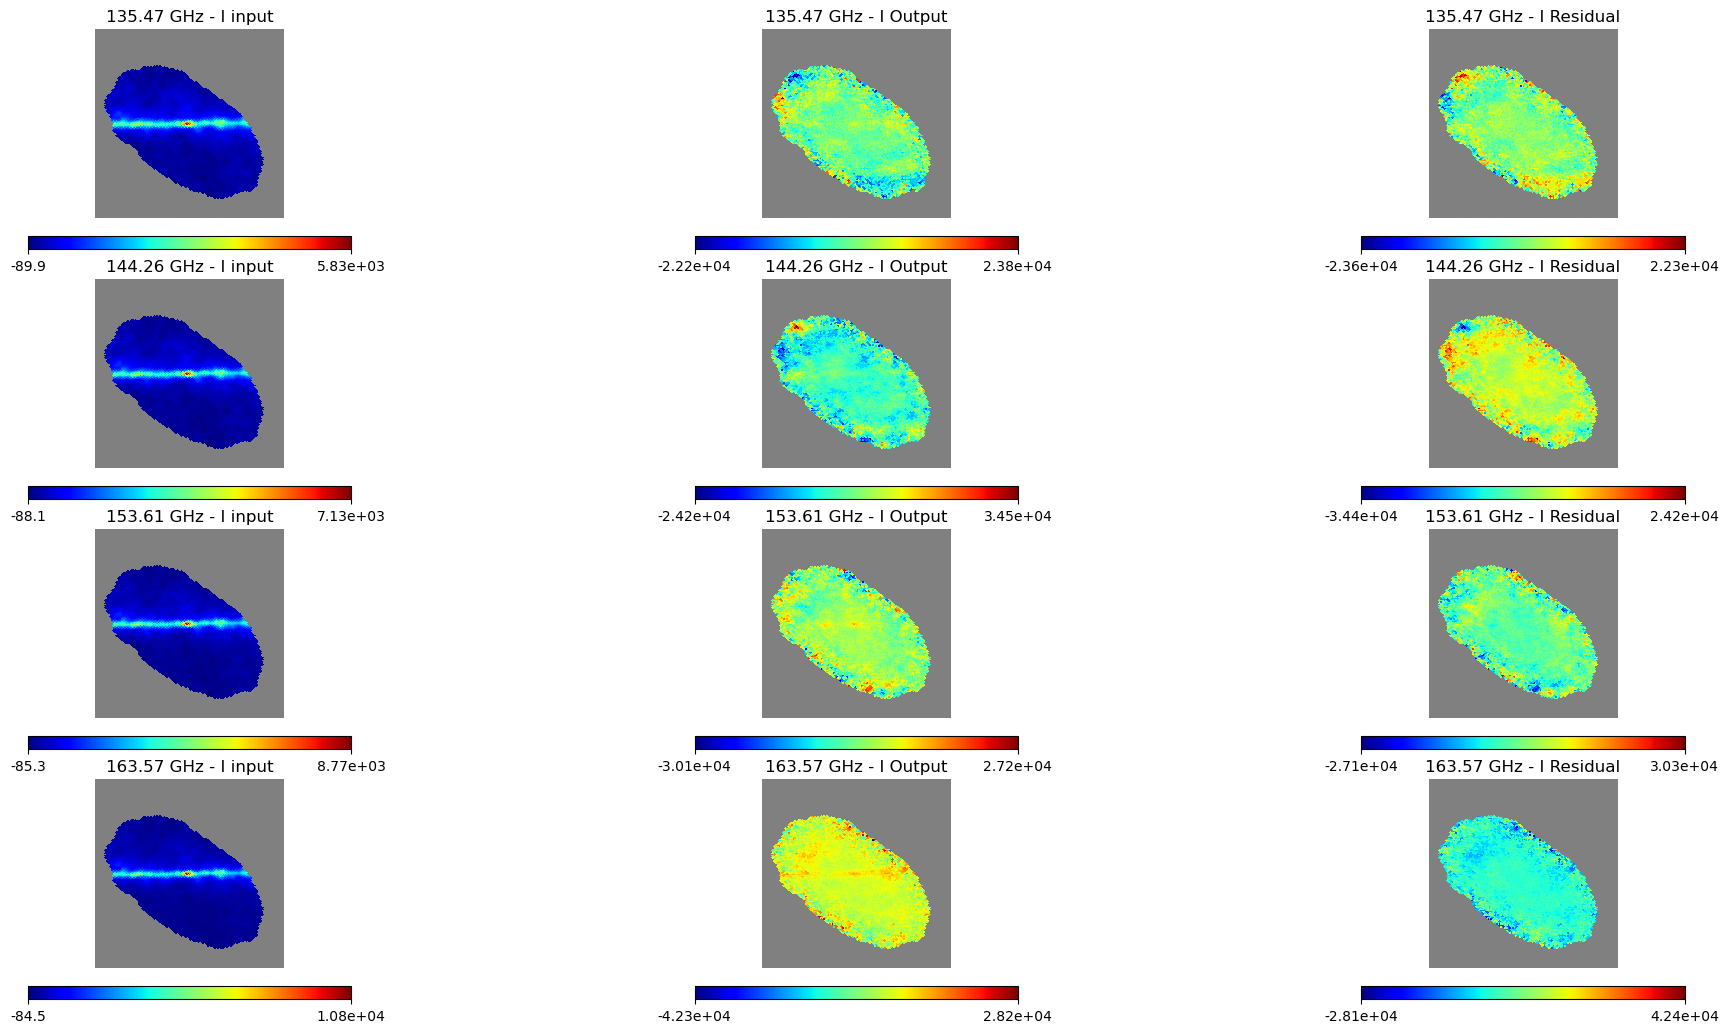

In [6]:
data = load_maps("/media/mattia/Hard Disk/data/center/maps/final/01-02.pkl", plot=True),

## Pointings

In [3]:
# Load pointings file
pointings = []
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_janfeb.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_marapr.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_mayjun.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_julaug.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_sepoct.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/center/pointings/pointings_novdec.pkl", "rb")))

In [4]:
total_hours = 0
for pointing in pointings:
    days, sec_day = daily_observing_time(pointing.time, pointing.date_obs, max_gap_s=10.0)
    hours_day = sec_day / 3600.0
    print('Hours of observing time per day:')
    print(hours_day)
    total_hours += np.sum(hours_day)  
    print('Total observation time:', np.round(np.sum(hours_day), decimals=1), 'hours')
print('Total observation time in one year:', np.round(total_hours, decimals=1), 'hours =', np.round(total_hours/(24*365)*100, decimals=1), '%')

Hours of observing time per day:
[6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525]
Total observation time: 363.0 hours
Hours of observing time per day:
[6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525 6.1525
 6.1525]
Total observation time: 375.3 hours
Hours o

## Scanning strategy with fixed HWP

In [3]:
datafiles=[
    "/media/mattia/Hard Disk/data/center/maps/01-02_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/03-04_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/05-06_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/07-08_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/09-10_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/11-12_planck.pkl",
]

In [5]:
data = maps_stacking(datafiles)

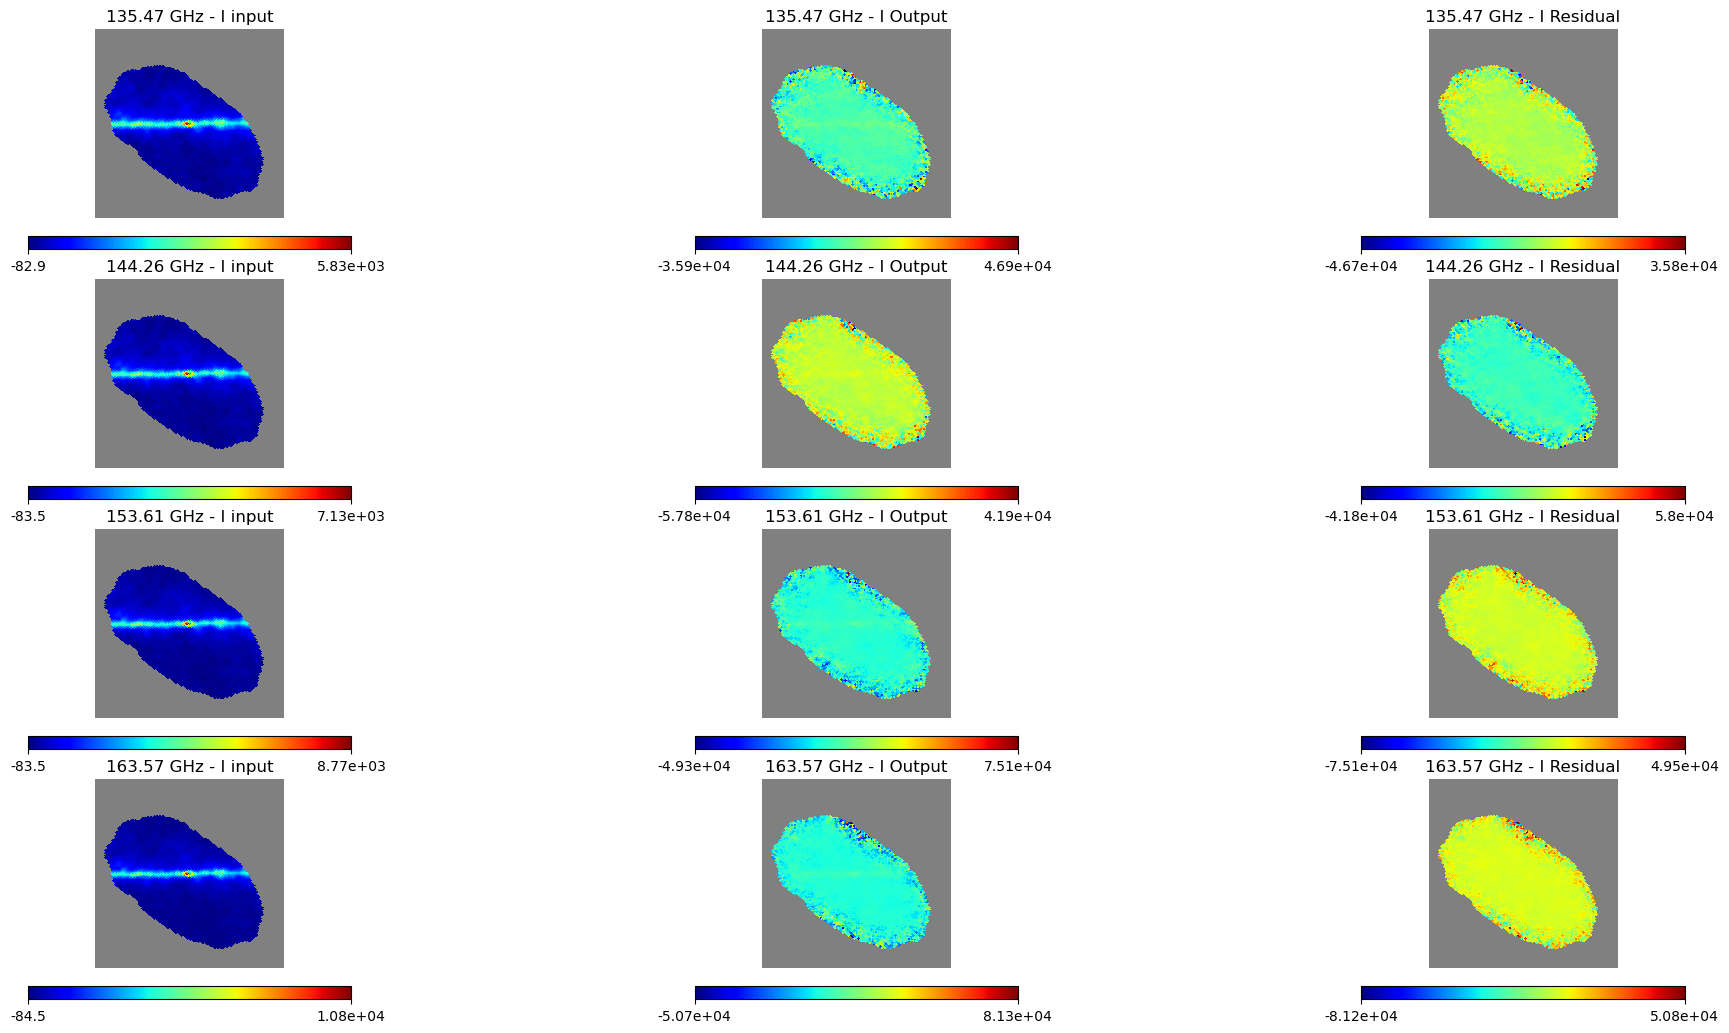

In [6]:
maps_input = data["maps_in"]
maps_rec = data["maps"]
maps_res = data["maps_res"]
seenpix = data["seenpix"]
maps_input[:,~seenpix] = hp.UNSEEN
maps_rec[:,~seenpix] = hp.UNSEEN
maps_res[:,~seenpix] = hp.UNSEEN
nus = data["nus"]
center = data["center"]
coverage = data["coverage"]

k=0 

plt.figure(figsize=(20, 10))
for inu in range(4):
    hp.gnomview((maps_input[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I input",  
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(4, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Output",
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(4, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Residual",
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(4, 3, k + 3))
    k += 3

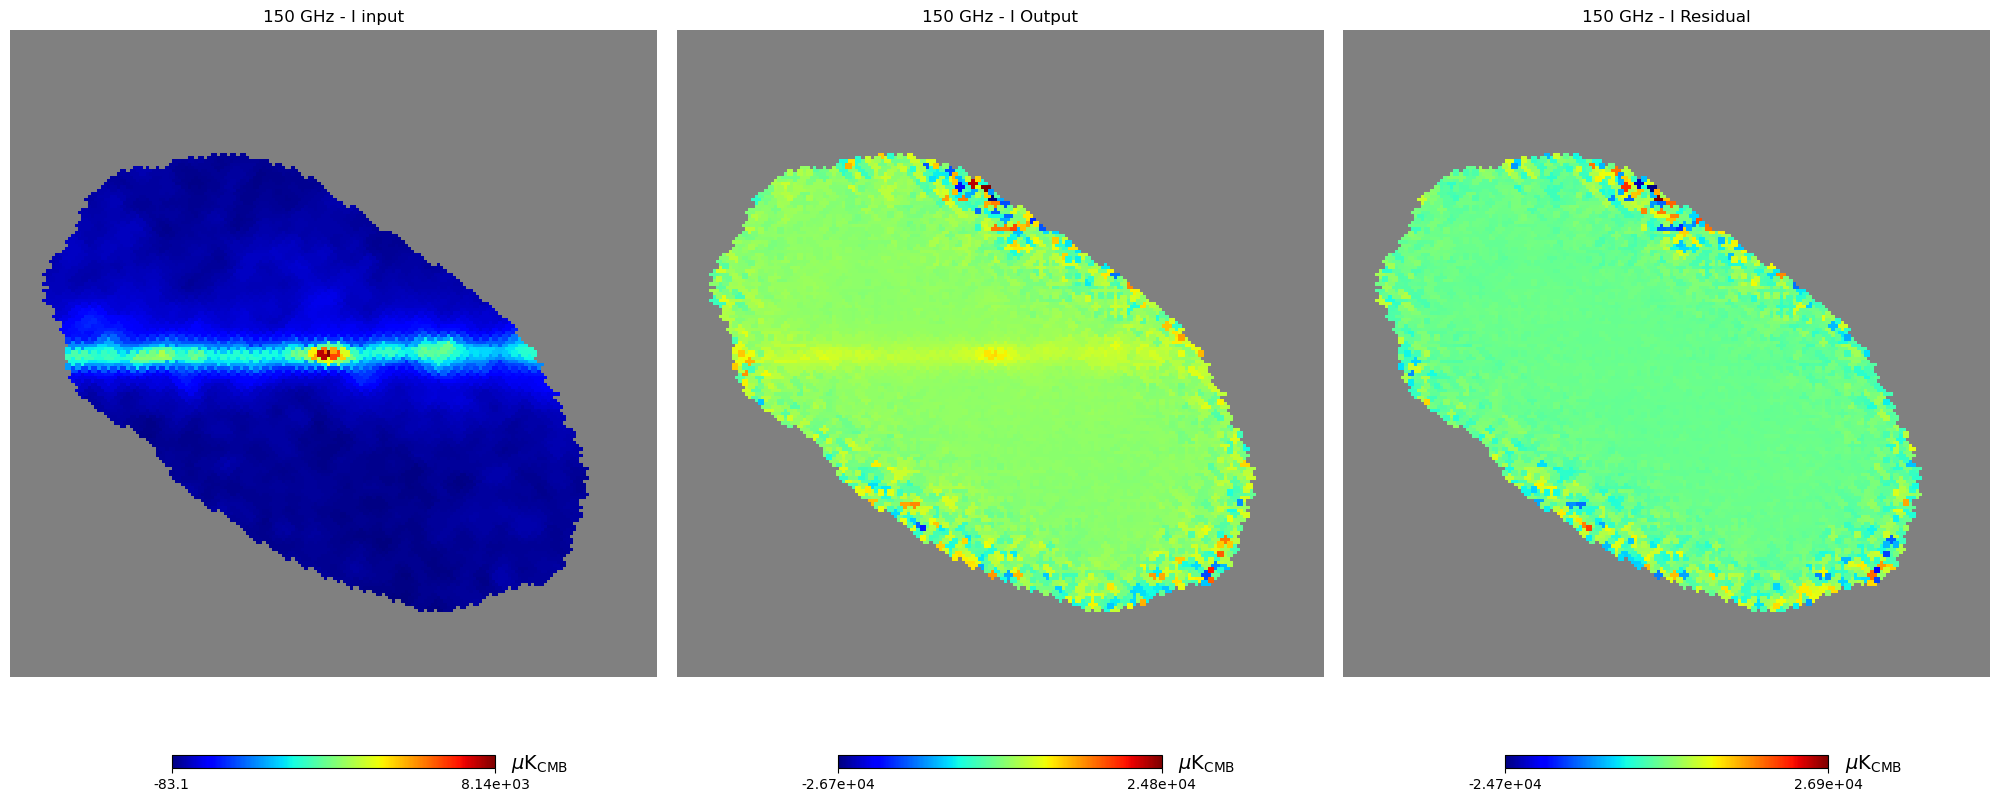

In [7]:
# Mean over reconstructed frequency maps
maps_input_mean = np.mean(maps_input[:,:], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:], axis=0)
maps_res_mean = np.mean(maps_res[:,:], axis=0)


plt.figure(figsize=(20, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,2))

hp.gnomview((maps_res_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,3))
    

In [8]:
brightest_pix_input = np.argmax(maps_input_mean)   # index of the brightest pixel in the input mean map 
brightest_val = maps_rec_mean[brightest_pix_input] # value of the brightest pixel in the output mean map
brightest_val_true = maps_input_mean[brightest_pix_input] # value of the brightest pixel in the input mean map


print('Brightest pixel coverage', coverage[brightest_pix_input])
print('Value of the brightest pixel in the input map', brightest_val_true)
print('Value of the brightest pixel in the output map', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Brightest pixel coverage 1015822.0583079185
Value of the brightest pixel in the input map 8140.484210744878
Value of the brightest pixel in the output map 8328.859622102857
SNR 43.21415492638326


### Noise estimation

Residual weighted std 1537.7057648507064


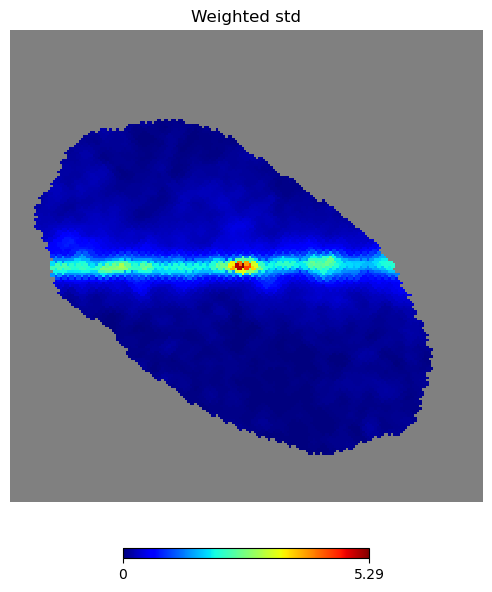

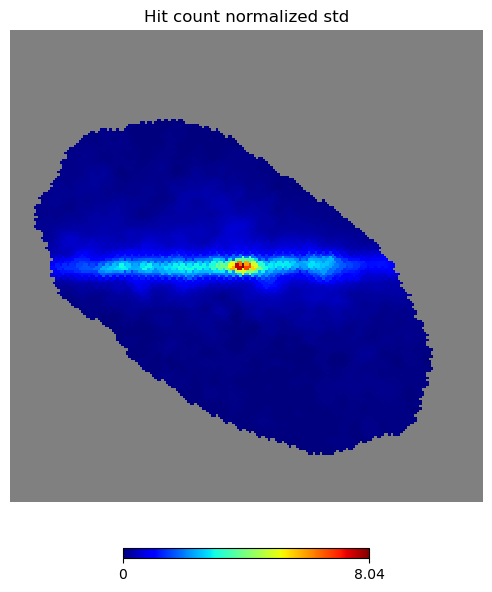

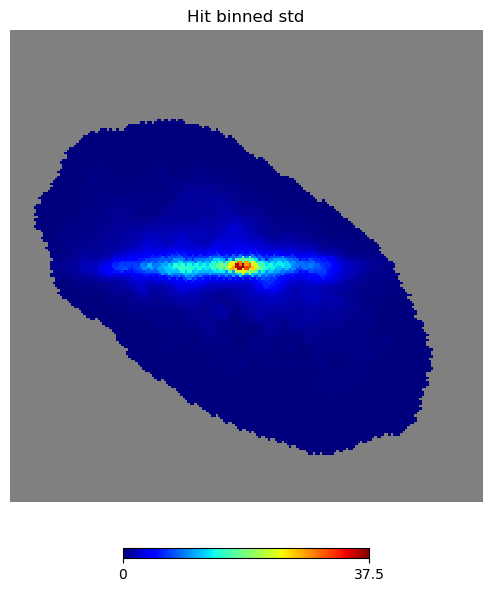

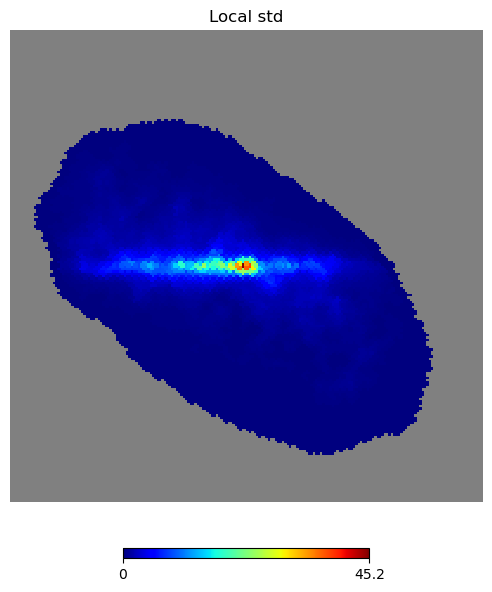

In [10]:
noises = noise_estimation(maps_res_mean, coverage, seenpix)

## Scanning strategy with rotating HWP and same noise seed

In [50]:
datafiles= ["/media/mattia/Hard Disk/data/center/maps/01-02.pkl",
            "/media/mattia/Hard Disk/data/center/maps/03-04_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/05-06_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/07-08_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/09-10_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/11-12_ss_hwp.pkl",
]

In [51]:
data = maps_stacking(datafiles)

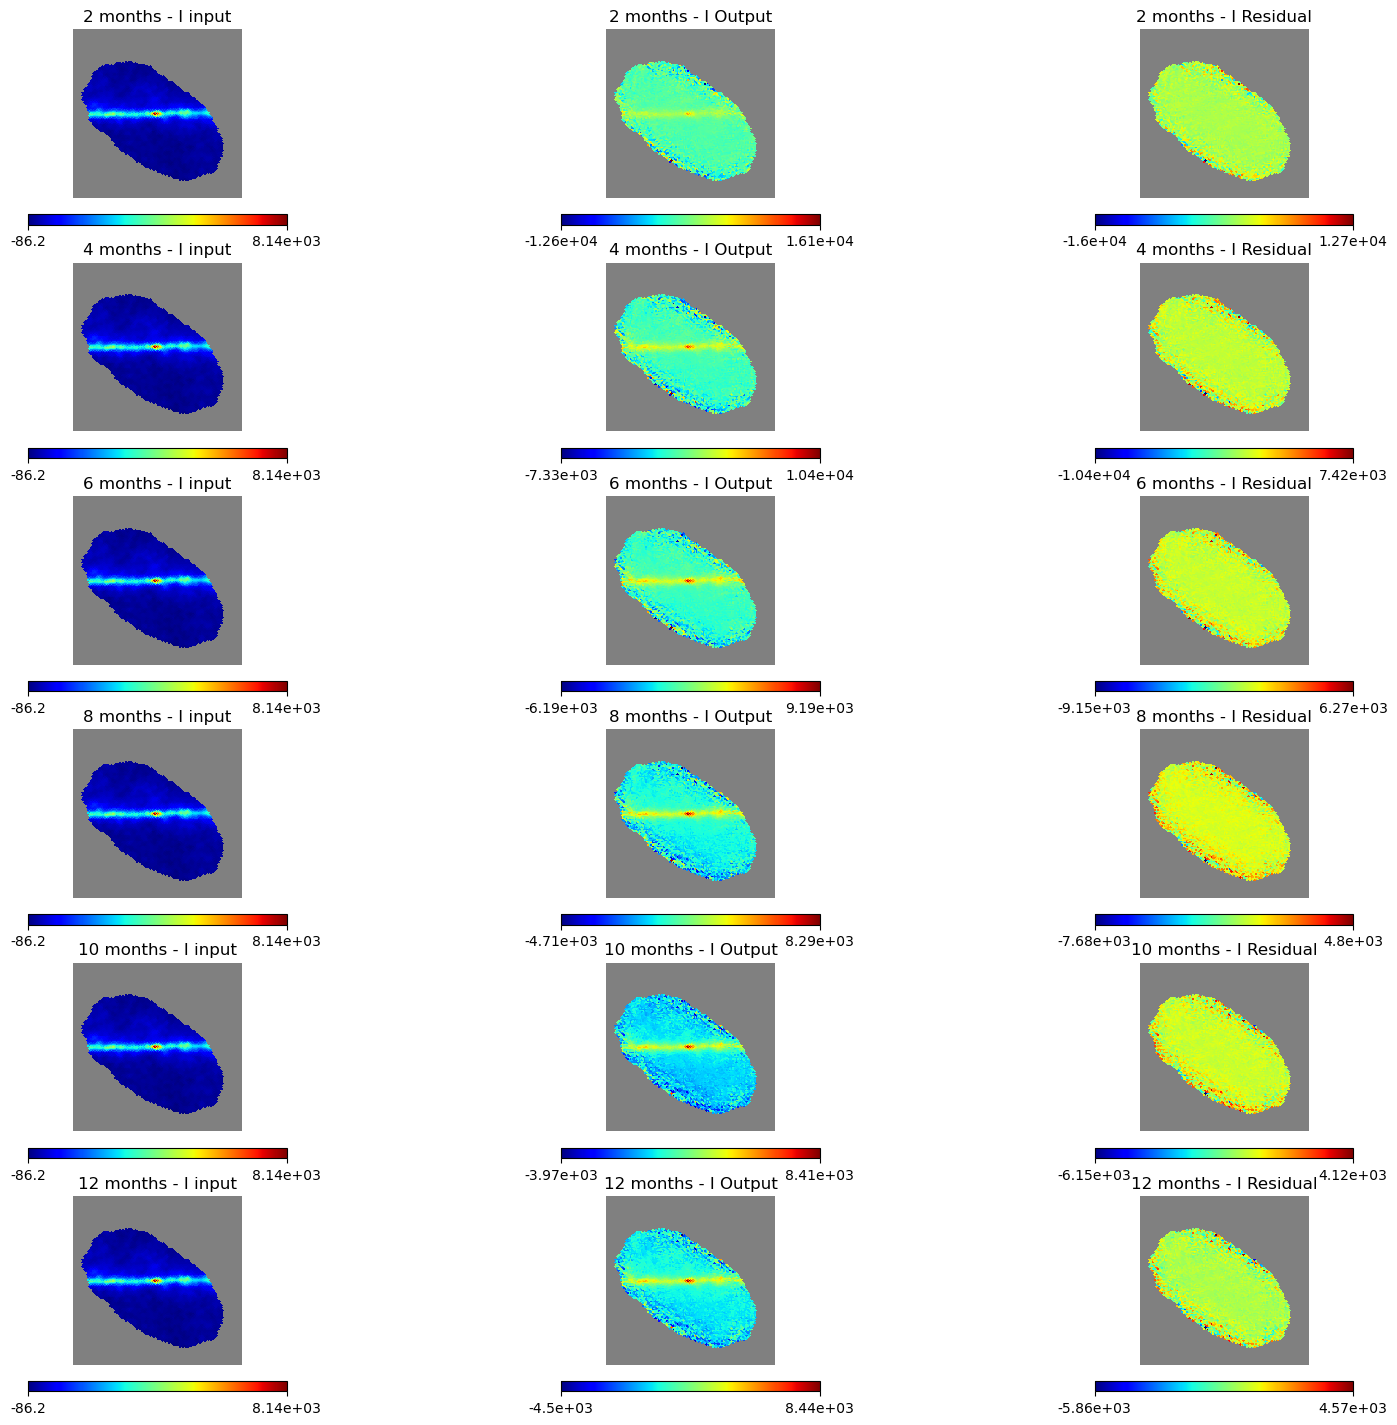

In [60]:
maps_input = np.mean(data["maps_in_cum"], axis=1)
maps_rec = np.mean(data["maps_cum"], axis=1)
maps_res = np.mean(data["maps_res_cum"], axis=1)
seenpix = data["seenpix_cum"]

maps_input = np.where(seenpix, maps_input, hp.UNSEEN)
maps_rec = np.where(seenpix, maps_rec, hp.UNSEEN)
maps_res = np.where(seenpix, maps_res, hp.UNSEEN)

nus = data["nus"]
center = data["center"]
coverage = data["coverage_cum"]

k=0 

plt.figure(figsize=(16, 14))
for i in range(6):
    hp.gnomview((maps_input[i, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I input",  
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(6, 3, k + 1))
    
    hp.gnomview((maps_rec[i, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I Output",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(6, 3, k + 2))
    
    hp.gnomview(maps_res[i, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I Residual",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(6, 3, k + 3))
    k += 3

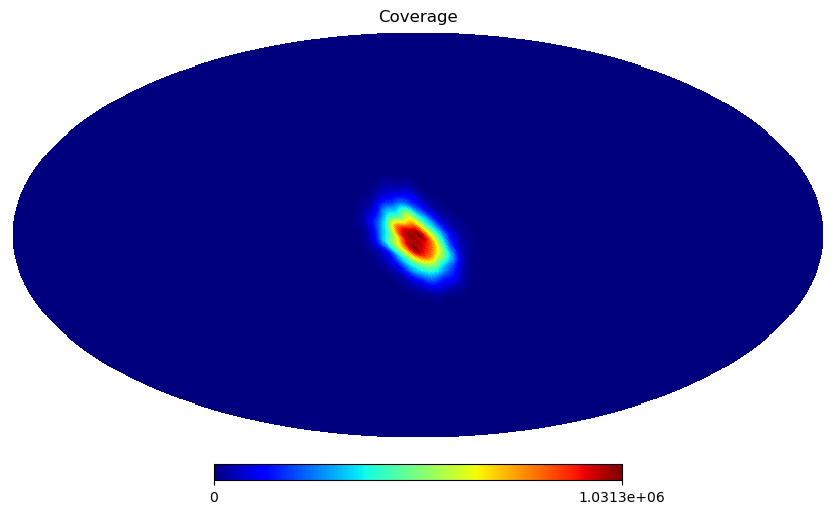

In [61]:
hp.mollview(coverage[-1], title='Coverage', cmap='jet')

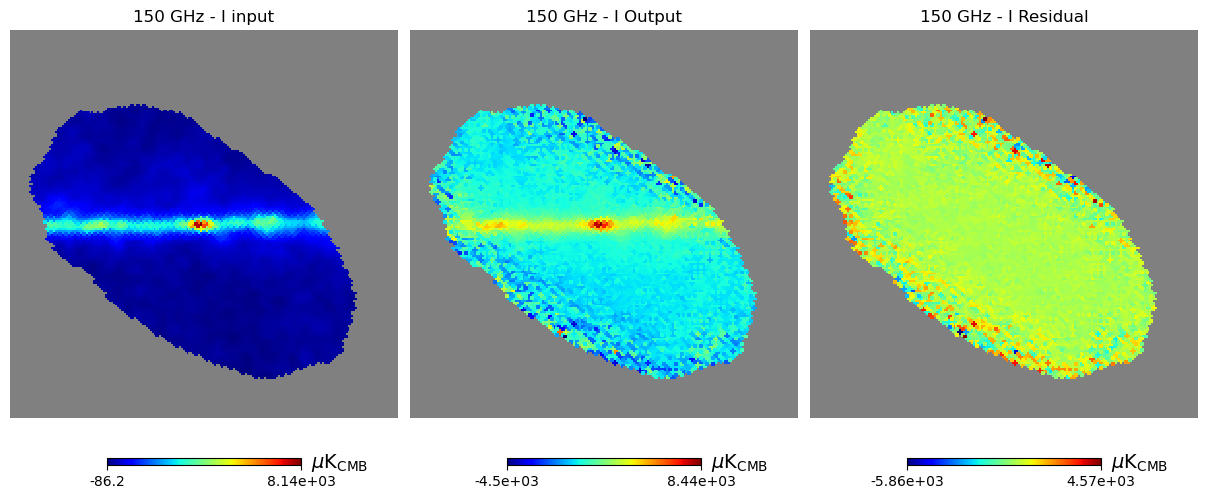

In [62]:
plt.figure(figsize=(12, 5))
hp.gnomview((maps_input[-1]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
    
hp.gnomview((maps_rec[-1]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,2))

hp.gnomview((maps_res[-1]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,3))

In [15]:
brightest_pix_input = np.argmax(maps_input_mean)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean[brightest_pix_input]
brightest_val_true = maps_input_mean[brightest_pix_input]


print('coverage pixel centrale', coverage[brightest_pix_input])
print('Pixel centrale mappa input', brightest_val_true)
print('Pixel centrale mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

NameError: name 'maps_input_mean' is not defined

In [63]:
# Deviazione standard delle mappe dei residui
stds = []
for i in range(6):
    stds.append(np.std(maps_res[i,seenpix[i]]))

np.array(stds)

array([1486.18754509, 1066.93522213,  874.46626428,  741.92141234,
        651.98545021,  697.97381704])

In [64]:
# Confronto con andamento inversamente proporzionale a radice di N
np.std(maps_res[0,seenpix[0]])/np.sqrt(np.arange(1,7))

array([1486.18754509, 1050.89329125,  858.05077922,  743.09377254,
        664.64327563,  606.73352459])

In [65]:
# calcolo manuale della deviazione standard della media delle varie mappe assumendole scorrelate
res = np.mean(data['maps_res'], axis=1)
stds = []
for i in range(6):
    stds.append(np.std(res[i][data['seenpix'][i]]))
np.sqrt(np.cumsum(np.array(stds)**2))/np.arange(1,7)

array([1486.18762207, 1023.87200928,  825.11425781,  705.1461792 ,
        630.97836914,  576.48010254])

L'andamento sembra essere rispettato tranne che per l'ultima mappa

<Axes: title={'center': 'Correlation matrix reconstructed maps'}>

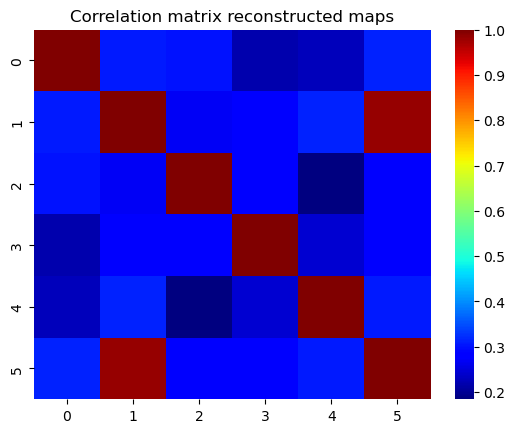

In [99]:
rec = np.mean(data['maps_rec'], axis=1)
idx = np.argmin(np.sum(data['seenpix'], axis=1))
X = np.array([map[data['seenpix'][idx]] for map in rec])

# matrice di correlazione
corr = np.corrcoef(X)
import seaborn as sns
plt.figure()
plt.title('Correlation matrix reconstructed maps')
sns.heatmap(corr, cmap='jet')

In [100]:
print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr!=1]))

Minimum correlation: 0.18395563738975393
Maximum correlation: 0.9999999999999999


<Axes: title={'center': 'Correlation matrix residual maps'}>

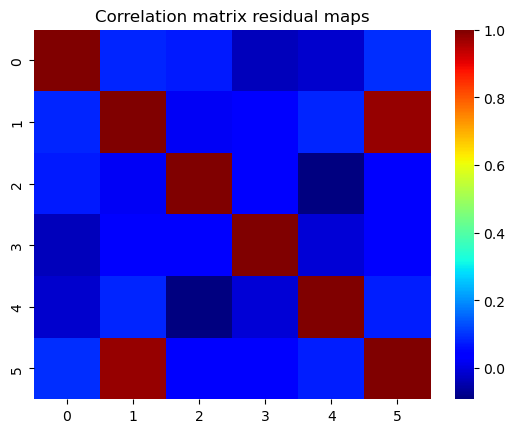

In [101]:
X = np.array([map[data['seenpix'][idx]] for map in res])

# matrice di correlazione
corr = np.corrcoef(X)
plt.figure()
plt.title('Correlation matrix residual maps')
sns.heatmap(corr, cmap='jet')

In [102]:
print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr!=1]))

Minimum correlation: -0.09227091627443276
Maximum correlation: 0.9999999999999999


Si nota infatti una correlazione tra la mappe di marzo-aprile con quella di novembre-dicembre. Di conseguenza quando effettuo la media le mappe non sono tra loro scorrelate e di conseguenza la varianza non scala con l'inverso del numero di mappe mediate

## Scanning strategy with rotating HWP and different noise seed

In [5]:
datafiles= ["/media/mattia/Hard Disk/data/center/maps/01-02.pkl",
            "/media/mattia/Hard Disk/data/center/maps/03-04.pkl",
            "/media/mattia/Hard Disk/data/center/maps/05-06.pkl",
            "/media/mattia/Hard Disk/data/center/maps/07-08.pkl",
            "/media/mattia/Hard Disk/data/center/maps/09-10.pkl",
            "/media/mattia/Hard Disk/data/center/maps/11-12.pkl",
]

In [104]:
data = maps_stacking(datafiles)

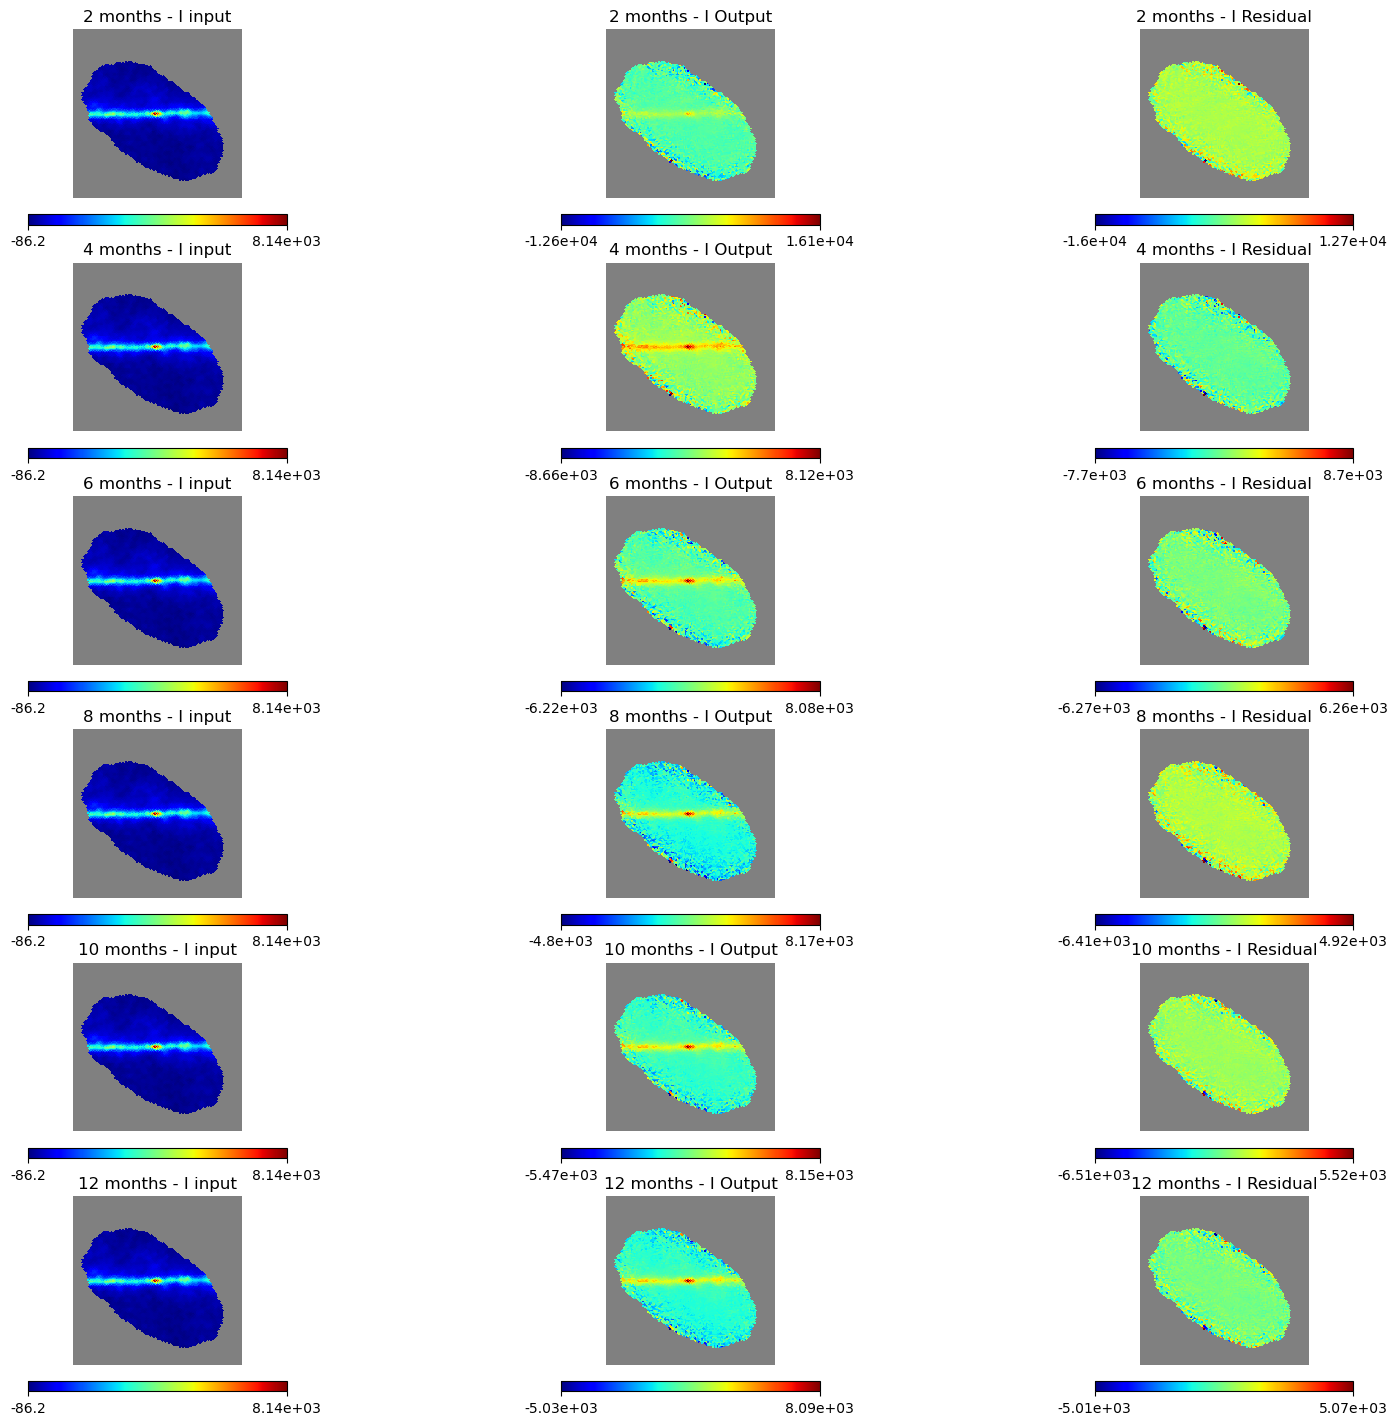

In [106]:
maps_input = np.mean(data["maps_in_cum"], axis=1)
maps_rec = np.mean(data["maps_cum"], axis=1)
maps_res = np.mean(data["maps_res_cum"], axis=1)
seenpix = data["seenpix_cum"]

maps_input = np.where(seenpix, maps_input, hp.UNSEEN)
maps_rec = np.where(seenpix, maps_rec, hp.UNSEEN)
maps_res = np.where(seenpix, maps_res, hp.UNSEEN)

nus = data["nus"]
center = data["center"]
coverage = data["coverage_cum"]

k=0 

plt.figure(figsize=(16, 14))
for i in range(6):
    hp.gnomview((maps_input[i, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I input",  
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(6, 3, k + 1))
    
    hp.gnomview((maps_rec[i, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I Output",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(6, 3, k + 2))
    
    hp.gnomview(maps_res[i, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - I Residual",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(6, 3, k + 3))
    k += 3

In [107]:
# Deviazione standard delle mappe dei residui
stds = []
for i in range(6):
    stds.append(np.std(maps_res[i,seenpix[i]]))

np.array(stds)

array([1486.18754509,  993.37364371,  802.67934059,  700.00264503,
        631.14747932,  576.8331763 ])

In [108]:
# Confronto con andamento inversamente proporzionale a radice di N
np.std(maps_res[0,seenpix[0]])/np.sqrt(np.arange(1,7))

array([1486.18754509, 1050.89329125,  858.05077922,  743.09377254,
        664.64327563,  606.73352459])

In [109]:
# calcolo manuale della deviazione standard della media delle varie mappe assumendole scorrelate
res = np.mean(data['maps_res'], axis=1)
stds = []
for i in range(6):
    stds.append(np.std(res[i][data['seenpix'][i]]))
np.sqrt(np.cumsum(np.array(stds)**2))/np.arange(1,7)

array([1486.18762207, 1015.59344482,  824.55924479,  709.08154297,
        637.16040039,  578.46887207])

<Axes: title={'center': 'Correlation matrix reconstructed maps'}>

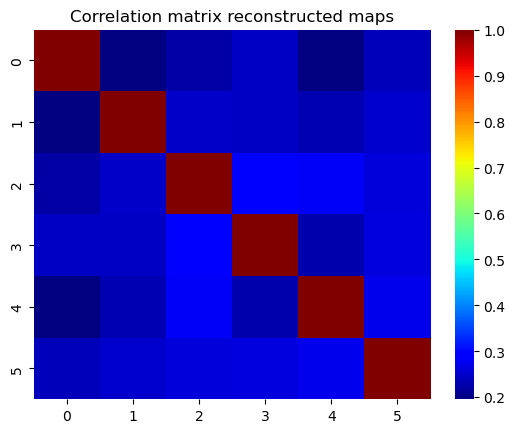

In [ ]:
rec = np.mean(data['maps_rec'], axis=1)
idx = np.argmin(np.sum(data['seenpix'], axis=1))
X = np.array([map[data['seenpix'][idx]] for map in rec])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix reconstructed maps')
sns.heatmap(corr, cmap='jet')

In [112]:
print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

Minimum correlation: 0.19571360538567972
Maximum correlation: 0.28422708191335433


<Axes: title={'center': 'Correlation matrix residual maps'}>

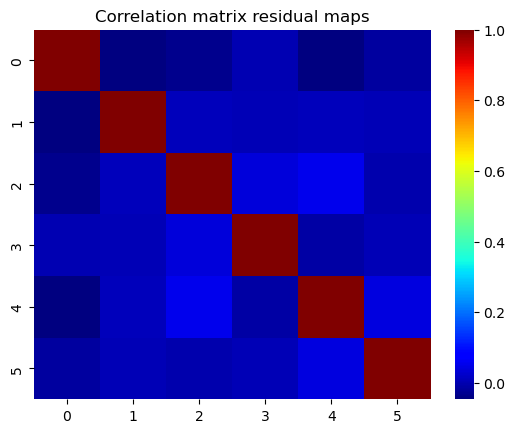

In [114]:
X = np.array([map[data['seenpix'][idx]] for map in res])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix residual maps')
sns.heatmap(corr, cmap='jet')

In [115]:
print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

Minimum correlation: -0.04633379379161069
Maximum correlation: 0.05518582847186313


## Scanning strategy with rotating HWP and with correct noise

In [7]:
datafiles= ["/media/mattia/Hard Disk/data/center/maps/final/01-02.pkl",
            "/media/mattia/Hard Disk/data/center/maps/final/03-04.pkl",
            "/media/mattia/Hard Disk/data/center/maps/final/05-06.pkl",
            "/media/mattia/Hard Disk/data/center/maps/final/07-08.pkl",
            "/media/mattia/Hard Disk/data/center/maps/final/09-10.pkl",
            "/media/mattia/Hard Disk/data/center/maps/final/11-12.pkl",
]

In [8]:
data = maps_stacking(datafiles)

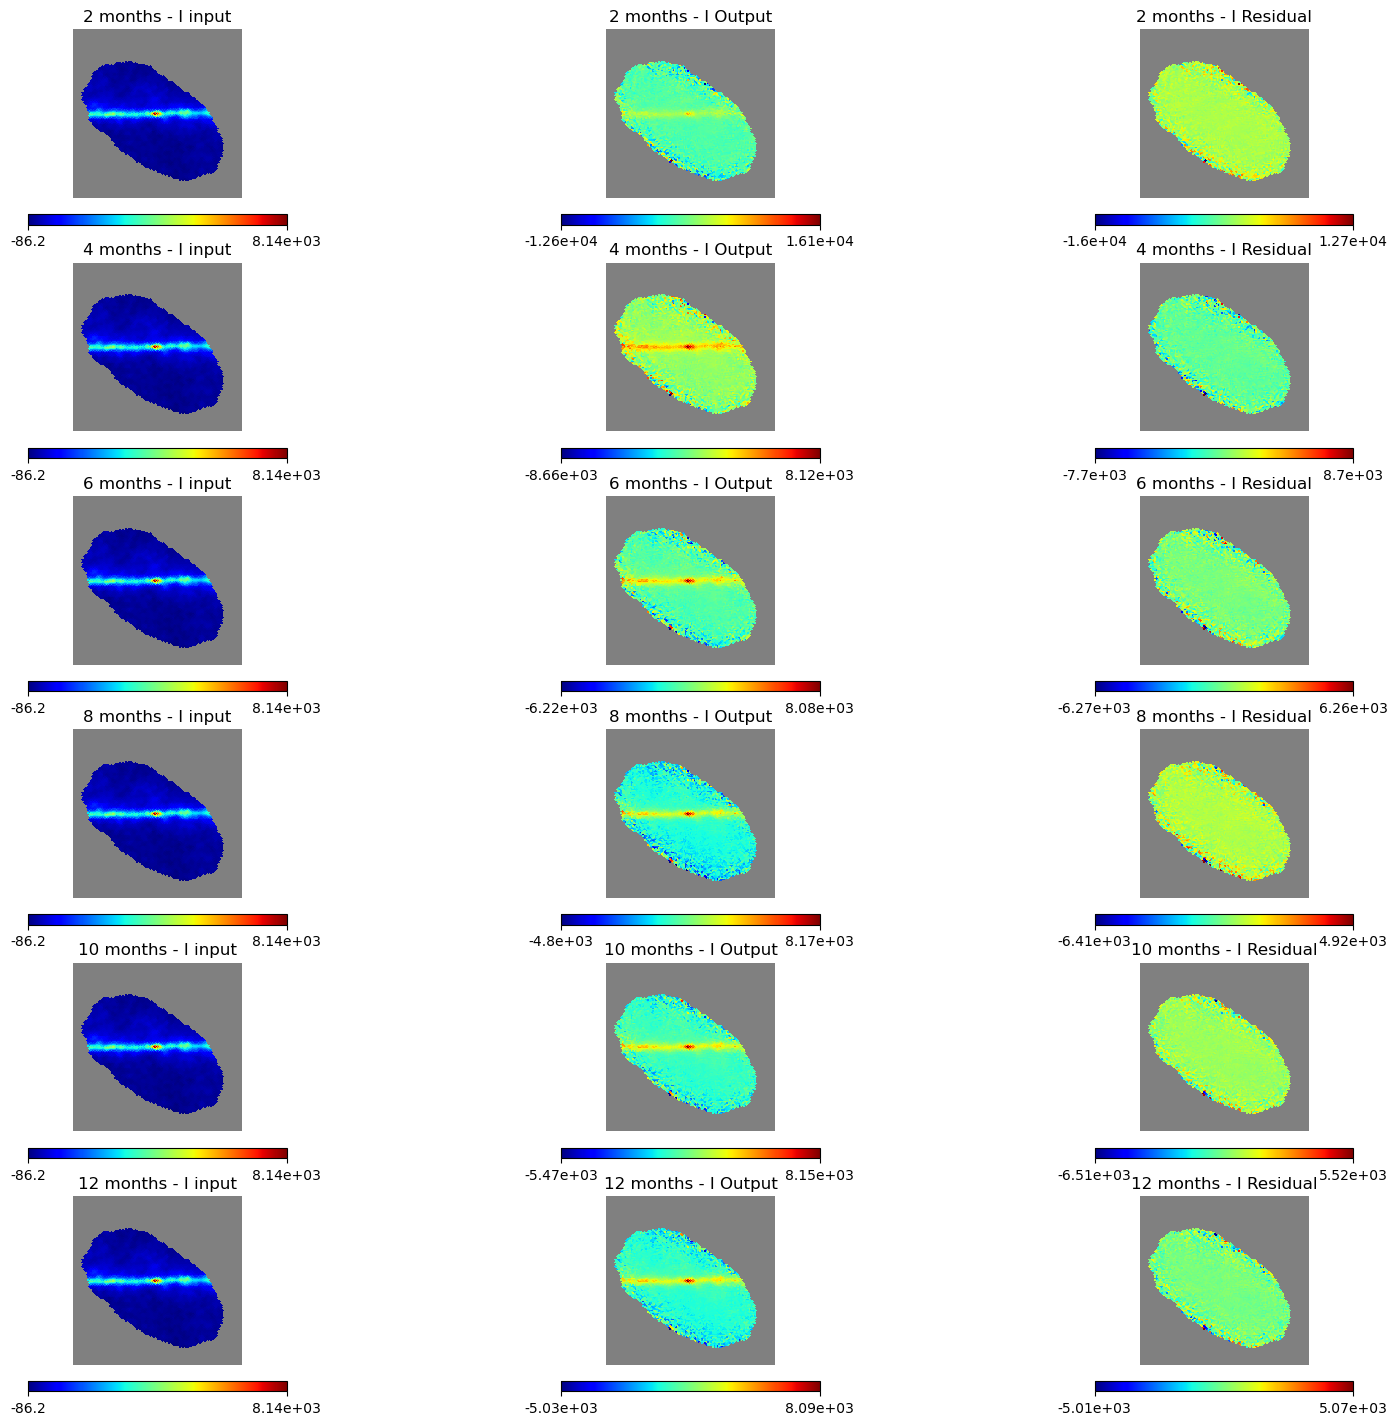

In [ ]:
maps_input = np.mean(data["maps_in_cum"], axis=1)
maps_rec = np.mean(data["maps_cum"], axis=1)
maps_res = np.mean(data["maps_res_cum"], axis=1)
seenpix = data["seenpix_cum"]

maps_input = np.where(seenpix, maps_input, hp.UNSEEN)
maps_rec = np.where(seenpix, maps_rec, hp.UNSEEN)
maps_res = np.where(seenpix, maps_res, hp.UNSEEN)

valid_res = maps_res[i, maps_res[i] != hp.UNSEEN]
sigma_res = np.std(valid_res)

nus = data["nus"]
center = data["center"]
coverage = data["coverage_cum"]

k=0 

plt.figure(figsize=(12,18))
for i in range(len(datafiles)):
    hp.gnomview((maps_input[i, :]), rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I input",  
                        cmap="jet",
                        unit=r"$\mu K_{CMB}$",
                        sub=(6, 3, k + 1))
    
    hp.gnomview((maps_rec[i, :]), rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I Output",
                        cmap="jet",
                        unit=r"$\mu K_{CMB}$",   
                        sub=(6, 3, k + 2))
    
    hp.gnomview(maps_res[i, :], rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I Residual",
                        cmap="jet",
                        min=-3*sigma_res, max=3*sigma_res,
                        unit=r"$\mu K_{CMB}$",
                        sub=(6, 3, k + 3))


    ax = plt.gca()
    ax.text(0.95, 0.95, rf"$\sigma = {sigma:.0f}$",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, weight="bold", color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5))
            
    k += 3

Deviazione standard delle mappe dei residui: [1486.18754509  993.37364371  802.67934114  700.00264526  631.14747918
  576.83317786]
Deviazione standard della media delle mappe dei residui assumendole scorrelate: [1486.18762207 1015.59344482  824.55924479  709.08154297  637.16040039
  578.46887207]


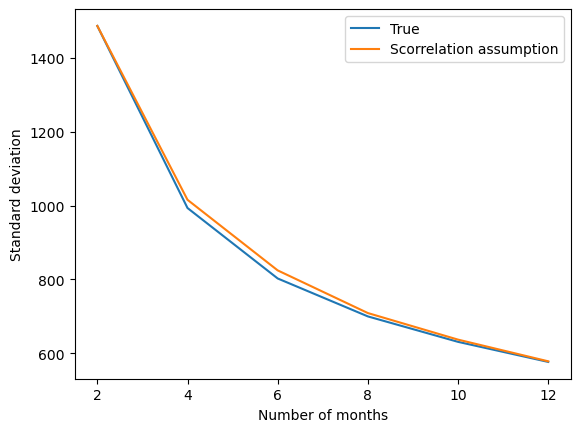

In [ ]:
# Standard deviation from residual maps
stds = []
for i in range(6):
    stds.append(np.std(maps_res[i,seenpix[i]]))

print('Standard deviation of the residual maps:', np.array(stds))
plt.plot(np.arange(2,14,2), stds, label='True')

# Standard deviation of the stackd maps assuming uncorrelation
res = np.mean(data['maps_res'], axis=1)
stds = []
for i in range(6):
    stds.append(np.std(res[i][data['seenpix'][i]]))
stds2 = np.sqrt(np.cumsum(np.array(stds)**2))/np.arange(1,7)

print('Standard deviation of the stackd maps assuming uncorrelation:', stds2)
plt.plot(np.arange(2,14,2), stds2, label='Scorrelation assumption')

plt.xlabel('Number of months')
plt.ylabel('Standard deviation')
plt.legend()

Minimum correlation: 0.19571360065421223
Maximum correlation: 0.28422708076701525


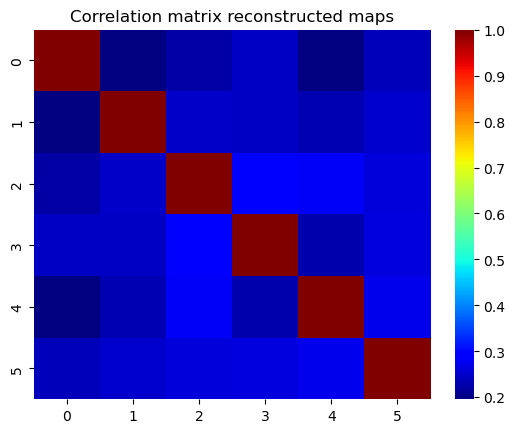

In [11]:
rec = np.mean(data['maps_rec'], axis=1)
idx = np.argmin(np.sum(data['seenpix'], axis=1))
X = np.array([map[data['seenpix'][idx]] for map in rec])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix reconstructed maps')
sns.heatmap(corr, cmap='jet')

print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

Minimum correlation: -0.04633379379161069
Maximum correlation: 0.05518582735962934


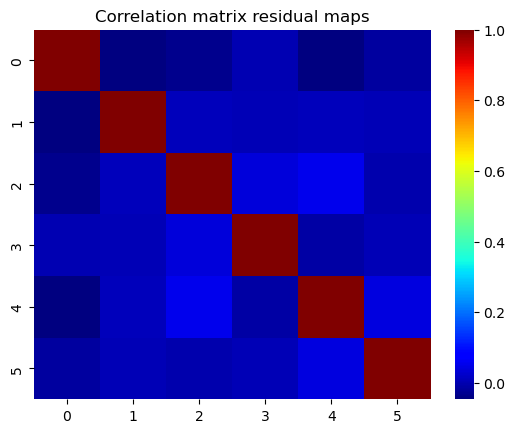

In [12]:
X = np.array([map[data['seenpix'][idx]] for map in res])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix residual maps')
sns.heatmap(corr, cmap='jet')

print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

In [13]:
print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

Minimum correlation: -0.04633379379161069
Maximum correlation: 0.05518582735962934


<Axes: title={'center': 'Correlation matrix TODs'}>

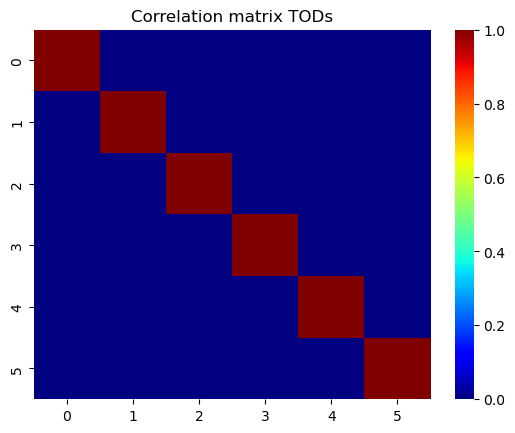

In [14]:
tod_corr = np.load("/media/mattia/Hard Disk/data/center/tod_correlations.npy")
plt.figure()
plt.title('Correlation matrix TODs')
sns.heatmap(tod_corr, cmap='jet')

### Noise estimation and SNR maps

Residual weighted std 372.2324580172474


/tmp/ipykernel_8489/780519119.py:215: RuntimeWarning: divide by zero encountered in divide
  snr = maps_input / sigma
/tmp/ipykernel_8489/780519119.py:251: RuntimeWarning: divide by zero encountered in divide
  snr = maps_input / sigma


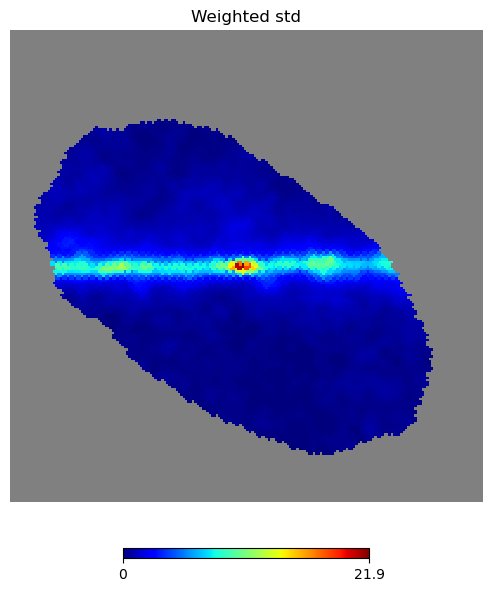

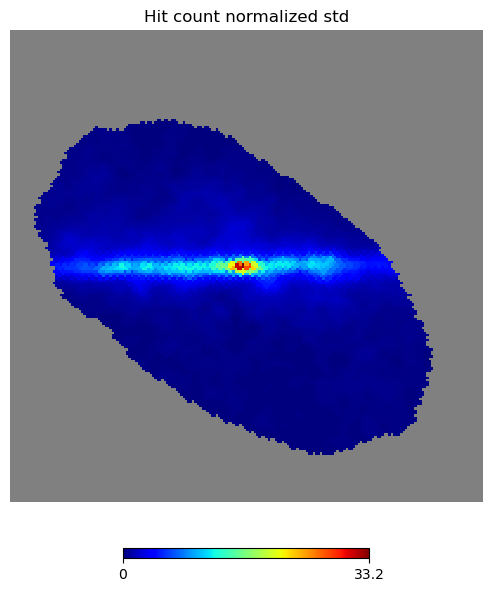

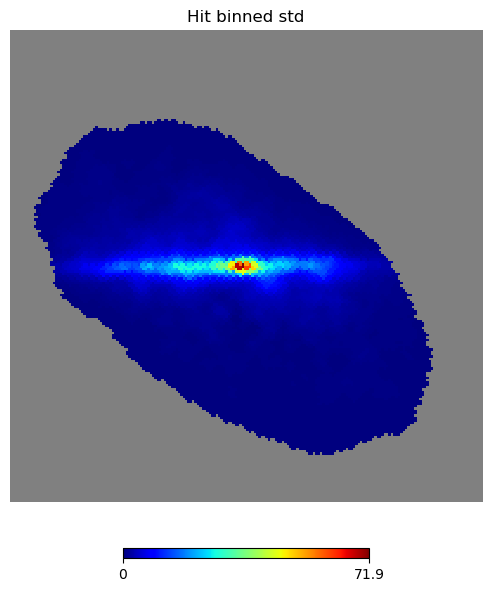

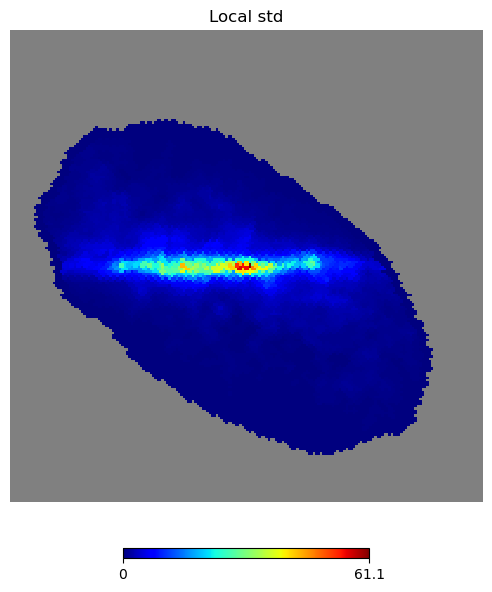

In [15]:
noises = noise_estimation(maps_input[-1], maps_res[-1], coverage[-1], seenpix[-1])

Correlation between coverage and binned noise: -0.8348362624595713
Correlation between 1/sqrt(coverage) and binned noise: 0.9853189650570082
Correlation between coverage and binned noise: -0.8501565134859594
Correlation between 1/sqrt(coverage) and binned noise: 0.9891326900292099
Correlation between coverage and binned noise: -0.8438015945472894
Correlation between 1/sqrt(coverage) and binned noise: 0.9855387617161512
Correlation between coverage and binned noise: -0.8332386358999829
Correlation between 1/sqrt(coverage) and binned noise: 0.9838742915710861
Correlation between coverage and binned noise: -0.823290438875622
Correlation between 1/sqrt(coverage) and binned noise: 0.9803752951331244
Correlation between coverage and binned noise: -0.8245605057564313
Correlation between 1/sqrt(coverage) and binned noise: 0.9814381981654388


<Figure size 1000x500 with 0 Axes>

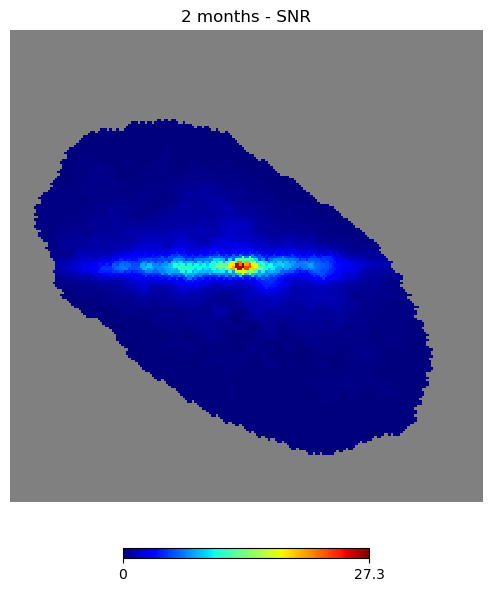

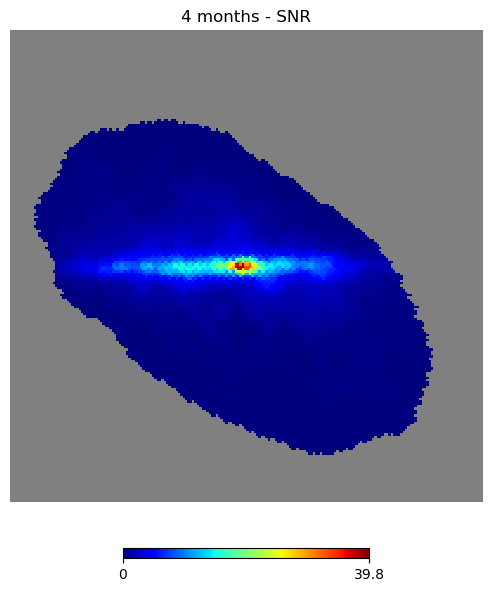

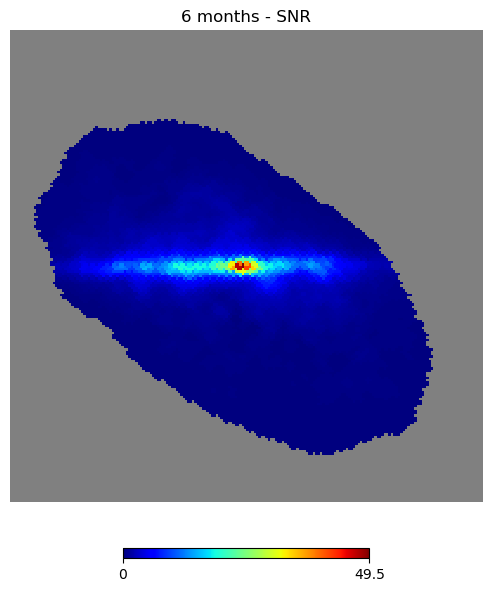

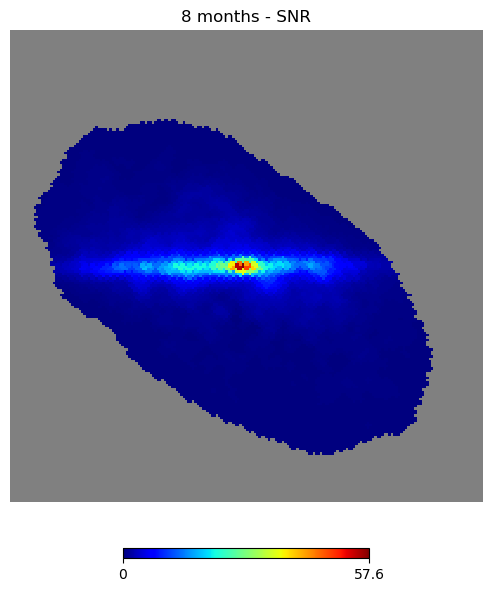

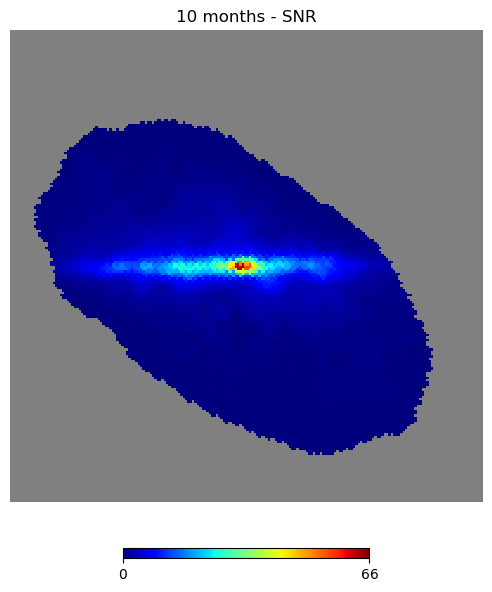

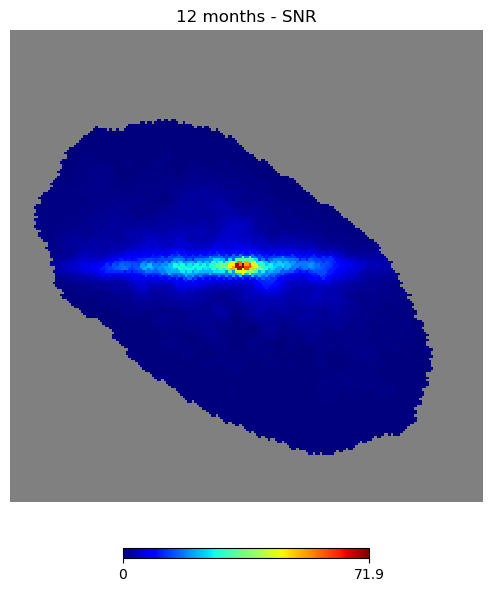

In [ ]:
# SNR computed from the standard deviation of pixels divived into coverage bins
snr_bin = []
for i in range(6):
    snr_bin.append(snr_from_coverage_bins(maps_input[i], maps_res[i], coverage[i], seenpix[i], center, nbins=20, plot=False, verbose=True)[0])

plt.figure(figsize=(10, 5))
for i in range(6):
    snr_bin[i][~seenpix[i]] = hp.UNSEEN
    hp.gnomview(snr_bin[i], rot=center, reso=15, notext=True,
                        title=f"{i*2+2} months - SNR",  cmap="jet", min = 0,)

Correlation between coverage and binned noise: -0.6673877314879391
Correlation between 1/sqrt(coverage) and binned noise: 0.7683158353819413
Correlation between coverage and binned noise: -0.6737628642836264
Correlation between 1/sqrt(coverage) and binned noise: 0.7671256035537625
Correlation between coverage and binned noise: -0.6820956401881441
Correlation between 1/sqrt(coverage) and binned noise: 0.7798108967571807
Correlation between coverage and binned noise: -0.6672196298933154
Correlation between 1/sqrt(coverage) and binned noise: 0.7634076990924779
Correlation between coverage and binned noise: -0.6676113284463643
Correlation between 1/sqrt(coverage) and binned noise: 0.7676998848953158
Correlation between coverage and binned noise: -0.672529990471396
Correlation between 1/sqrt(coverage) and binned noise: 0.7753120038905961


<Figure size 1000x500 with 0 Axes>

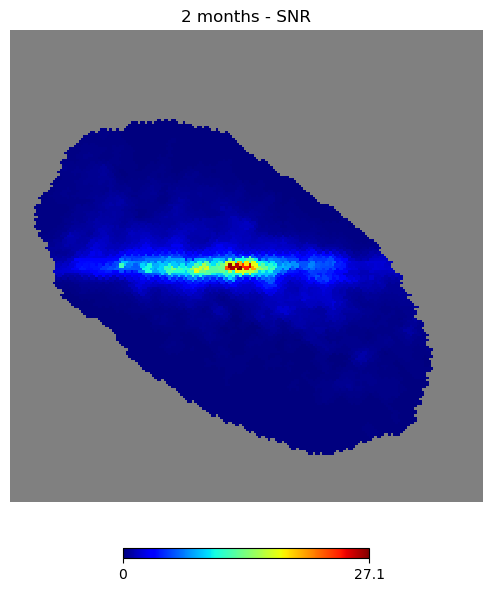

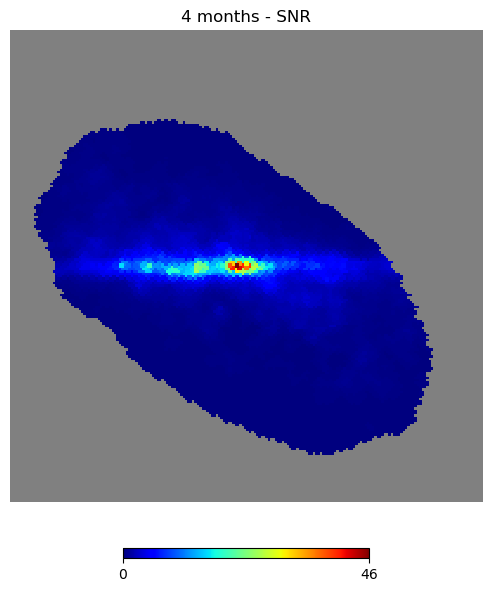

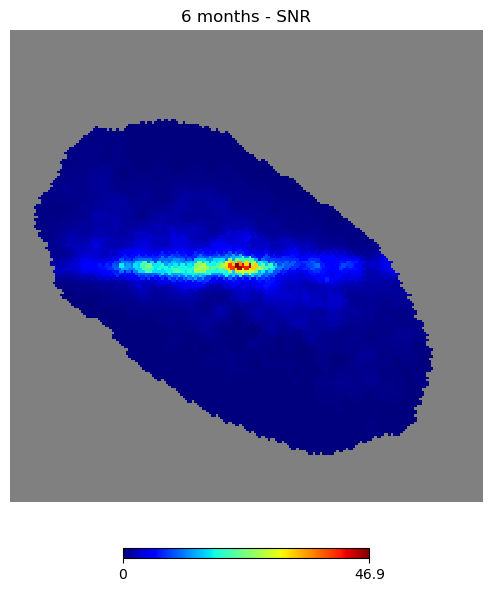

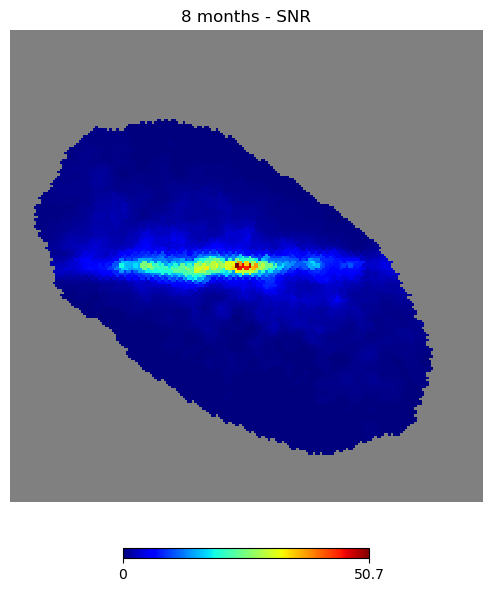

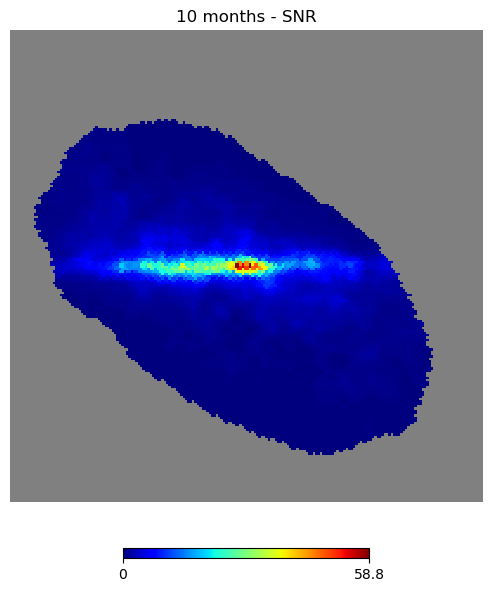

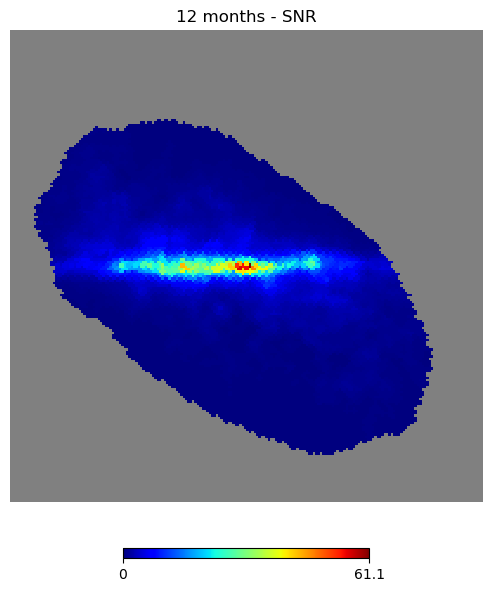

In [ ]:
# SNR computed from local standard deviation
snr_local = []
for i in range(6):
    snr_local.append(snr_from_local_std(maps_input[i], maps_res[i], coverage[i], seenpix[i], center, radius_deg=1., plot=False, verbose=True)[0])

plt.figure(figsize=(10, 5))
for i in range(6):
    snr_local[i][~seenpix[i]] = hp.UNSEEN
    hp.gnomview(snr_local[i], rot=center, reso=15, notext=True,
                        title=f"{i*2+2} months - SNR",  cmap="jet", min = 0,)

Text(0, 0.5, 'SNR')

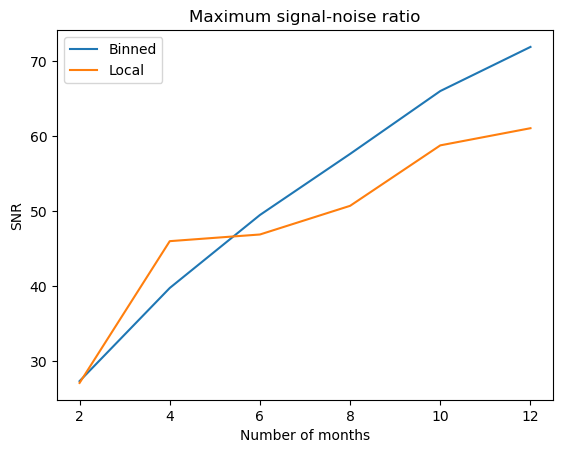

In [26]:
plt.plot(np.arange(2,14,2), np.max(snr_bin, axis=1), label='Binned')
plt.plot(np.arange(2,14,2), np.max(snr_local, axis=1), label='Local')
plt.title('Maximum signal-noise ratio')
plt.legend()
plt.xlabel('Number of months')
plt.ylabel('SNR')

Text(0, 0.5, 'Percentage')

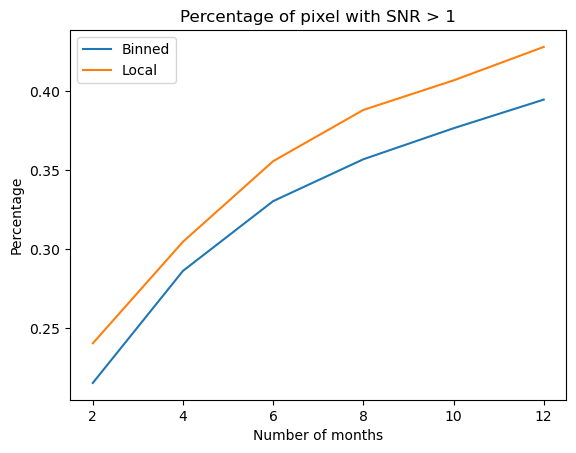

In [27]:
high_snr_bin = []
high_snr_local = []
for i in range(6):
    high_snr_bin.append(np.count_nonzero(snr_bin[i][seenpix[i]] > 1) / len(snr_bin[i][seenpix[i]]))
    high_snr_local.append(np.count_nonzero(snr_local[i][seenpix[i]] > 1) / len(snr_local[i][seenpix[i]]))

plt.plot(np.arange(2,14,2), high_snr_bin, label='Binned')
plt.plot(np.arange(2,14,2), high_snr_local, label='Local')
plt.title('Percentage of pixel with SNR > 1')
plt.legend()
plt.xlabel('Number of months')
plt.ylabel('Percentage')

In [ ]:
# Save data for comparison

results = {
    "name": "center",
    "h_per_day": np.mean(hours_day),
    "n_pix": {},
    "mean_snr_above": {},
}

for theta in [1, 2, 3]:
    n_pix = []
    mean_snr = []
    for i in range(6):
        valid = snr_bin[i][seenpix[i]]
        above = valid[valid > theta]
        n_pix.append(np.count_nonzero(above))
        mean_snr.append(np.mean(above) if len(above) > 0 else 0.0)
    results["n_pix"][theta]      = np.array(n_pix)
    results["mean_snr_above"][theta] = np.array(mean_snr)

pickle.dump(results, open("center_comparison.pkl", "wb"))

region_name = "center"   
save_dir = "/home/mattia/tesi/data/snr_maps/"
for i in range(6):
    np.save(f"{save_dir}snr_{region_name}_{(i+1)*2}m.npy", snr_bin[i])
    np.save(f"{save_dir}seenpix_{region_name}_{(i+1)*2}m.npy", seenpix[i])

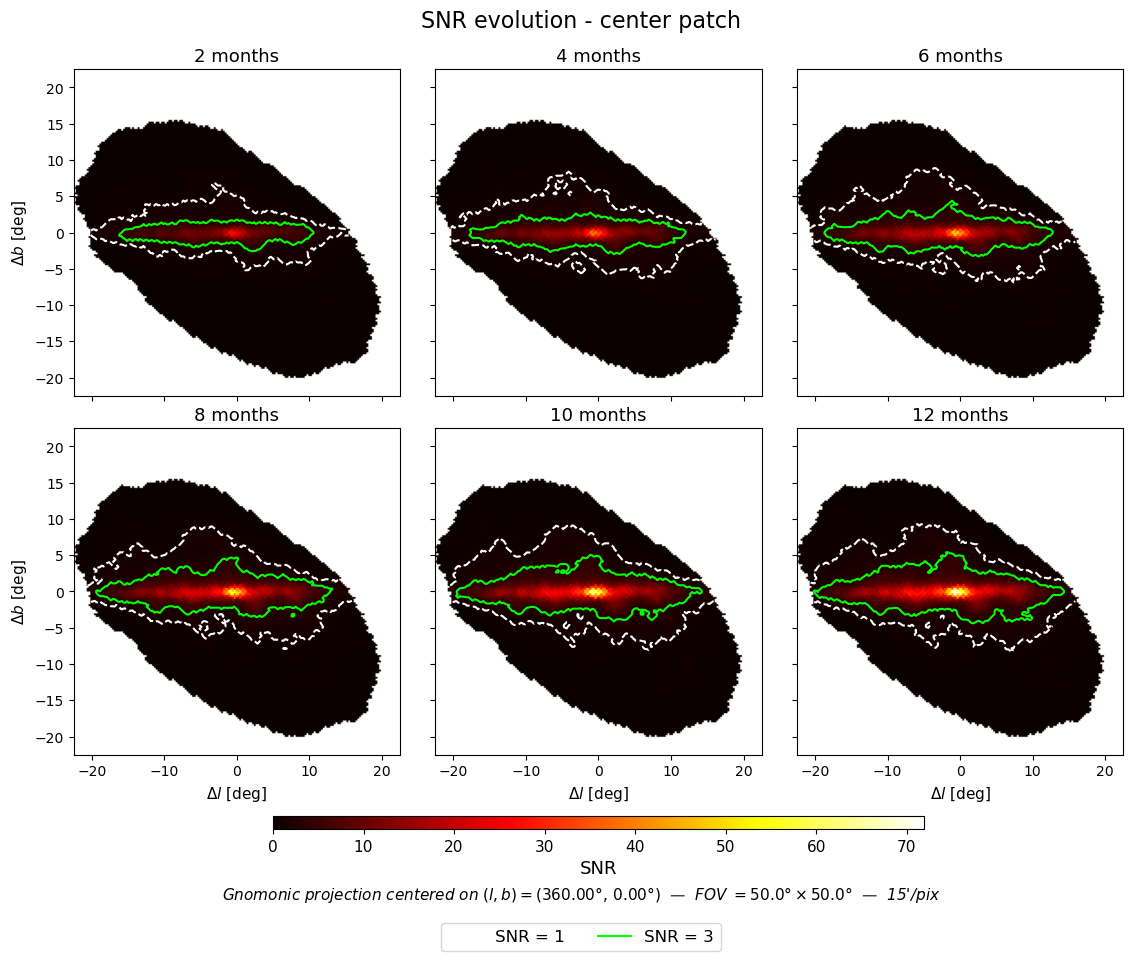

In [11]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ── Configuration ──
region_name = "center"
center = center      # (l, b) galattiche
vmax = 71.9
reso = 15                      # arcmin/pixel
xsize = 200

months_list = [2, 4, 6, 8, 10, 12]
snr_levels = [1, 3]
level_colors = ["white", "lime"]
level_styles = ["--", "-"]

# FOV in gradi
fov = xsize * reso / 60.0
extent = [-fov/2, fov/2, -fov/2, fov/2]  # gradi da centro

# ── Project all maps ──
projected = []
for i in range(6):
    snr_temp = snr_bin[i].copy()
    snr_temp[~seenpix[i]] = hp.UNSEEN
    proj = hp.gnomview(snr_temp, rot=center, reso=reso, xsize=xsize,
                       return_projected_map=True, no_plot=True)
    projected.append(np.ma.masked_equal(proj, hp.UNSEEN))

# ── Plot 2x3 grid ──
fig, axes = plt.subplots(2, 3, figsize=(14, 10),
                         gridspec_kw={"hspace": 0.1, "wspace": 0.})
norm = Normalize(vmin=0, vmax=vmax)

for idx, (ax, month, proj) in enumerate(zip(axes.flat, months_list, projected)):
    im = ax.imshow(proj, origin="lower", cmap="hot", norm=norm, extent=extent)

    ax.contour(proj, levels=snr_levels, colors=level_colors,
               linewidths=1.5, linestyles=level_styles,
               extent=extent, origin="lower")

    ax.set_title(f"{month} months", fontsize=13)
    margin = fov / 2 * 0.9
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    #ax.set_xlabel(r"$\Delta l$ [deg]", fontsize=11)
    #ax.set_ylabel(r"$\Delta b$ [deg]", fontsize=11)
    ax.tick_params(labelsize=10)
    # Label solo sui bordi esterni
    if idx % 3 == 0:
        ax.set_ylabel(r"$\Delta b$ [deg]", fontsize=11)
    else:
        ax.set_yticklabels([])
    if idx >= 3:
        ax.set_xlabel(r"$\Delta l$ [deg]", fontsize=11)
    else:
        ax.set_xticklabels([])

# Annotazione centro sotto la riga inferiore
fig.text(0.5, 0.05,
         rf"Gnomonic projection centered on $(l, b) = ({center[0]:.2f}°,\, {center[1]:.2f}°)$"
         rf"  —  FOV $= {fov:.1f}° \times {fov:.1f}°$  —  {reso}'/pix",
         ha="center", fontsize=11, style="italic")

# Colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    fraction=0.03, pad=0.08, aspect=50, shrink=0.6)
cbar.set_label("SNR", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Legenda contorni
legend_handles = [Line2D([0], [0], color=c, ls=ls, lw=1.5,
                         label=rf"SNR = {l}")
                  for l, c, ls, in zip(snr_levels, level_colors, level_styles)]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=12, frameon=True, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(f"SNR evolution - {region_name} patch", fontsize=16, y=0.94)

plt.savefig(f"/home/mattia/tesi/tesi/figures/snr_maps_{region_name}.pdf", bbox_inches="tight")

### SED (not working)

In [13]:
maps_input_nobeam_freq = data["maps_in_nobeam_cum"]
maps_input_freq = data["maps_in_cum"]
maps_rec_freq = data["maps_cum"]
maps_res_freq = data["maps_res_cum"]
seenpix = data["seenpix_cum"]

maps_input_freq = np.where(seenpix[:, None, :], maps_input_freq, hp.UNSEEN)
maps_input_nobeam_freq = np.where(seenpix[:, None, :], maps_input_nobeam_freq, hp.UNSEEN)
maps_rec_freq = np.where(seenpix[:, None, :], maps_rec_freq, hp.UNSEEN)
maps_res_freq = np.where(seenpix[:, None, :], maps_res_freq, hp.UNSEEN)

nus = data["nus"]
Nrec = nus.shape[0] - 7
center = data["center"]
coverage = data["coverage_cum"]

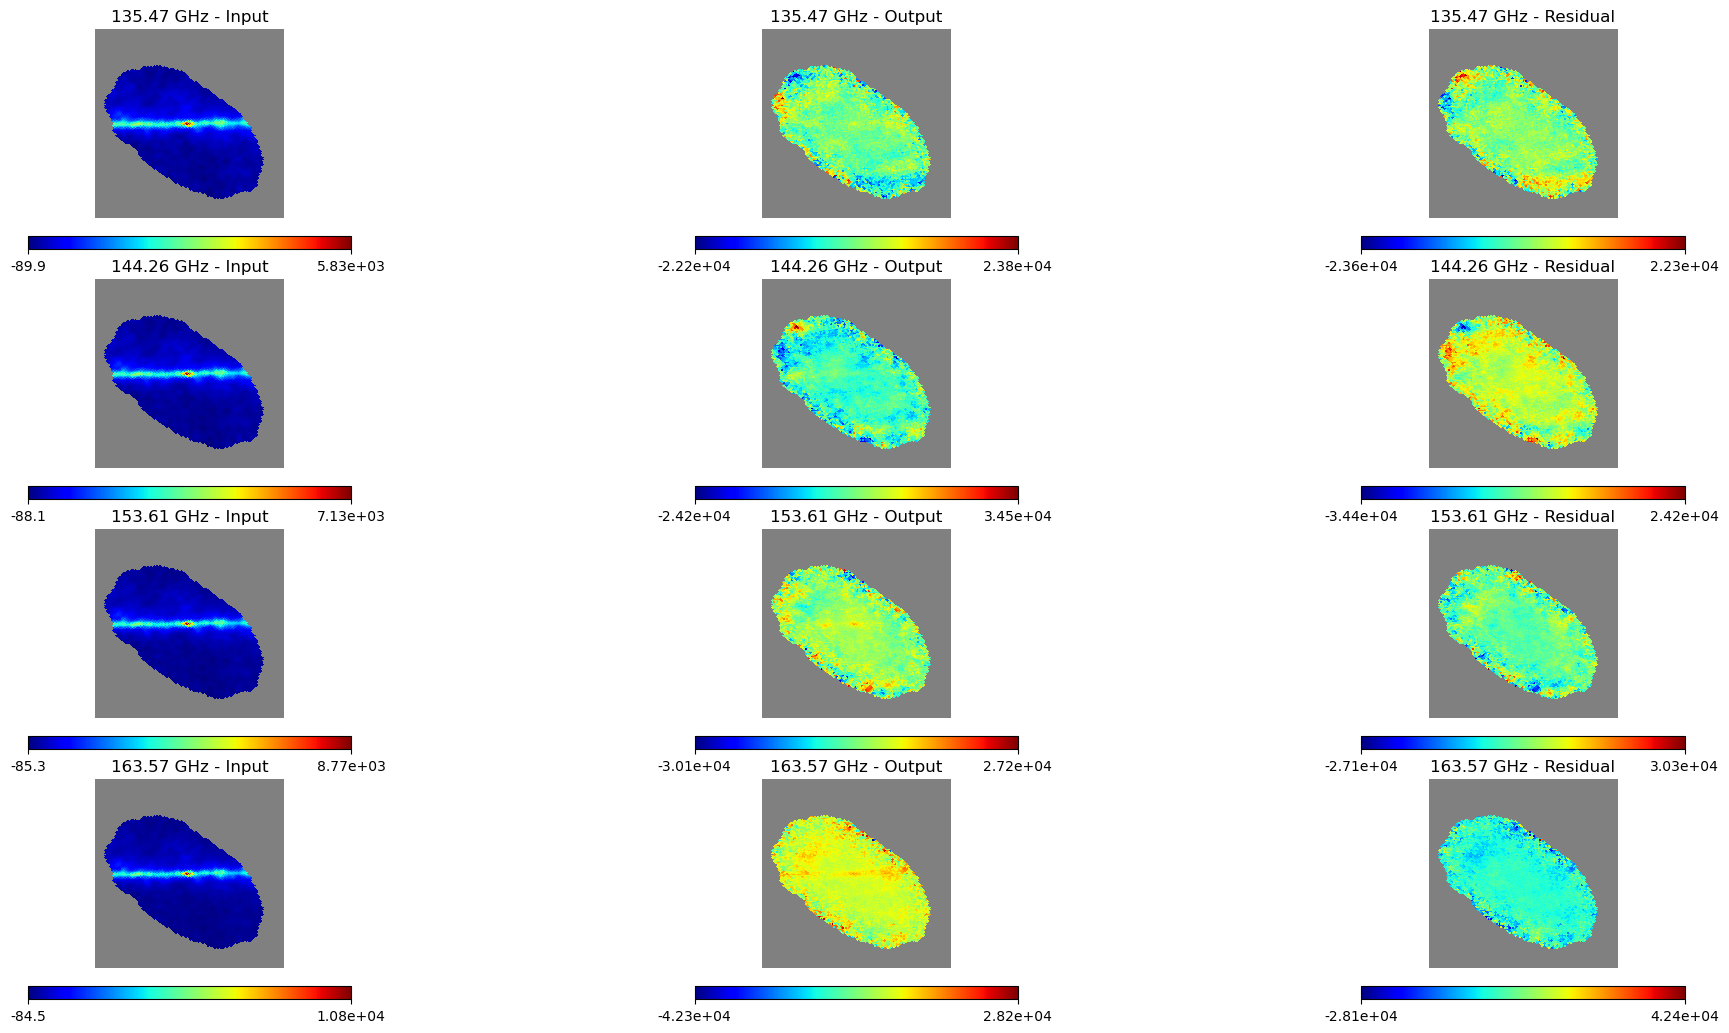

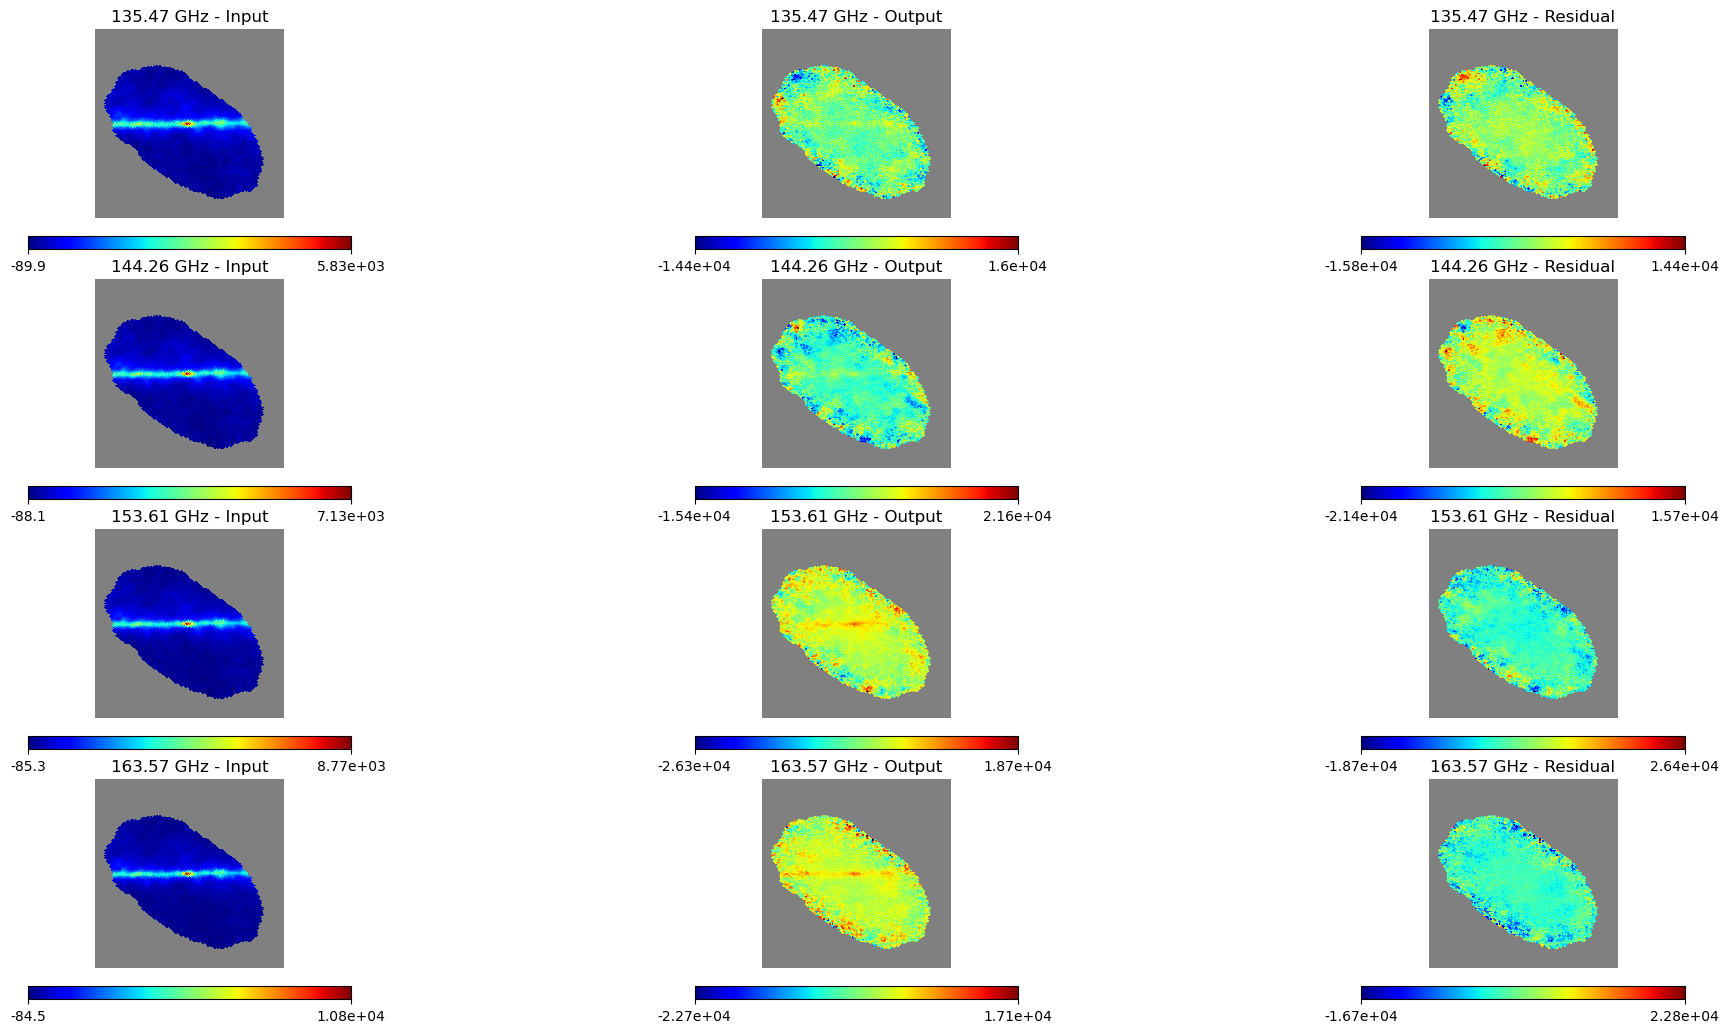

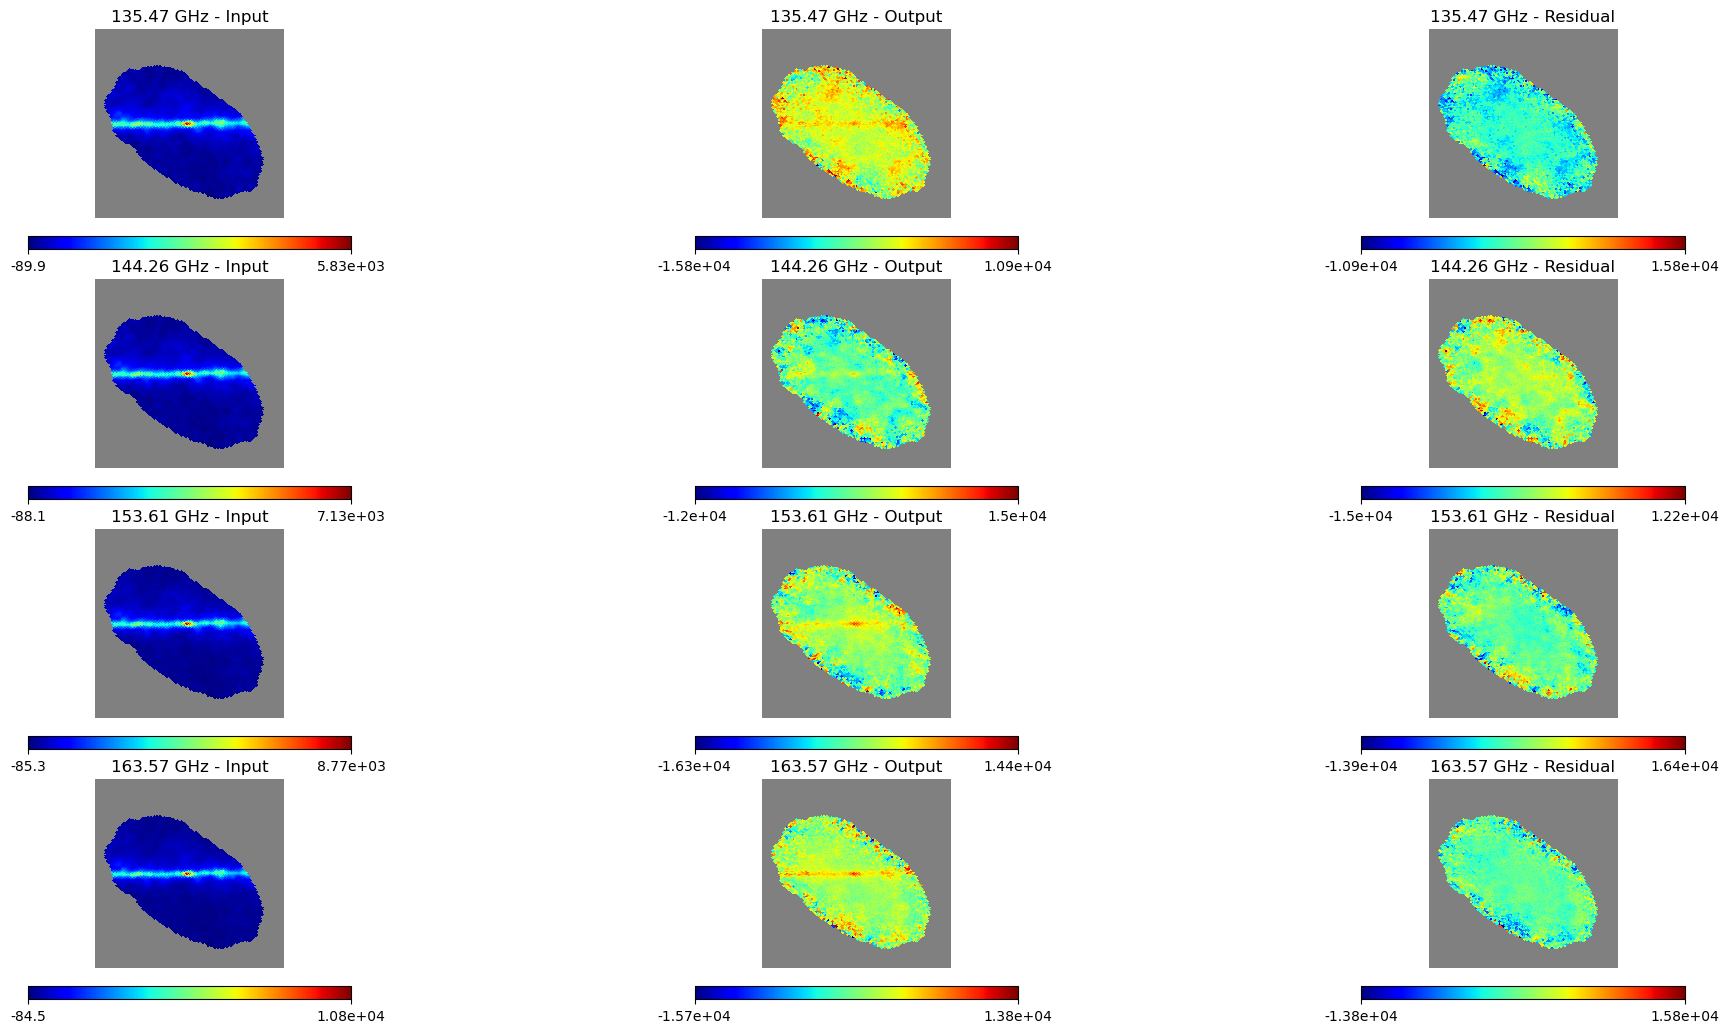

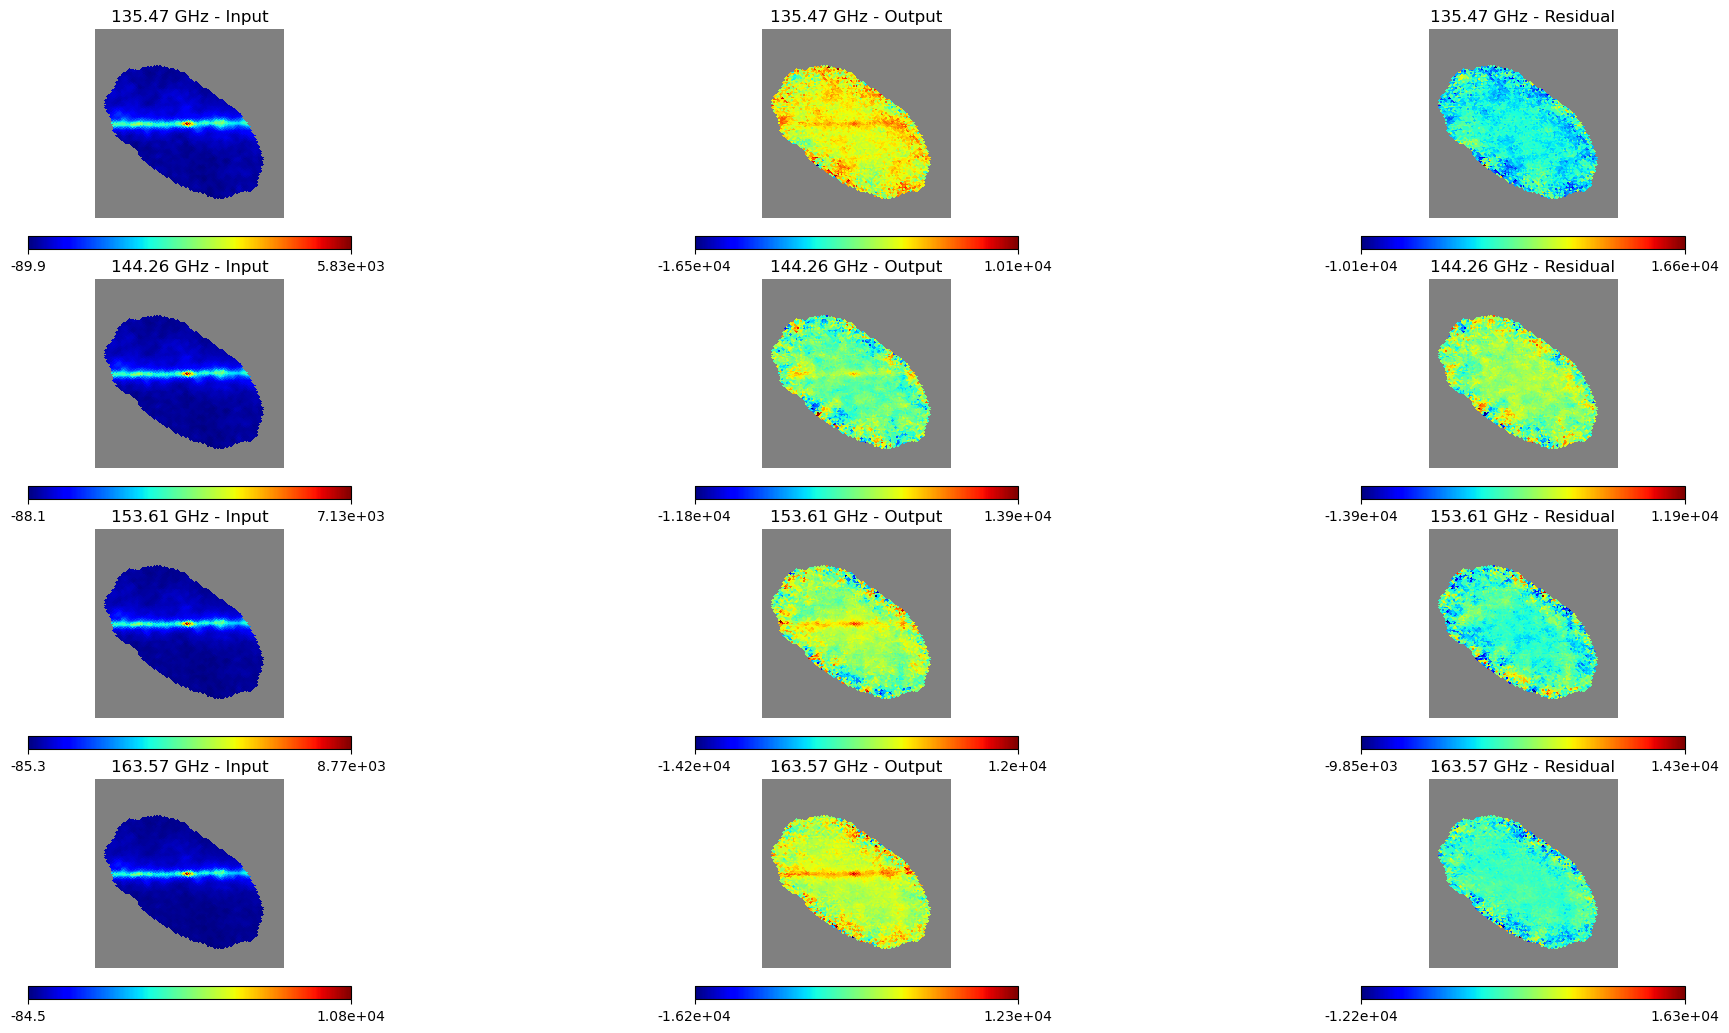

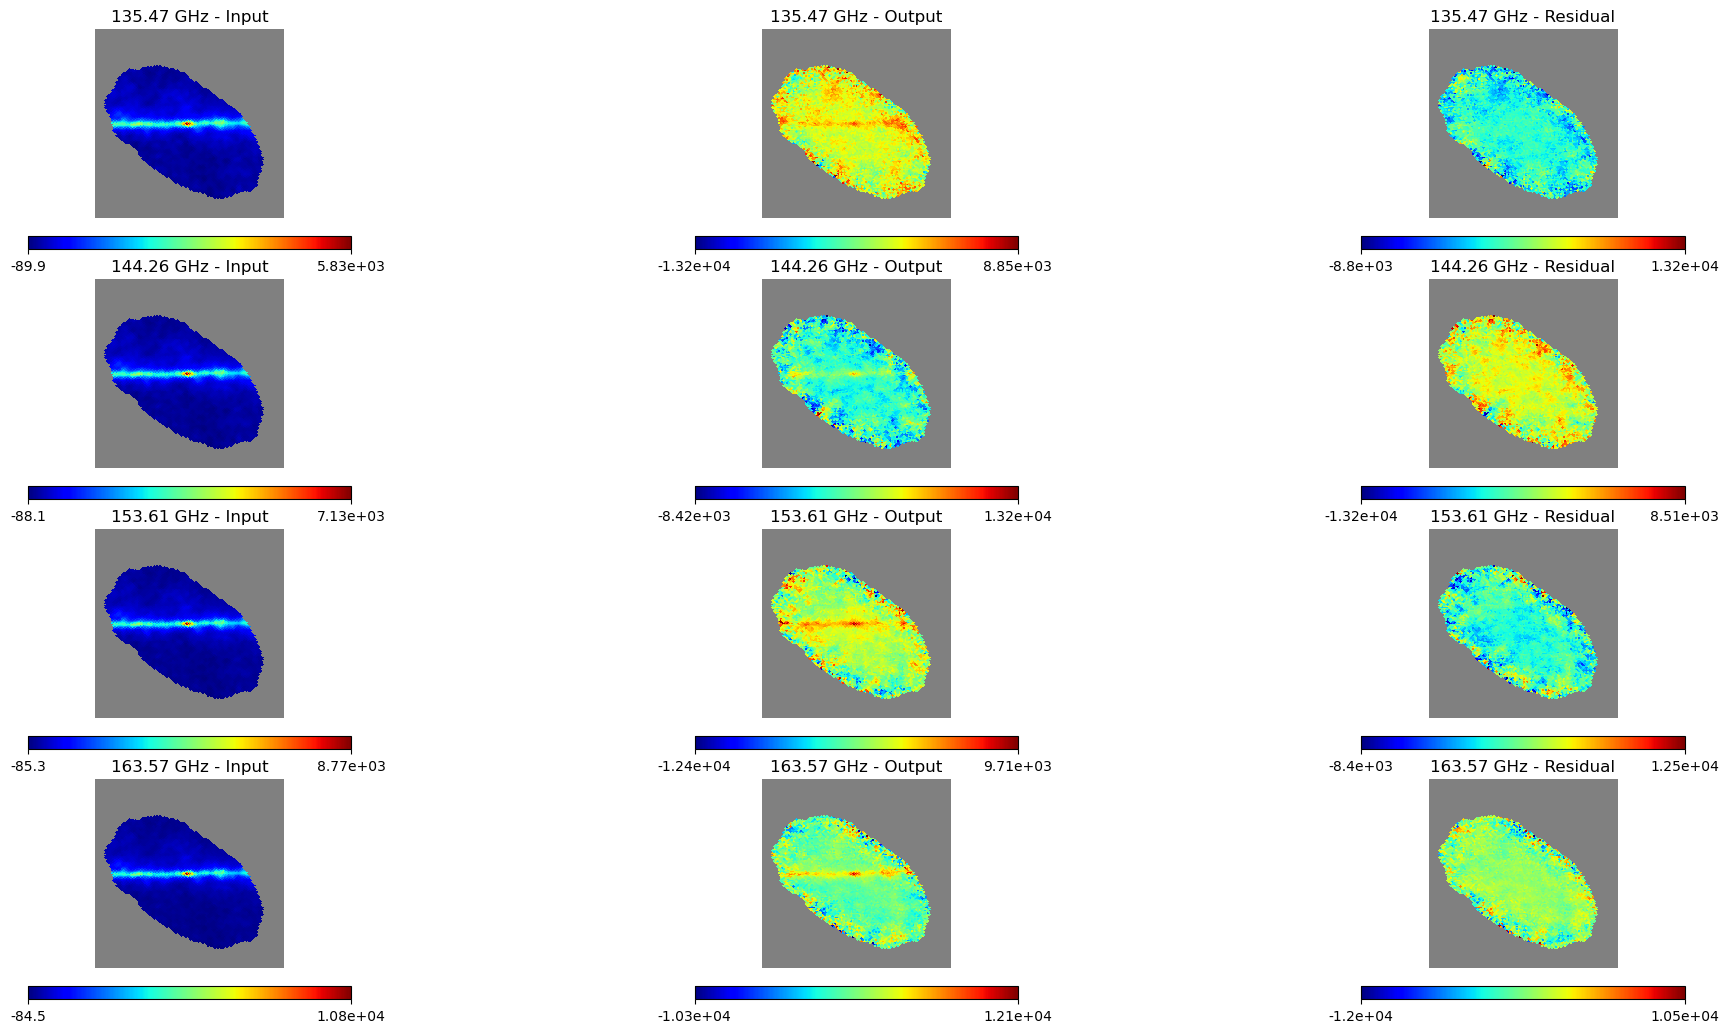

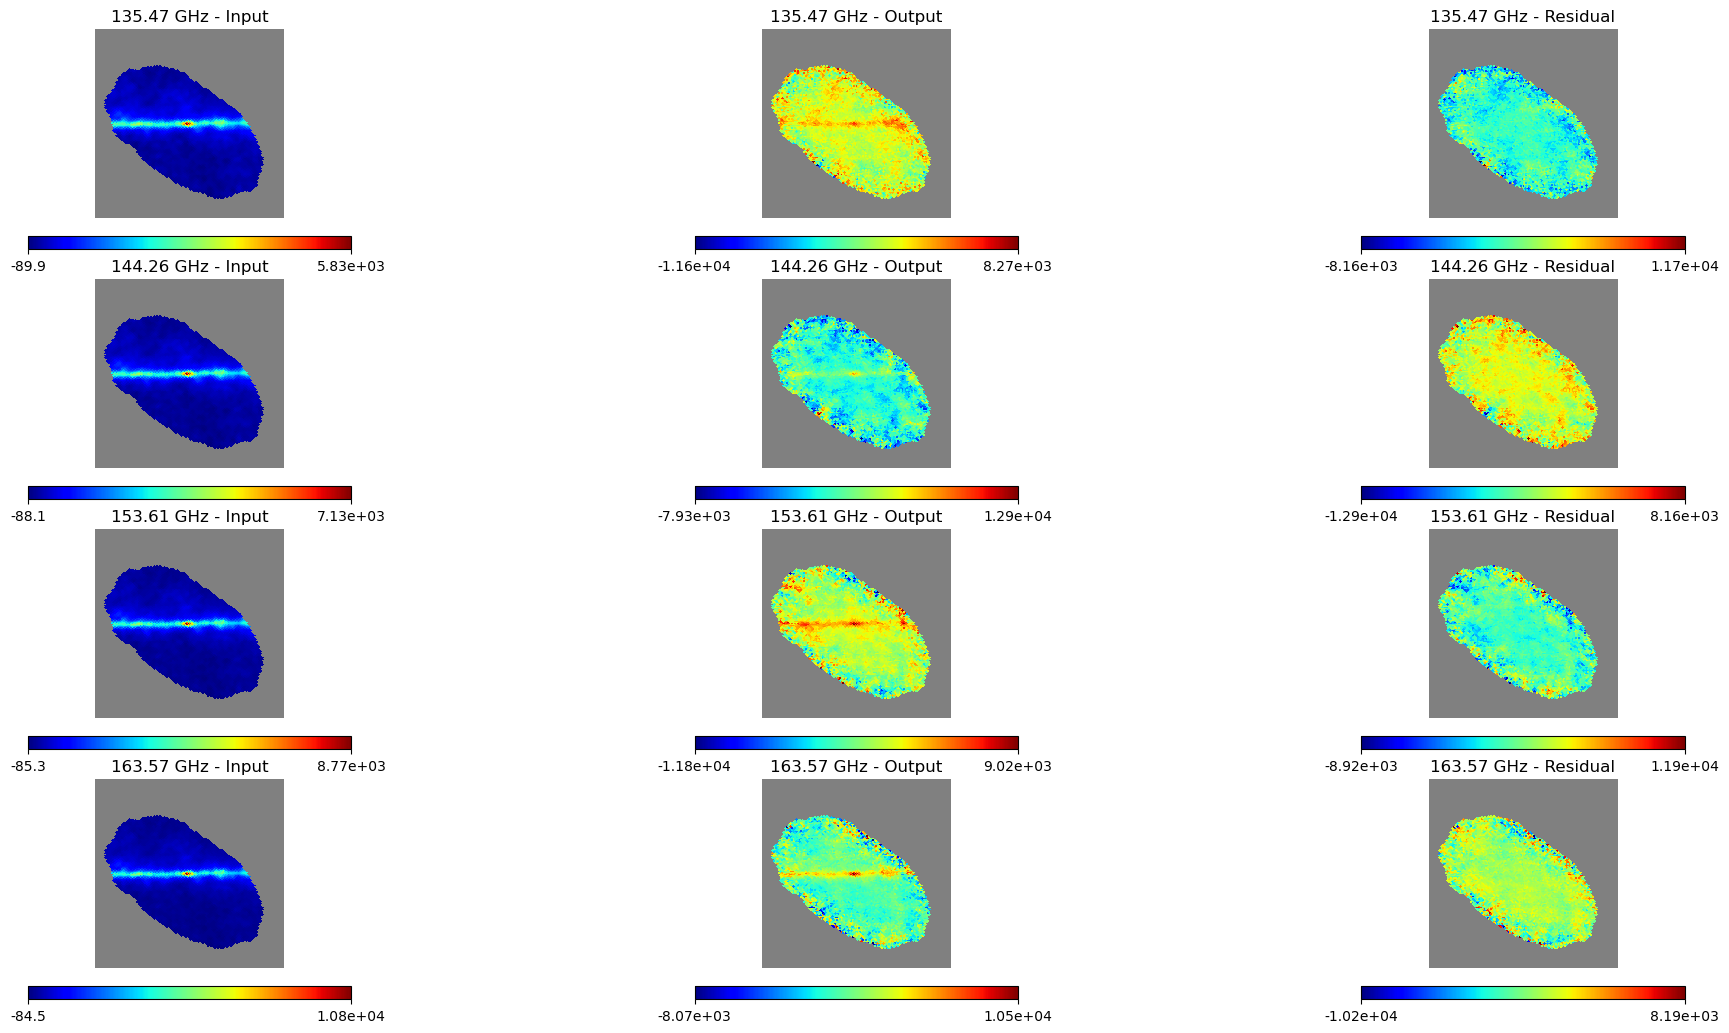

In [14]:
for i in range(len(datafiles)):
    plt.figure(figsize=(20, 10))
    k = 0
    for inu in range(Nrec):
        hp.gnomview((maps_input_freq[i, inu, :]), rot=center,
                            reso=15,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - Input",  
                            cmap="jet",
                            # min = - n * sigma_input[inu],
                            # max = n * sigma_input[inu],
                            sub=(Nrec, 3, k + 1))
        
        hp.gnomview((maps_rec_freq[i, inu, :]), rot=center,
                            reso=15,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - Output",
                            cmap="jet",
                            # min = - n * sigma_rec[inu],
                            # max = n * sigma_rec[inu],
                            sub=(Nrec, 3, k + 2))
        
        hp.gnomview(maps_res_freq[i, inu, :], rot=center,
                            reso=15,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - Residual",
                            cmap="jet",
                            # min = - n * sigma_res[inu],
                            # max = n * sigma_res[inu],
                            sub=(Nrec, 3, k + 3))
        k += 3

In [15]:
def select_top_pixels_by_snr(maps_input_freq, maps_res_freq, coverage, seenpix, top_k=10, nbins=20, agg="min", verbose=False):
    """
    Select the top pixels with the highest SNR that are consistent across all months
    and all frequencies, using the SNR estimated by snr_from_coverage_bins.

    Inputs:
        maps_input_freq : np.ndarray
            Input maps, shape (n_months, n_freqs, npix).
        maps_res_freq : np.ndarray
            Residual maps, shape (n_months, n_freqs, npix).
        coverage : np.ndarray
            shape (n_months, npix)
        seenpix : np.ndarray (bool)
            mask of observed pixels, shape (n_months, npix).
        top_k : int
            Number of pixels to select.
        nbins : int
            Number of coverage bins for SNR estimation.
        agg : str
            Aggregation across months and frequencies: "min", "median", or "mean".
        verbose : bool
            If True, print diagnostics for selected pixels.

    Outputs:
        top_idx : np.ndarray
            Indices of selected pixels, shape (top_k,).
        score : np.ndarray
            Aggregated SNR score per pixel, shape (npix,).
        snr_all : np.ndarray
            Full SNR cube, shape (n_months, n_freqs, npix).
    """
    
    n_months, n_freqs, npix = maps_input_freq.shape

    # Compute SNR for every month and frequency
    snr_all = np.full((n_months, n_freqs, npix), np.nan, dtype=float)
    sigma_all = np.full((n_months, n_freqs, npix), np.nan, dtype=float)
    for m in range(n_months):
        for f in range(n_freqs):
            snr, sigma, _, _ = snr_from_coverage_bins(maps_input_freq[m, f], maps_res_freq[m, f], 
                                            coverage[m], seenpix[m], nbins=nbins, plot=False, verbose=False)
            snr_all[m, f] = snr
            sigma_all[m, f] = sigma

    # Pixel must be seen in all months to be valid
    seen_all_months = np.all(seenpix, axis=0)

    # Aggregate SNR across months and frequencies
    if agg == "min":
        score = np.nanmin(snr_all, axis=(0, 1))
    elif agg == "median":
        score = np.nanmedian(snr_all, axis=(0, 1))
    elif agg == "mean":
        score = np.nanmean(snr_all, axis=(0, 1))
    else:
        raise ValueError("agg must be 'min', 'median' or 'mean'")

    # Exclude invalid pixels
    score[~seen_all_months] = -np.inf

    # Select top_k pixels by aggregated score
    top_idx = np.argpartition(score, -top_k)[-top_k:]
    top_idx = top_idx[np.argsort(score[top_idx])[::-1]]

    if verbose:
        # Print the minimum SNR (over months and freqs) for each selected pixel
        min_snr_selected = np.min(snr_all[:, :, top_idx], axis=(0, 1))
        print("Minimum SNR across months/frequencies for selected pixels:")
        for p, v in zip(top_idx, min_snr_selected):
            print(f"pix {p}: min SNR = {v:.3f}")

    return top_idx, score, snr_all, sigma_all
    

def mark_pixels_on_maps(maps_rec_freq, pix_idx, freqs, month_idx=0, center=(0,0)):
    """
    Plot input and reconstructed maps and mark selected pixels.

    Inputs:
        maps_input_freq : np.ndarray
            Input maps, shape (n_months, n_freqs, npix).
        maps_rec_freq : np.ndarray
            Reconstructed maps, shape (n_months, n_freqs, npix).
        pix_idx : array-like
            Pixel indices to highlight.
        month_idx : int
            Month index to plot.
        freq_idx : int
            Frequency index to plot.
        center : list
            center of the map.
    """
    pix_idx = np.asarray(pix_idx)

    # Pixel coordinate
    theta, phi = hp.pix2ang(128, pix_idx) 
   
    fig = plt.figure(figsize=(12, 5))

    for inu in range(len(freqs)):
        hp.gnomview((maps_rec_freq[month_idx, inu, :]), rot=center, reso=15,
                        notext=True, title=f"{nus[inu].round(2)} GHz",
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        sub = (1,4,inu+1),
                        )
   
        hp.projscatter(theta, phi, marker="*", s=20, c="black")

    plt.show()


def plot_sed(maps_input_freq, maps_rec_freq, sigma_all, freqs, pix_idx, months_idx):
    """
    Plot the Spectral Energy Distribution (SED) for selected pixels,
    comparing input and reconstructed maps.

    Inputs:
        maps_input_freq : np.ndarray
            Input maps, shape (n_months, n_freqs, npix).
        maps_rec_freq : np.ndarray
            Reconstructed maps, shape (n_months, n_freqs, npix).
        freqs : np.ndarray
            Frequency array, shape (n_freqs,).
        pix_idx : array-like
            Selected pixel indices.
        month_idx : array of int 
            Select number of months of observation.
    """
    ncols = 2
    nrows = int(np.ceil(len(pix_idx) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*7), sharex=True)

    axes = np.array(axes).ravel()
    for i, p in enumerate(pix_idx):
        ax = axes[i]
        ax.plot(freqs, maps_input_freq[0, :, p], "o--", label="Input SED")
        for m in months_idx:
            ax.errorbar(freqs, maps_rec_freq[m, :, p], yerr=sigma_all[m, :, p], fmt="s-", label=f"Reconstructed SED {m*2+2} months")
        ax.set_ylabel(r'$I_{\nu} \ \ [\mu \mathrm{K_{CMB}}]$')
        ax.set_title(f"pixel index {p}")
        ax.grid(True, alpha=0.3)
        ax.legend()


    axes[-1].set_xlabel(r'$\nu \ $ [GHz]')
    axes[-2].set_xlabel(r'$\nu \ $ [GHz]')
    fig.suptitle(f"Spectral energy distribution", y=1.02)
    plt.tight_layout()
    plt.show()


In [ ]:
freqs = nus[:4]
npix = 100
pix_idx, score, snr_all, sigma_all = select_top_pixels_by_snr(maps_input_freq, maps_res_freq, coverage=coverage, seenpix=seenpix, top_k=100, nbins=20, agg="min", verbose=False)

/tmp/ipykernel_7812/2953338365.py:50: RuntimeWarning: All-NaN slice encountered
  score = np.nanmin(snr_all, axis=(0, 1))


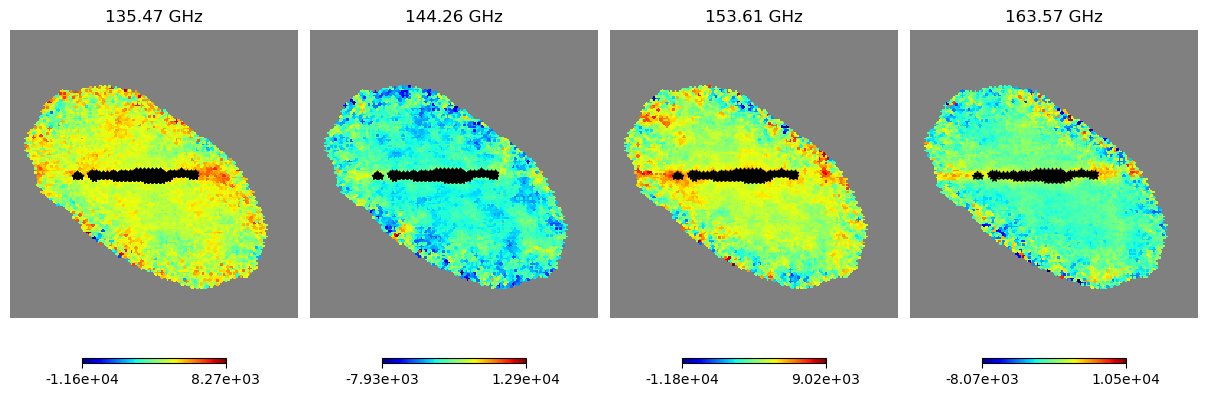

In [41]:
mark_pixels_on_maps(maps_rec_freq, pix_idx, freqs=freqs, month_idx=5, center=center)

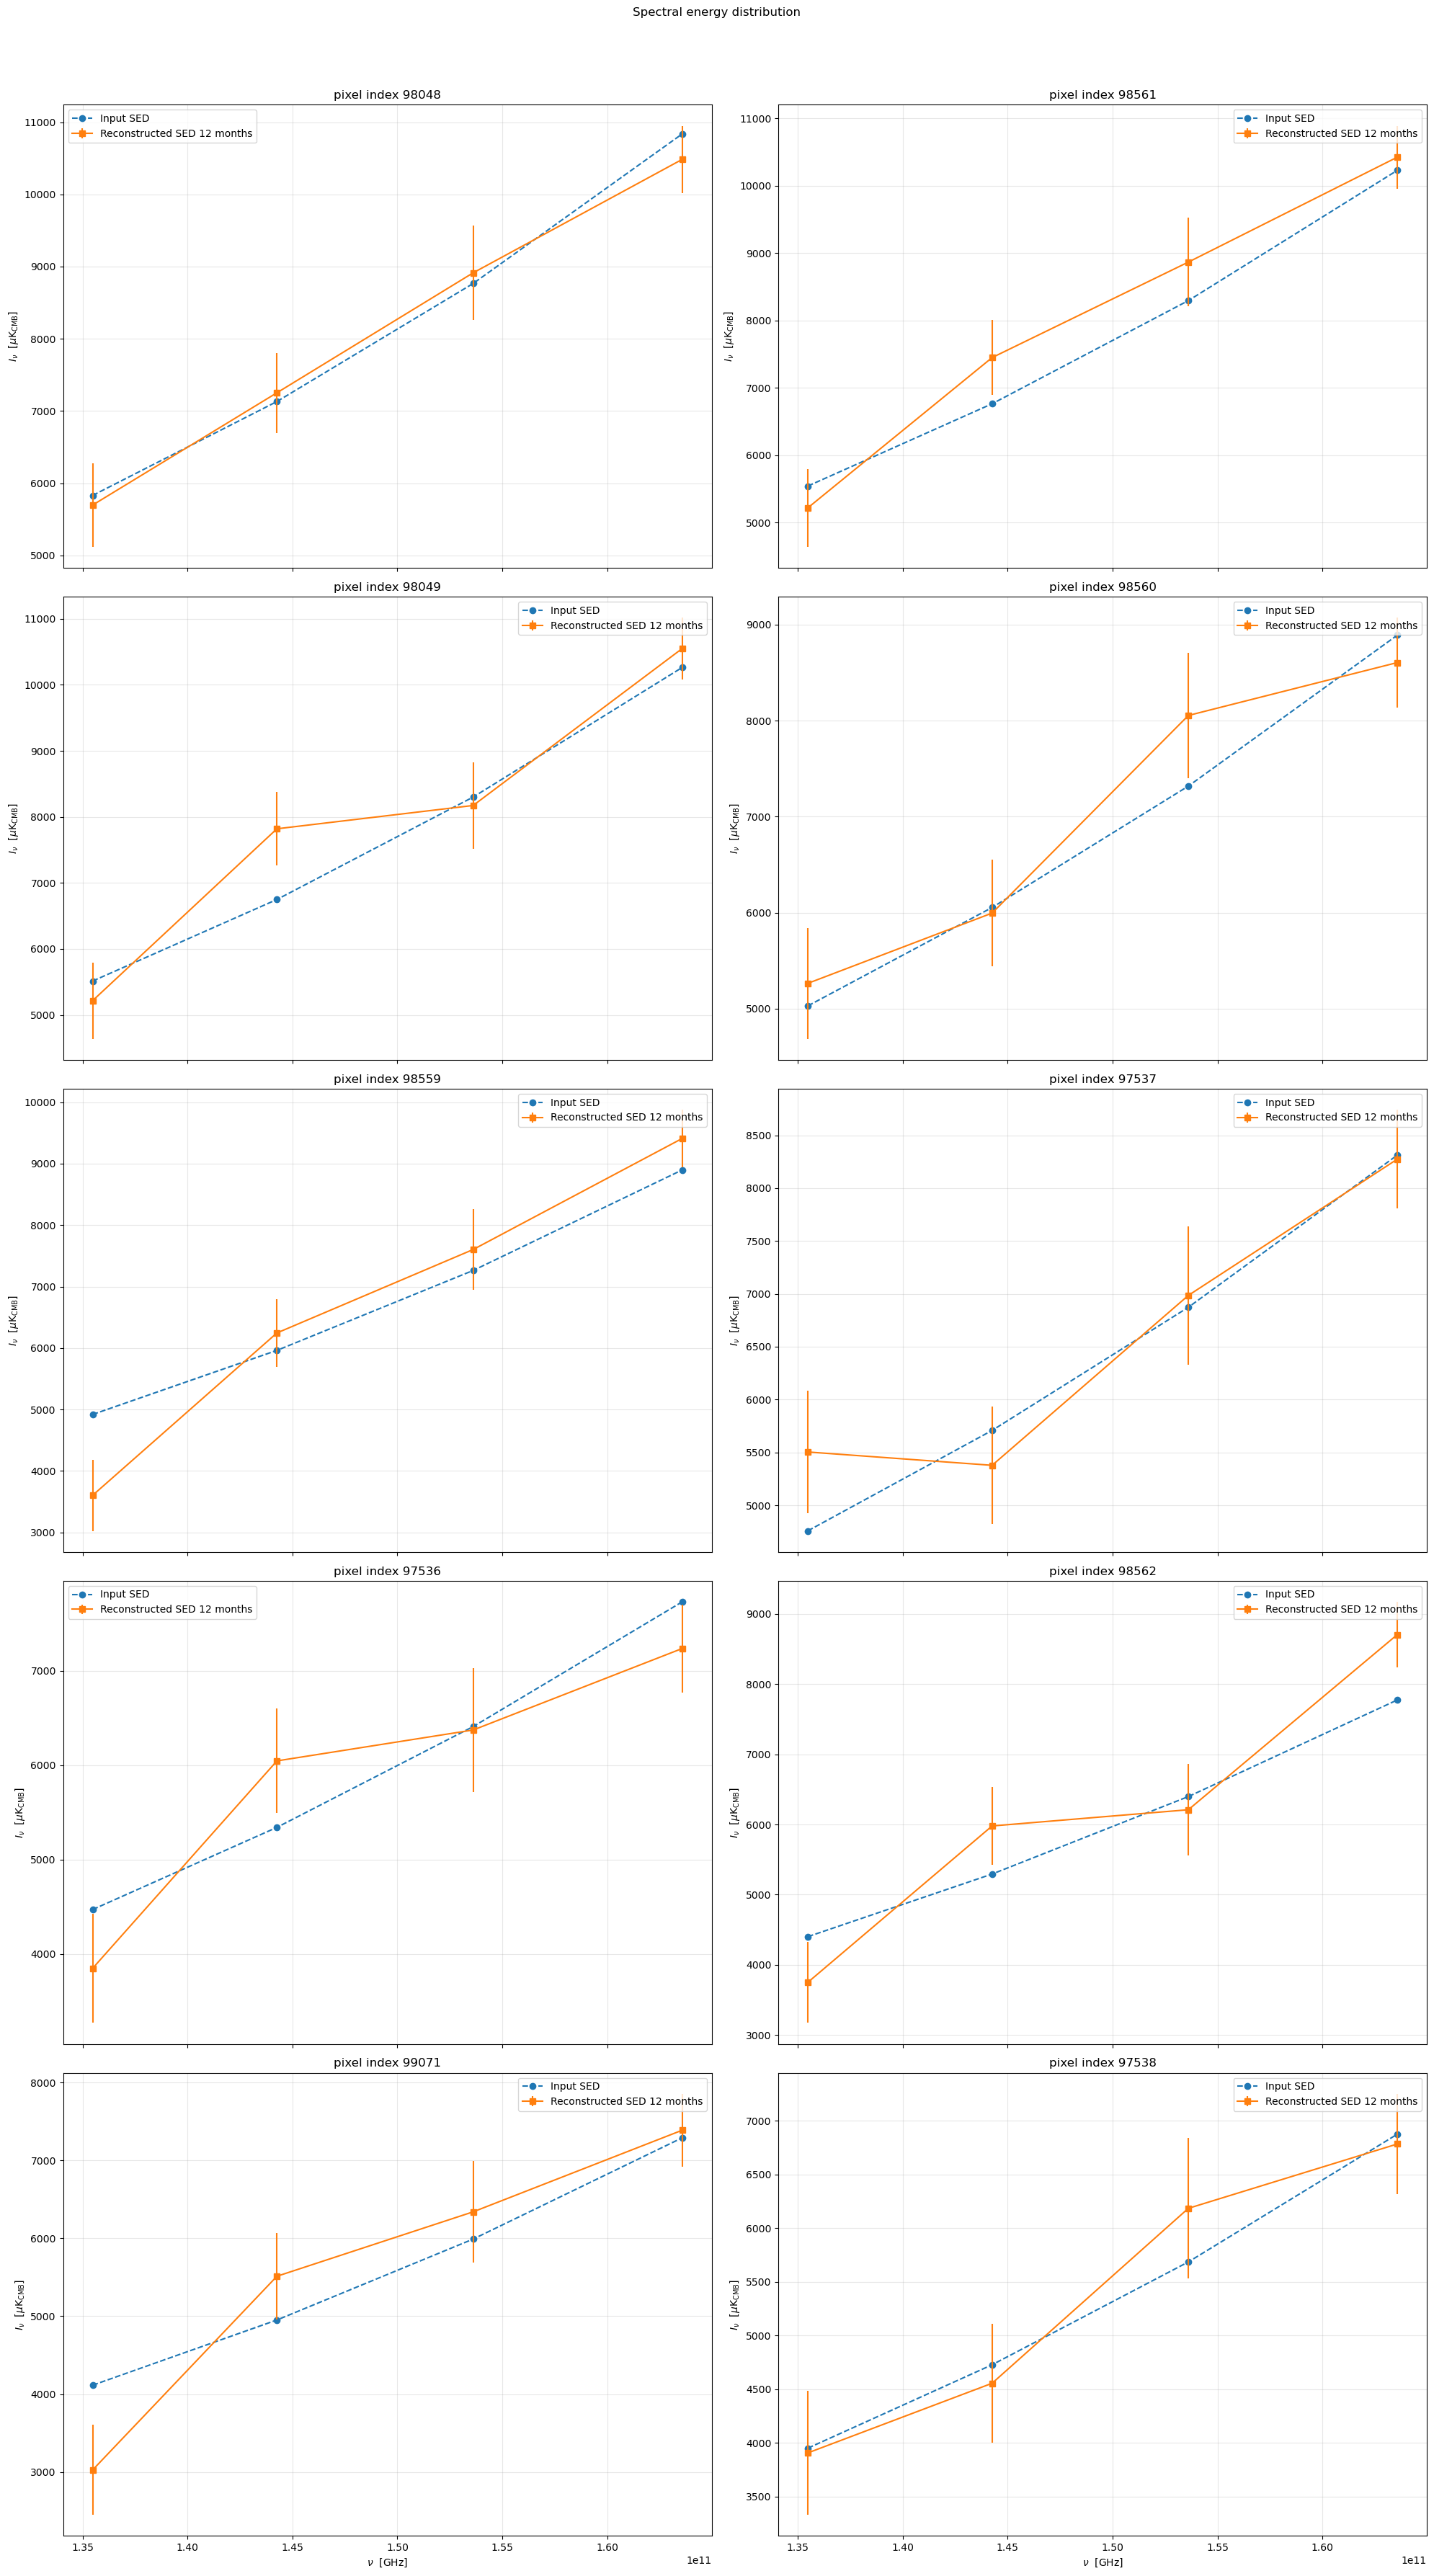

In [109]:
plot_sed(maps_input_freq, maps_rec_freq, sigma_all, freqs, pix_idx[0:10], months_idx=[5])

In [ ]:
freqs = nus[:4]
n_pix = 100
pix_idx, score, snr_all, sigma_all = select_top_pixels_by_snr(maps_input_freq, maps_res_freq, coverage=coverage, seenpix=seenpix, top_k=n_pix, nbins=20, agg="min", verbose=False)\

/tmp/ipykernel_7052/2953338365.py:50: RuntimeWarning: All-NaN slice encountered
  score = np.nanmin(snr_all, axis=(0, 1))


Verifica CMB (deve essere costante tra frequenze):
[-118.1153333 -118.1153333 -118.1153333 -118.1153333]

Pixel fittati : 100 / 100
β mediano     : 1.7525
β medio       : 1.7450
σ(β)          : 0.1025
Atteso (d0)   : 1.54


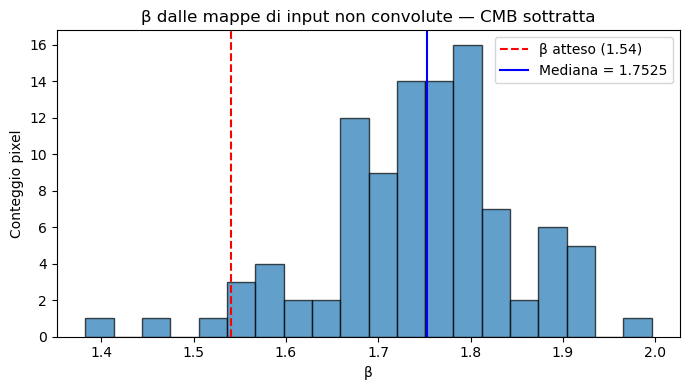

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pysm3
import pysm3.units as u

# ── Costanti fisiche ───────────────────────────────────────────────────────────
h   = 6.62607015e-34
k_B = 1.380649e-23
c   = 2.99792458e8

T_CMB  = 2.725
T_dust = 20.0

freqs = np.array([135.47199087, 144.25657956, 153.61079891, 163.57158621]) * 1e9

def B_nu(nu, T):
    x = h * nu / (k_B * T)
    return (2 * h * nu**3 / c**2) / (np.exp(x) - 1)

def dB_dT(nu, T):
    x = h * nu / (k_B * T)
    return (2 * h**2 * nu**4) / (c**2 * k_B * T**2) * np.exp(x) / (np.exp(x) - 1)**2

def model_dustonly(nu, A, beta):
    nu_GHz = nu / 1e9
    t = nu_GHz**beta * B_nu(nu, T_dust) / dB_dT(nu, T_CMB) * 1e6
    return A * t

# ── Genera mappa CMB con il seed corretto ──────────────────────────────────────
SEED  = 1   # sostituisci con il seed usato nelle simulazioni
nside = 128   # adatta se necessario

np.random.seed(SEED)
sky_cmb  = pysm3.Sky(nside=nside, preset_strings=["c1"], output_unit="uK_CMB")

cmb_maps = []
for f_GHz in freqs / 1e9:
    m       = sky_cmb.get_emission(f_GHz * u.GHz)
    m_uKcmb = m.to(u.uK_CMB, equivalencies=u.cmb_equivalencies(f_GHz * u.GHz))
    cmb_maps.append(m_uKcmb[0].value)
cmb_maps = np.array(cmb_maps)   # shape (4, npix)

# Verifica che la CMB sia piatta tra frequenze
print("Verifica CMB (deve essere costante tra frequenze):")
print(cmb_maps[:, pix_idx[0]])

# ── Fit pixel per pixel sulle mappe non convolute ─────────────────────────────
# Sostituisci maps_input_freq_nobeam con il nome corretto della tua variabile
n_pix    = len(pix_idx)
beta_fit = np.zeros(n_pix)

for i in range(n_pix):
    pix  = pix_idx[i]
    data = maps_input_nobeam_freq[-1, :, pix] - cmb_maps[:, pix]

    t0     = (freqs[0]/1e9)**1.54 * B_nu(freqs[0], T_dust) / dB_dT(freqs[0], T_CMB) * 1e6
    A_init = data[0] / t0

    try:
        popt, _ = curve_fit(model_dustonly, freqs, data,
                            p0=[A_init, 1.54],
                            bounds=([0, 0.5], [np.inf, 3.0]))
        beta_fit[i] = popt[1]
    except RuntimeError:
        beta_fit[i] = np.nan

# ── Statistiche ────────────────────────────────────────────────────────────────
valid = np.isfinite(beta_fit)
print(f"\nPixel fittati : {valid.sum()} / {n_pix}")
print(f"β mediano     : {np.nanmedian(beta_fit):.4f}")
print(f"β medio       : {np.nanmean(beta_fit):.4f}")
print(f"σ(β)          : {np.nanstd(beta_fit):.4f}")
print(f"Atteso (d0)   : 1.54")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.hist(beta_fit[valid], bins=20, edgecolor='k', alpha=0.7)
plt.axvline(1.54, color='r', linestyle='--', label='β atteso (1.54)')
plt.axvline(np.nanmedian(beta_fit), color='b', linestyle='-',
            label=f'Mediana = {np.nanmedian(beta_fit):.4f}')
plt.xlabel('β')
plt.ylabel('Conteggio pixel')
plt.title('β dalle mappe di input non convolute — CMB sottratta')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
print("Verifica shape spettrale dopo sottrazione CMB:")
print(f"{'Pixel':<10} | {'135 GHz':>10} {'144 GHz':>10} {'154 GHz':>10} {'164 GHz':>10} | {'Ratio 144/135':>14} {'Ratio atteso':>13}")

ratio_atteso = (freqs[1]/freqs[0])**1.54 * B_nu(freqs[1], T_dust)/B_nu(freqs[0], T_dust) * dB_dT(freqs[0], T_CMB)/dB_dT(freqs[1], T_CMB)

for k in range(5):
    pix  = pix_idx[k]
    data = maps_input_nobeam_freq[-1, :, pix] - cmb_maps[:, pix]
    print(f"{pix:<10} | {data[0]:>10.1f} {data[1]:>10.1f} {data[2]:>10.1f} {data[3]:>10.1f} | {data[1]/data[0]:>14.4f} {ratio_atteso:>13.4f}")

# Verifica anche che la CMB sottratta sia quella giusta
print("\nControllo: valore CMB vs segnale polvere atteso")
for k in range(3):
    pix      = pix_idx[k]
    cmb_val  = cmb_maps[0, pix]
    tot_val  = maps_input_nobeam_freq[-1, 0, pix]
    dust_val = tot_val - cmb_val
    print(f"pixel {pix}: totale={tot_val:.1f}, CMB={cmb_val:.1f}, polvere={dust_val:.1f}, rapporto CMB/polvere={cmb_val/dust_val:.3f}")

Verifica shape spettrale dopo sottrazione CMB:
Pixel      |    135 GHz    144 GHz    154 GHz    164 GHz |  Ratio 144/135  Ratio atteso
98048      |    11683.4    13698.7    16168.6    19224.7 |         1.1725        1.1543
98561      |     8884.6    10420.9    12303.2    14631.3 |         1.1729        1.1543
98049      |    10475.1    12279.7    14489.6    17221.2 |         1.1723        1.1543
98560      |     5662.7     6610.3     7771.1     9206.5 |         1.1673        1.1543
98559      |     8836.4    10355.7    12216.7    14517.8 |         1.1719        1.1543

Controllo: valore CMB vs segnale polvere atteso
pixel 98048: totale=11565.3, CMB=-118.1, polvere=11683.4, rapporto CMB/polvere=-0.010
pixel 98561: totale=8927.2, CMB=42.6, polvere=8884.6, rapporto CMB/polvere=0.005
pixel 98049: totale=10470.1, CMB=-5.0, polvere=10475.1, rapporto CMB/polvere=-0.000


Pixel fittati : 100 / 100
β mediano     : 1.7470
β medio       : 1.7527
σ(β)          : 0.0376
Atteso (d0)   : 1.54


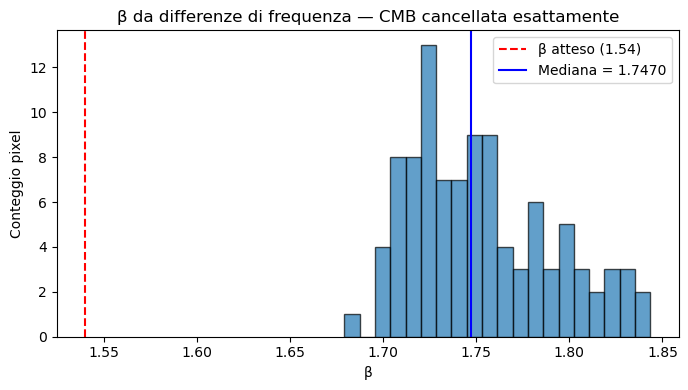

In [36]:
def model_diff(nu_pairs, A, beta):
    """Differenze del modello MBB tra coppie di frequenze."""
    result = []
    for nu1, nu2 in nu_pairs:
        t1 = (nu1/1e9)**beta * B_nu(nu1, T_dust) / dB_dT(nu1, T_CMB) * 1e6
        t2 = (nu2/1e9)**beta * B_nu(nu2, T_dust) / dB_dT(nu2, T_CMB) * 1e6
        result.append(A * (t2 - t1))
    return np.array(result)

# Coppie di frequenze: (ν1, ν2) con ν2 > ν1
nu_pairs = [
    (freqs[0], freqs[1]),
    (freqs[0], freqs[2]),
    (freqs[0], freqs[3]),
]

beta_fit = np.zeros(n_pix)

for i in range(n_pix):
    pix  = pix_idx[i]
    data = maps_input_nobeam_freq[-1, :, pix]

    # Differenze osservate
    data_diff = np.array([
        data[1] - data[0],
        data[2] - data[0],
        data[3] - data[0],
    ])

    # Stima A iniziale
    t0_diff = model_diff(nu_pairs, 1.0, 1.54)
    A_init  = data_diff[0] / t0_diff[0] if t0_diff[0] != 0 else 1.0

    try:
        popt, _ = curve_fit(
            lambda x, A, beta: model_diff(x, A, beta),
            nu_pairs, data_diff,
            p0=[A_init, 1.54],
            bounds=([0, 0.5], [np.inf, 3.0])
        )
        beta_fit[i] = popt[1]
    except RuntimeError:
        beta_fit[i] = np.nan

valid = np.isfinite(beta_fit)
print(f"Pixel fittati : {valid.sum()} / {n_pix}")
print(f"β mediano     : {np.nanmedian(beta_fit):.4f}")
print(f"β medio       : {np.nanmean(beta_fit):.4f}")
print(f"σ(β)          : {np.nanstd(beta_fit):.4f}")
print(f"Atteso (d0)   : 1.54")

plt.figure(figsize=(7, 4))
plt.hist(beta_fit[valid], bins=20, edgecolor='k', alpha=0.7)
plt.axvline(1.54, color='r', linestyle='--', label='β atteso (1.54)')
plt.axvline(np.nanmedian(beta_fit[valid]), color='b', linestyle='-',
            label=f'Mediana = {np.nanmedian(beta_fit[valid]):.4f}')
plt.xlabel('β'); plt.ylabel('Conteggio pixel')
plt.title('β da differenze di frequenza — CMB cancellata esattamente')
plt.legend(); plt.tight_layout(); plt.show()

In [37]:
# Genera mappe di sola polvere d0 con PySM
sky_dust = pysm3.Sky(nside=nside, preset_strings=["d0"])
dust_maps_pysm = []
for f_GHz in freqs / 1e9:
    m = sky_dust.get_emission(f_GHz * u.GHz)
    m_uKcmb = m.to(u.uK_CMB, equivalencies=u.cmb_equivalencies(f_GHz * u.GHz))
    dust_maps_pysm.append(m_uKcmb[0].value)
dust_maps_pysm = np.array(dust_maps_pysm)

# Confronta shape spettrale PySM vs modello teorico su un pixel
pix = pix_idx[0]
data_pysm = dust_maps_pysm[:, pix]

# Shape osservata da PySM
shape_pysm = data_pysm / data_pysm[0]

# Shape attesa dal modello teorico
t = lambda nu, b: (nu/1e9)**b * B_nu(nu, T_dust) / dB_dT(nu, T_CMB) * 1e6
shape_model = t(freqs, 1.54) / t(freqs[0], 1.54)

print(f"{'Freq [GHz]':>12} | {'PySM':>10} | {'Modello β=1.54':>15} | {'Differenza':>10}")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f}   | {shape_pysm[f]:>10.6f} | {shape_model[f]:>15.6f} | {shape_pysm[f]-shape_model[f]:>10.6f}")

  Freq [GHz] |       PySM |  Modello β=1.54 | Differenza
    135.47   |   1.000000 |        1.000000 |   0.000000
    144.26   |   1.154311 |        1.154334 |  -0.000022
    153.61   |   1.340792 |        1.340847 |  -0.000055
    163.57   |   1.568275 |        1.568377 |  -0.000102


In [39]:
pix = pix_idx[0]

# Shape dalle mappe di simulazione (dopo sottrazione CMB)
data_sim  = maps_input_nobeam_freq[-1, :, pix] - cmb_maps[:, pix]
shape_sim = data_sim / data_sim[0]

# Shape da PySM polvere pura
shape_pysm = dust_maps_pysm[:, pix] / dust_maps_pysm[0, pix]

# Shape modello teorico
t          = lambda nu, b: (nu/1e9)**b * B_nu(nu, T_dust) / dB_dT(nu, T_CMB) * 1e6
shape_model = t(freqs, 1.54) / t(freqs[0], 1.54)

print(f"{'Freq [GHz]':>12} | {'Sim-CMB':>10} | {'PySM dust':>10} | {'Modello':>10}")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f}   | {shape_sim[f]:>10.6f} | {shape_pysm[f]:>10.6f} | {shape_model[f]:>10.6f}")

print(f"\nValore assoluto sim (dopo CMB): {data_sim}")
print(f"Valore assoluto PySM dust    : {dust_maps_pysm[:, pix]}")

  Freq [GHz] |    Sim-CMB |  PySM dust |    Modello
    135.47   |   1.000000 |   1.000000 |   1.000000
    144.26   |   1.172488 |   1.154311 |   1.154334
    153.61   |   1.383895 |   1.340792 |   1.340847
    163.57   |   1.645464 |   1.568275 |   1.568377

Valore assoluto sim (dopo CMB): [11683.43955205 13698.68824996 16168.64788538 19224.67653121]
Valore assoluto PySM dust    : [27229.84147862 31431.70828667 36509.54645842 42703.89043299]


Calcolo chi2 sulle mappe di input...

Pixel usati : 100
β best      : 1.7828
1σ range    : [1.7803, 1.7858]
σ(β)        : 0.0028
Atteso (d0) : 1.54


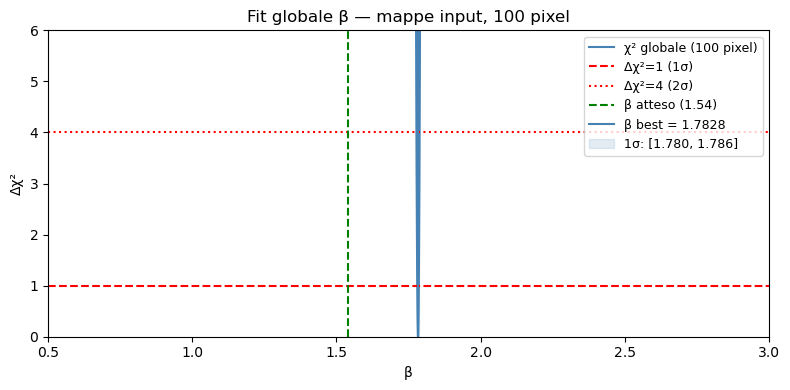

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ── Costanti fisiche ───────────────────────────────────────────────────────────
h   = 6.62607015e-34
k_B = 1.380649e-23
c   = 2.99792458e8

T_CMB  = 2.725
T_dust = 20.0

freqs = np.array([135.47199087, 144.25657956, 153.61079891, 163.57158621]) * 1e9

def B_nu(nu, T):
    x = h * nu / (k_B * T)
    return (2 * h * nu**3 / c**2) / (np.exp(x) - 1)

def dB_dT(nu, T):
    x = h * nu / (k_B * T)
    return (2 * h**2 * nu**4) / (c**2 * k_B * T**2) * np.exp(x) / (np.exp(x) - 1)**2

def dust_template(nu, beta):
    t = (nu/1e9)**beta * B_nu(nu, T_dust) / dB_dT(nu, T_CMB) * 1e6
    return t / np.linalg.norm(t)

# ── Prepara dati di input ──────────────────────────────────────────────────────
n_pix      = len(pix_idx)
beta_grid  = np.linspace(0.5, 3.0, 5000)
data_input = np.array([maps_input_nobeam_freq[-1, :, pix_idx[i]] for i in range(n_pix)])

# ── Chi2 globale OLS (nessun peso, mappe senza rumore) ────────────────────────
def chi2_global_input(beta):
    g = dust_template(freqs, beta)
    G = np.column_stack([g, np.ones(4)])
    chi2_tot = 0.0
    for i in range(n_pix):
        params, _, _, _ = np.linalg.lstsq(G, data_input[i], rcond=None)
        residuals = data_input[i] - G @ params
        chi2_tot += np.dot(residuals, residuals)
    return chi2_tot

# ── Scansione ─────────────────────────────────────────────────────────────────
print("Calcolo chi2 sulle mappe di input...")
chi2_vals  = np.array([chi2_global_input(b) for b in beta_grid])
chi2_vals -= chi2_vals.min()

j_min     = np.argmin(chi2_vals)
beta_best = beta_grid[j_min]

left  = chi2_vals[:j_min]
right = chi2_vals[j_min:]
try:
    j_left  = j_min - np.where(left[::-1] >= 1)[0][0]
    j_right = j_min + np.where(right >= 1)[0][0]
    beta_lo = beta_grid[j_left]
    beta_hi = beta_grid[j_right]
    print(f"\nPixel usati : {n_pix}")
    print(f"β best      : {beta_best:.4f}")
    print(f"1σ range    : [{beta_lo:.4f}, {beta_hi:.4f}]")
    print(f"σ(β)        : {(beta_hi - beta_lo)/2:.4f}")
    print(f"Atteso (d0) : 1.54")
except IndexError:
    print(f"\nβ best      : {beta_best:.4f}")
    print("Δχ²=1 non raggiunto")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(beta_grid, chi2_vals, color='steelblue', label=f'χ² globale ({n_pix} pixel)')
plt.axhline(1.0, color='r', linestyle='--', label='Δχ²=1 (1σ)')
plt.axhline(4.0, color='r', linestyle=':',  label='Δχ²=4 (2σ)')
plt.axvline(1.54,      color='g',        linestyle='--', label='β atteso (1.54)')
plt.axvline(beta_best, color='steelblue', linestyle='-', linewidth=1.5,
            label=f'β best = {beta_best:.4f}')
if 'beta_lo' in dir():
    plt.axvspan(beta_lo, beta_hi, alpha=0.15, color='steelblue',
                label=f'1σ: [{beta_lo:.3f}, {beta_hi:.3f}]')
plt.xlabel('β'); plt.ylabel('Δχ²')
plt.title(f'Fit globale β — mappe input, {n_pix} pixel')
plt.ylim(0, 6); plt.xlim(0.5, 3.0)
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

In [42]:
# Confronto diretto tra mappe di simulazione e PySM su stesso pixel
pix = pix_idx[0]

data_sim  = maps_input_nobeam_freq[-1, :, pix]
data_pysm = dust_maps_pysm[:, pix] + cmb_maps[:, pix]   # polvere + CMB da PySM

print(f"{'Freq [GHz]':>12} | {'Sim':>12} | {'PySM dust+CMB':>15} | {'Rapporto':>10}")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f}   | {data_sim[f]:>12.2f} | {data_pysm[f]:>15.2f} | {data_sim[f]/data_pysm[f]:>10.4f}")

print(f"\nShape normalizzata:")
print(f"{'Freq [GHz]':>12} | {'Sim':>10} | {'PySM dust+CMB':>15}")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f}   | {data_sim[f]/data_sim[0]:>10.6f} | {data_pysm[f]/data_pysm[0]:>15.6f}")

  Freq [GHz] |          Sim |   PySM dust+CMB |   Rapporto
    135.47   |     11565.32 |        27111.73 |     0.4266
    144.26   |     13580.57 |        31313.59 |     0.4337
    153.61   |     16050.53 |        36391.43 |     0.4411
    163.57   |     19106.56 |        42585.78 |     0.4487

Shape normalizzata:
  Freq [GHz] |        Sim |   PySM dust+CMB
    135.47   |   1.000000 |        1.000000
    144.26   |   1.174249 |        1.154983
    153.61   |   1.387815 |        1.342276
    163.57   |   1.652056 |        1.570751


In [44]:
# Rapporto osservato tra ultima e prima frequenza
pix = pix_idx[0]
data = maps_input_nobeam_freq[-1, :, pix]
ratio_obs = data[-1] / data[0]
print(f"Rapporto osservato S(163)/S(135) = {ratio_obs:.6f}")

# Rapporto atteso dal modello MBB per diversi beta
print(f"\nRapporto atteso per diversi β:")
for beta_test in [1.2, 1.3, 1.4, 1.54, 1.6, 1.7, 1.8, 1.9, 2.0]:
    t     = (freqs/1e9)**beta_test * B_nu(freqs, T_dust) / dB_dT(freqs, T_CMB) * 1e6
    ratio = t[-1] / t[0]
    match = " ← match" if abs(ratio - ratio_obs) < 0.01 else ""
    print(f"  β = {beta_test:.2f}  →  ratio = {ratio:.6f}{match}")

Rapporto osservato S(163)/S(135) = 1.652056

Rapporto atteso per diversi β:
  β = 1.20  →  ratio = 1.471020
  β = 1.30  →  ratio = 1.499010
  β = 1.40  →  ratio = 1.527532
  β = 1.54  →  ratio = 1.568377
  β = 1.60  →  ratio = 1.586215
  β = 1.70  →  ratio = 1.616396
  β = 1.80  →  ratio = 1.647152 ← match
  β = 1.90  →  ratio = 1.678493
  β = 2.00  →  ratio = 1.710430


In [45]:
# Quale valore di CMB spiegherebbe il rapporto osservato?
# S_obs(nu) = S_dust(nu) + CMB
# Ratio_dust = (S_obs(163) - CMB) / (S_obs(135) - CMB) = ratio_atteso(beta=1.54)

from scipy.optimize import brentq

ratio_target = 1.568377   # atteso per beta=1.54
S_163 = data[-1]
S_135 = data[0]

def equation(CMB):
    return (S_163 - CMB) / (S_135 - CMB) - ratio_target

# Cerca il valore di CMB che porta al ratio corretto
CMB_needed = brentq(equation, -50000, 10000)
print(f"CMB necessaria per β=1.54 : {CMB_needed:.2f} µK_CMB")
print(f"CMB che stiamo sottraendo : {cmb_maps[0, pix_idx[0]]:.2f} µK_CMB")
print(f"Differenza                : {CMB_needed - cmb_maps[0, pix_idx[0]]:.2f} µK_CMB")

CMB necessaria per β=1.54 : -1702.70 µK_CMB
CMB che stiamo sottraendo : -118.12 µK_CMB
Differenza                : -1584.58 µK_CMB


In [ ]:
from scipy.optimize import brentq

def ratio_model(beta):
    t = (freqs/1e9)**beta * B_nu(freqs, T_dust) / dB_dT(freqs, T_CMB) * 1e6
    return (t[2] - t[0]) / (t[1] - t[0])

beta_fit_ratio = np.zeros(n_pix)

for i in range(n_pix):
    data = maps_input_nobeam_freq[-1, :, pix_idx[i]]
    ratio_obs = (data[2] - data[0]) / (data[1] - data[0])
    try:
        beta_fit_ratio[i] = brentq(lambda b: ratio_model(b) - ratio_obs, 0.5, 3.0)
    except ValueError:
        beta_fit_ratio[i] = np.nan

valid = np.isfinite(beta_fit_ratio)
print(f"Pixel fittati : {valid.sum()} / {n_pix}")
print(f"bβ mediano     : {np.nanmedian(beta_fit_ratio):.4f}")
print(f"β medio       : {np.nanmean(beta_fit_ratio):.4f}")
print(f"σ(β)          : {np.nanstd(beta_fit_ratio):.4f}")
print(f"Atteso (d0)   : 1.54")

Pixel fittati : 100 / 100
β mediano     : 1.7449
β medio       : 1.7510
σ(β)          : 0.0377
Atteso (d0)   : 1.54


In [49]:
# Confronta direttamente le mappe di simulazione con PySM d0 puro
# senza CMB, senza nulla — solo il rapporto tra frequenze

pix = pix_idx[0]
data_sim  = maps_input_nobeam_freq[-1, :, pix]
data_pysm = dust_maps_pysm[:, pix]   # solo polvere d0

print("Rapporto S(nu)/S(135) — confronto diretto:")
print(f"{'Freq [GHz]':>12} | {'Sim':>10} | {'PySM d0':>10}")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f}   | {data_sim[f]/data_sim[0]:>10.6f} | {data_pysm[f]/data_pysm[0]:>10.6f}")

# Rapporto assoluto sim/pysm — deve essere costante se stessa componente
print(f"\nRapporto assoluto sim/pysm (deve essere costante se stessa polvere):")
for f in range(4):
    print(f"  {freqs[f]/1e9:>8.2f} GHz : {data_sim[f]/data_pysm[f]:.6f}")

Rapporto S(nu)/S(135) — confronto diretto:
  Freq [GHz] |        Sim |    PySM d0
    135.47   |   1.000000 |   1.000000
    144.26   |   1.174249 |   1.154311
    153.61   |   1.387815 |   1.340792
    163.57   |   1.652056 |   1.568275

Rapporto assoluto sim/pysm (deve essere costante se stessa polvere):
    135.47 GHz : 0.424730
    144.26 GHz : 0.432066
    153.61 GHz : 0.439626
    163.57 GHz : 0.447420


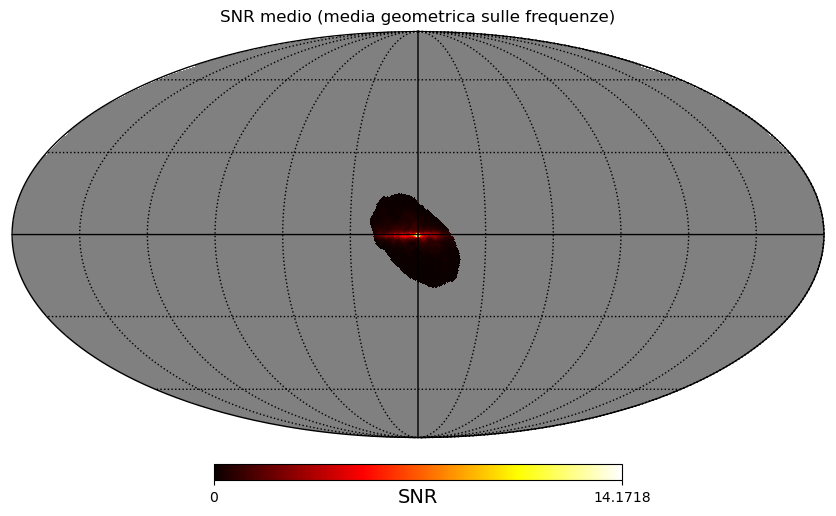

SNR mediano sulla regione osservata : 0.15
SNR massimo                         : 14.17
Pixel con SNR > 5                   : 49
Pixel con SNR > 10                  : 8


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

# ── Figura di merito per pixel ─────────────────────────────────────────────────
# Usa la media del SNR sulle 4 frequenze come proxy

snr_per_pixel = snr_all[-1, :, :]   # shape (n_freqs, n_pix) — adatta se necessario

# Media geometrica del SNR sulle frequenze (più robusta della media aritmetica)
snr_mean = np.exp(np.mean(np.log(np.clip(snr_per_pixel, 1e-10, None)), axis=0))

# ── Mappa healpy del SNR ───────────────────────────────────────────────────────
nside  = 128
n_pix_tot = hp.nside2npix(nside)
snr_map = np.full(n_pix_tot, hp.UNSEEN)
snr_map[seenpix[-1]] = snr_mean[seenpix[-1]]   # adatta seenpix se necessario

hp.mollview(snr_map, title="SNR medio (media geometrica sulle frequenze)",
            unit="SNR", cmap="hot", min=0)
hp.graticule()
plt.show()

# ── Statistiche per regione ────────────────────────────────────────────────────
print(f"SNR mediano sulla regione osservata : {np.nanmedian(snr_mean[seenpix[-1]]):.2f}")
print(f"SNR massimo                         : {np.nanmax(snr_mean[seenpix[-1]]):.2f}")
print(f"Pixel con SNR > 5                   : {np.sum(snr_mean[seenpix[-1]] > 5)}")
print(f"Pixel con SNR > 10                  : {np.sum(snr_mean[seenpix[-1]] > 10)}")

In [51]:
# ── Figura di merito per regione ───────────────────────────────────────────────
# Supponiamo di avere N regioni candidate, ciascuna descritta da un set di pixel

# Per ogni regione calcola:
# 1. SNR medio
# 2. Incertezza relativa media (sigma/signal)
# 3. Segnale di polvere medio

def figure_of_merit(pix_region):
    """
    Calcola la figura di merito per una regione definita da un array di pixel.
    """
    # SNR medio sulla regione
    snr_region = snr_mean[pix_region]
    snr_med    = np.nanmedian(snr_region)

    # Incertezza relativa media sulle frequenze
    sigma_region  = sigma_all[-1, :, pix_region]   # shape (n_freqs, n_pix_region)
    signal_region = maps_rec_freq[-1, :, pix_region]
    rel_err       = np.nanmedian(sigma_region / np.abs(signal_region))

    # Segnale di polvere medio (prima frequenza come proxy)
    dust_signal = np.nanmedian(maps_rec_freq[-1, 0, pix_region])

    # Figura di merito: alto SNR, bassa incertezza relativa
    fom = snr_med / rel_err

    return {
        "snr_median"   : snr_med,
        "rel_err"      : rel_err,
        "dust_signal"  : dust_signal,
        "fom"          : fom,
        "n_pix"        : len(pix_region)
    }

In [53]:
r = figure_of_merit(pix_idx)

In [54]:
    print(f"{r['n_pix']:>8} | {r['snr_median']:>8.2f} | {r['rel_err']:>8.4f} | {r['fom']:>10.2f}")

     100 |     4.98 |   0.1977 |      25.18


In [333]:
freqs = nus[:4]
n_pix = 20
pix_idx, score, snr_all, sigma_all = select_top_pixels_by_snr(maps_input_freq, maps_res_freq, coverage=coverage, seenpix=seenpix, top_k=n_pix, nbins=20, agg="min", verbose=False)

/tmp/ipykernel_7052/2953338365.py:50: RuntimeWarning: All-NaN slice encountered
  score = np.nanmin(snr_all, axis=(0, 1))


In [335]:
import numpy as np

H_PLANCK = 6.62607015e-34  # J·s
K_BOLTZ  = 1.380649e-23    # J/K
C_LIGHT  = 2.99792458e8    # m/s
T_CMB    = 2.72548         # K

def uKcmb_to_Jysr(mappa: np.ndarray, freq_GHz: float) -> np.ndarray:
    """
    Converte una mappa da μK_CMB a Jy/sr.

    In queste unità la polvere scala come I_ν ∝ ν^(β+2),
    perché si è rimossa la dipendenza frequenziale di dB/dT.

    Parameters
    ----------
    mappa    : array 1D in μK_CMB
    freq_GHz : frequenza centrale della banda [GHz]

    Returns
    -------
    array 1D in Jy/sr
    """
    nu   = freq_GHz * 1e9
    x    = H_PLANCK * nu / (K_BOLTZ * T_CMB)
    ex   = np.exp(x)
    fx   = (x**2 * ex) / (ex - 1.0)**2          # f(x) = x²eˣ/(eˣ-1)²
    dBdT = (2.0 * K_BOLTZ * nu**2 / C_LIGHT**2) * fx   # W/m²/Hz/sr/K

    return mappa * 1e-6 * dBdT / 1e-26  # Jy/sr

In [336]:
import numpy as np

def beta_and_error(
    I1: float | np.ndarray,
    I2: float | np.ndarray,
    sigma1: float | np.ndarray,
    sigma2: float | np.ndarray,
    freq1_GHz: float,
    freq2_GHz: float,
) -> tuple:
    """
    Stima β e il suo errore dal rapporto di intensità a due frequenze.

    Assume errori gaussiani indipendenti su I1 e I2.
    Le intensità devono essere in Jy/sr (o qualsiasi unità fisica
    in cui I ∝ ν^(β+2)) — NON in K_CMB.

    Parameters
    ----------
    I1, I2         : intensità alle due frequenze [stessa unità fisica]
    sigma1, sigma2 : errori associati
    freq1_GHz      : frequenza di I1 [GHz]
    freq2_GHz      : frequenza di I2 [GHz]

    Returns
    -------
    beta      : indice spettrale
    sigma_beta: errore propagato su beta
    """
    I1 = np.asarray(I1, dtype=float)
    I2 = np.asarray(I2, dtype=float)
    s1 = np.asarray(sigma1, dtype=float)
    s2 = np.asarray(sigma2, dtype=float)

    log_nu = np.log(freq1_GHz / freq2_GHz)   # costante, ≠ 0

    beta = np.log(I1 / I2) / log_nu - 2.0

    sigma_beta = np.sqrt((s1 / I1)**2 + (s2 / I2)**2) / np.abs(log_nu)

    return beta, sigma_beta

In [337]:
# converti tutto in Jy/sr
I1_in    = uKcmb_to_Jysr(maps_input_freq[-1,1,pix_idx], freqs[1])
I3_in    = uKcmb_to_Jysr(maps_input_freq[-1,3,pix_idx], freqs[3])
I1    = uKcmb_to_Jysr(maps_rec_freq[-1,1,pix_idx], freqs[1])
I3    = uKcmb_to_Jysr(maps_rec_freq[-1,3,pix_idx], freqs[3])
sI1   = uKcmb_to_Jysr(sigma_all[-1,1,pix_idx], freqs[1])
sI3   = uKcmb_to_Jysr(sigma_all[-1,3,pix_idx], freqs[3])

# stima β fisico
beta_rec, sigma_beta = beta_and_error(I3, I1, sI3, sI1, freqs[3], freqs[1])
beta_in, _ = beta_and_error(I3_in, I1_in, 0, 0, freqs[3], freqs[1])

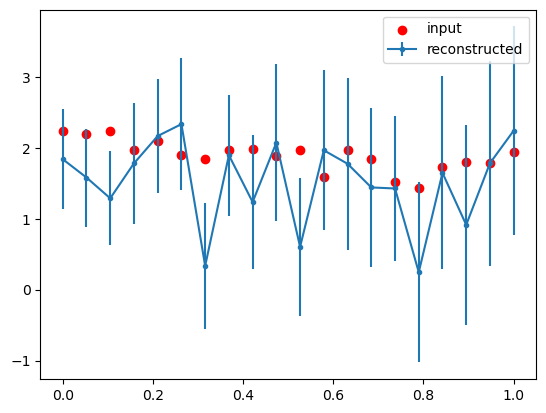

In [338]:
plt.scatter(np.linspace(0,1,n_pix), beta_in, c='red', label='input')
plt.errorbar(np.linspace(0,1,n_pix), beta_rec, yerr=sigma_beta, marker='.', label='reconstructed')
plt.legend()

In [339]:
I1_nobeam    = uKcmb_to_Jysr(maps_input_nobeam_freq[-1,1,pix_idx], freqs[1])
I3_nobeam    = uKcmb_to_Jysr(maps_input_nobeam_freq[-1,3,pix_idx], freqs[3])
beta_nobeam, _ = beta_and_error(I3_nobeam, I1_nobeam, 0, 0, freqs[3], freqs[1])

print('mean', np.mean(beta_nobeam))
print('median', np.median(beta_nobeam))
print('std', np.std(beta_nobeam))

mean 1.578458647620156
median 1.5877675588991627
std 0.04562045073610132


In [340]:
print('mean', np.mean(beta_in))
print('median', np.median(beta_in))
print('std', np.std(beta_in))

mean 1.8937213016993297
median 1.9207736390567396
std 0.2136033359750058


In [341]:
print('mean', np.mean(beta_rec))
print('median', np.median(beta_rec))
print('std', np.std(beta_rec))

mean 1.5282781011252606
median 1.710680666434729
std 0.5897631729119258


In [363]:
import numpy as np

def beta_linear_fit(
    intensities: np.ndarray,
    freqs_GHz: np.ndarray,
    sigmas = None,
) -> dict:
    """
    Stima β tramite fit lineare pesato di log(I) vs log(ν)
    su N frequenze (N ≥ 2).

    Le intensità devono essere in Jy/sr (o unità fisiche dove
    I ∝ ν^(β+2)) con i relativi errori nella stessa unità.

    Parameters
    ----------
    intensities : array (N,) o (N, n_pixel)
                  intensità alle N frequenze
    sigmas      : array (N,) o (N, n_pixel)
                  errori sulle intensità
    freqs_GHz   : array (N,)
                  frequenze in GHz

    Returns
    -------
    dict con:
        beta       : indice spettrale (scalare o array per pixel)
        sigma_beta : errore su beta
    """
    N = len(freqs_GHz)
   

    # ── log-space ─────────────────────────────────────────────────────────────
    x      = np.log(freqs_GHz)          # (N,)
    y      = np.log(intensities)        # (N,) o (N, n_pixel)

    # ── pesi ──────────────────────────────────────────────────────────────────
    if sigmas is not None:
        sigma_y = sigmas / intensities 
        w = 1.0 / sigma_y**2
    else:
        w = np.ones_like(y) 
    # ── somme per WLS  ────────────────────────────────────────────────────────
    # se y è 2D (N, n_pixel), le somme vanno sull'asse 0
    axis = 0

    S   = np.sum(w,       axis=axis)
    Sx  = np.sum(w * x[:, None] if y.ndim == 2 else w * x, axis=axis)
    Sy  = np.sum(w * y,   axis=axis)
    Sxx = np.sum(w * (x[:, None]**2 if y.ndim == 2 else x**2), axis=axis)
    Sxy = np.sum(w * (x[:, None] if y.ndim == 2 else x) * y, axis=axis)

    # ── soluzione WLS ─────────────────────────────────────────────────────────
    Delta     = S * Sxx - Sx**2
    slope     = (S * Sxy - Sx * Sy) / Delta     # = β + 2
    intercept = (Sxx * Sy - Sx * Sxy) / Delta

    beta       = slope - 2.0
    sigma_beta = np.sqrt(S / Delta)              # errore sulla pendenza

    return {
        "beta"       : beta,
        "sigma_beta" : sigma_beta,
    }

In [364]:
maps_jysr = np.zeros_like(maps_rec_freq[-1, :, :])  # shape: (n_freq, n_pixel)
maps_in_jysr = np.zeros_like(maps_input_freq[-1, :, :])  # shape: (n_freq, n_pixel)
sigma_maps_jysr = np.zeros_like(sigma_all[-1, :, :])  # shape: (n_freq, n_pixel)


for i, nu in enumerate(freqs):
    maps_jysr[i] = uKcmb_to_Jysr(maps_rec_freq[-1, i, :], nu)
    maps_in_jysr[i] = uKcmb_to_Jysr(maps_input_freq[-1, i, :], nu)
    sigma_maps_jysr[i] = uKcmb_to_Jysr(sigma_all[-1, i, :], nu)

In [365]:
result = beta_linear_fit(maps_jysr[:,pix_idx], freqs, sigma_maps_jysr[:,pix_idx])
result_in = beta_linear_fit(maps_in_jysr[:,pix_idx], freqs)

In [366]:
result

{'beta': array([2.04428299, 2.14583145, 2.06244305, 1.61165314, 2.96813173,
        1.44372165, 1.35766589, 2.71432835, 2.25504169, 1.91198316,
        1.22736097, 1.95866237, 1.94963173, 2.15732531, 2.28145535,
        1.0696259 , 1.74841653, 1.54588857, 1.96729705, 2.2574745 ]),
 'sigma_beta': array([0.49227889, 0.50812617, 0.49997946, 0.56807581, 0.6331171 ,
        0.57364061, 0.68794825, 0.65142997, 0.75904907, 0.74551056,
        0.70232231, 0.76260679, 0.84865434, 0.8527657 , 0.77662773,
        0.94277863, 0.93773336, 1.02958136, 1.00766618, 1.01315403])}

In [367]:
result_in

{'beta': array([2.2522623 , 2.2158798 , 2.25901039, 1.98616551, 2.10611661,
        1.9225541 , 1.86577757, 1.98202003, 1.99824302, 1.9014951 ,
        1.98013956, 1.61313955, 1.98543901, 1.86187442, 1.54317826,
        1.45777914, 1.74245935, 1.82286584, 1.79054949, 1.95720009]),
 'sigma_beta': array([7.11799316, 7.11799316, 7.11799316, 7.11799316, 7.11799316,
        7.11799316, 7.11799316, 7.11799316, 7.11799316, 7.11799316,
        7.11799316, 7.11799316, 7.11799316, 7.11799316, 7.11799316,
        7.11799316, 7.11799316, 7.11799316, 7.11799316, 7.11799316])}

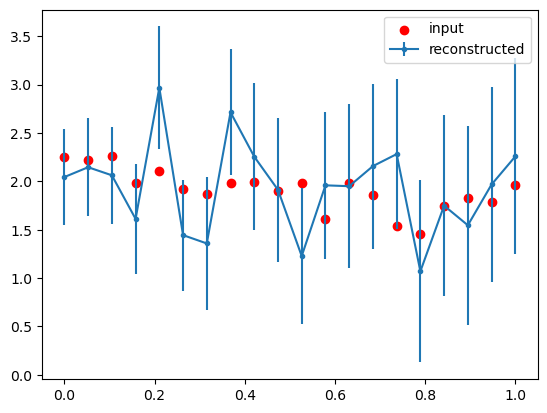

In [369]:
plt.scatter(np.linspace(0,1,n_pix), result_in['beta'], c='red', label='input')
plt.errorbar(np.linspace(0,1,n_pix), result['beta'], yerr=result['sigma_beta'], marker='.', label='reconstructed')
plt.legend()

## Scanning strategy with rotating HWP and rotating pitch

In [17]:
datafiles=["/media/mattia/Hard Disk/data/center/maps/01-02_pitch.pkl",
            "/media/mattia/Hard Disk/data/center/maps/03-04_pitch.pkl",
            "/media/mattia/Hard Disk/data/center/maps/05-06_pitch.pkl",
            "/media/mattia/Hard Disk/data/center/maps/07-08_pitch.pkl",
            "/media/mattia/Hard Disk/data/center/maps/09-10_pitch.pkl",
            "/media/mattia/Hard Disk/data/center/maps/11-12_pitch.pkl",
]

In [18]:
data = maps_stacking(datafiles)

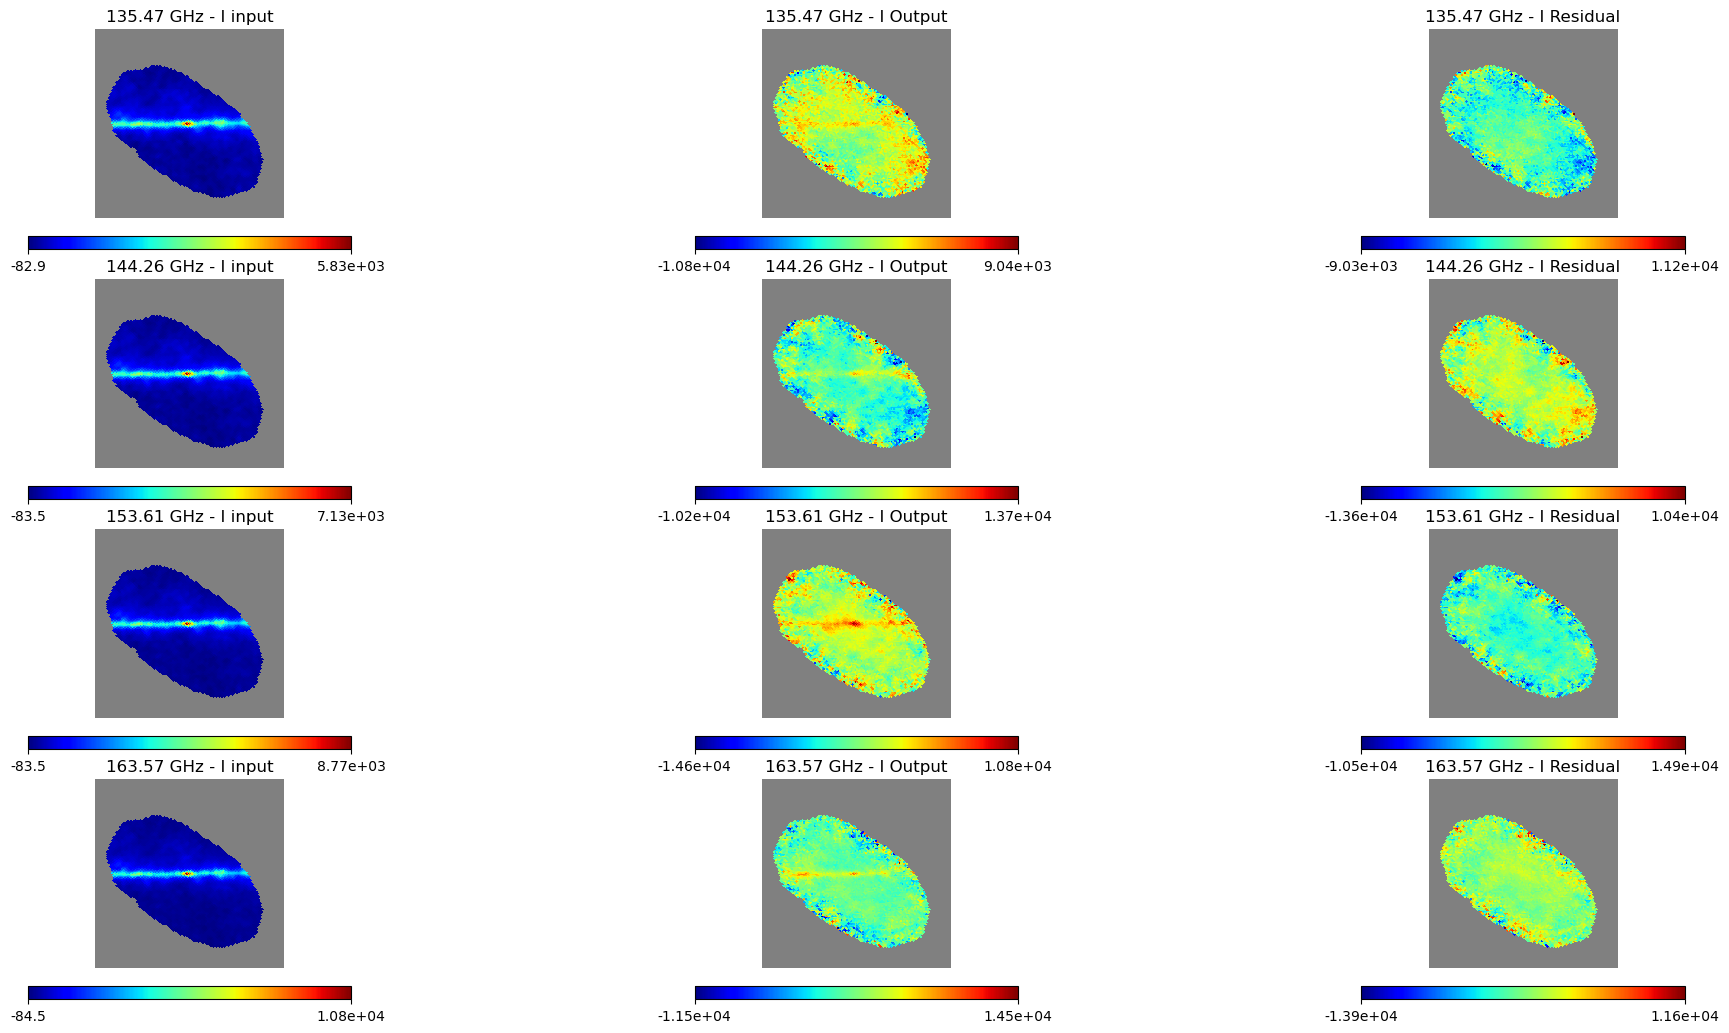

In [19]:
maps_input = data["maps_in"]
maps_rec = data["maps"]
maps_res = data["maps_res"]
seenpix = data["seenpix"]
maps_input[:,~seenpix] = hp.UNSEEN
maps_rec[:,~seenpix] = hp.UNSEEN
maps_res[:,~seenpix] = hp.UNSEEN
nus = data["nus"]
center = data["center"]
coverage = data["coverage"]

k=0 

plt.figure(figsize=(20, 10))
for inu in range(4):
    hp.gnomview((maps_input[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I input",  
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(4, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Output",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(4, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Residual",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(4, 3, k + 3))
    k += 3

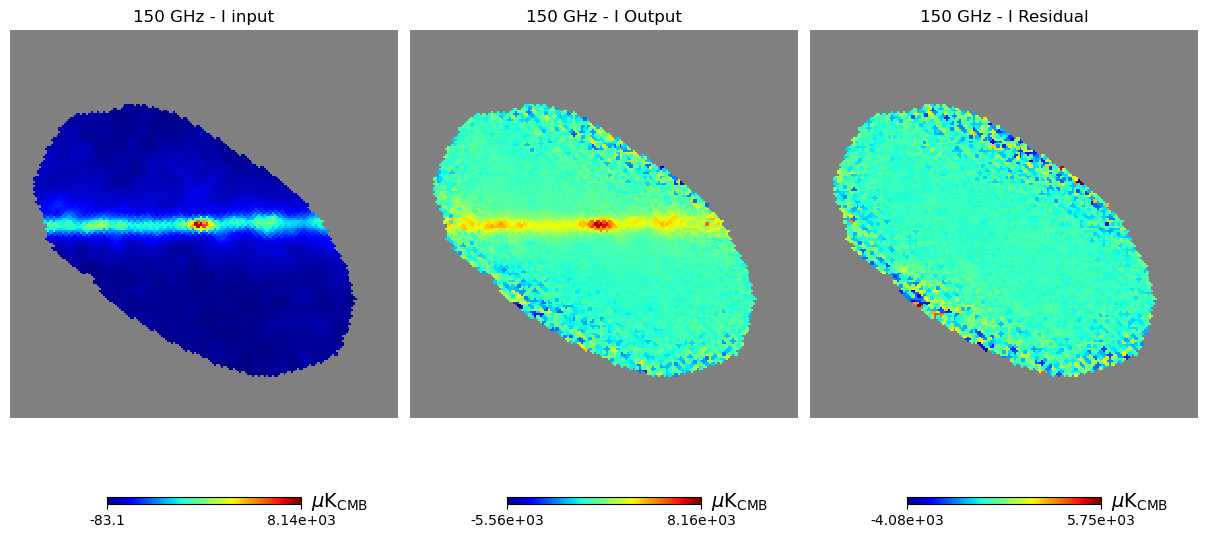

In [20]:
maps_input_mean = np.mean(maps_input[:,:], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:], axis=0)
maps_res_mean = np.mean(maps_res[:,:], axis=0)


plt.figure(figsize=(12, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,2))

hp.gnomview((maps_res_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,3))
    

In [21]:
brightest_pix_input = np.argmax(maps_input_mean)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean[brightest_pix_input]
brightest_val_true = maps_input_mean[brightest_pix_input]


print('coverage pixel centrale', coverage[brightest_pix_input])
print('Pixel centrale mappa input', brightest_val_true)
print('Pixel centrale mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel centrale 998414.495702972
Pixel centrale mappa input 8140.484210744878
Pixel centrale mappe ricostruita 8156.740018966915
SNR 500.7738833747463


### Noise estimation and SNR maps

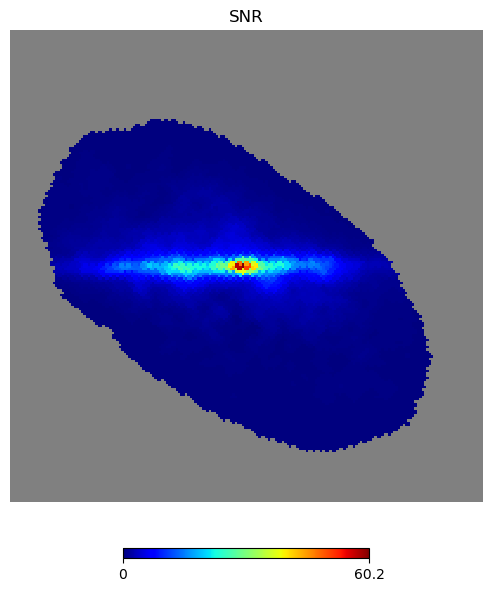

In [22]:
snr, sigma_noise = calculate_snr(maps_input_mean, maps_res_mean, coverage, seenpix, plot=True)

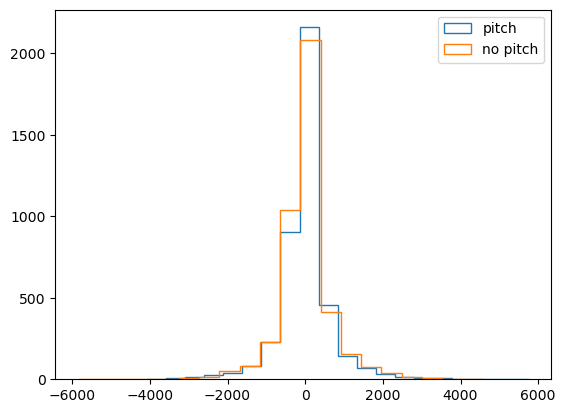

In [40]:
plt.hist(pitch[pitch>-1e5], bins=20, histtype='step', label='pitch')
plt.hist(no_pitch[no_pitch>-1e5], bins=20, histtype='step', label='no pitch')
plt.legend()